<a href="https://colab.research.google.com/github/Knerdy-got-moves/Many-body-dynamics-in-Floquet-driven-systems/blob/main/Entanglement_entropy/PBC_Optimised_entanglement_entropy_in_large_systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model: Kicked transverse field Ising model under periodic boundary conditions


Consider a transverse-field Ising chain of length $L$ with periodic boundary conditions (PBC), Pauli operators $\sigma_i^{x,y,z}$, and a weak transverse perturbation:
$$
H(t)=H_0(t)+H_1,
\qquad
H_0(t)=-J(t)\sum_{i=1}^{L}\sigma_i^z\sigma_{i+1}^z-h(t)\sum_{i=1}^{L}\sigma_i^z,
\qquad
H_1=-g\sum_{i=1}^{L}\sigma_i^x,\;\; |g|\ll \{|J_0|,|h_0|\},
$$
with periodic identification $\sigma_{L+1}^z\equiv\sigma_1^z$.
Both couplings follow the same symmetric square–wave of period $T$:
$$
J(t)=
\begin{cases}
+J_0,& 0\le t\le T/2,\\
-J_0,& T/2<t\le T,
\end{cases}
\qquad
h(t)=
\begin{cases}
+h_0,& 0\le t\le T/2,\\
-h_0,& T/2<t\le T.
\end{cases}
$$

For a Floquet period-$n$ state,
$$
|\psi(nT)\rangle = U_F^{\,n}\,|\psi(0)\rangle,
\qquad
U_F = e^{-i H_{+}\, T/2}\, e^{-i H_{-}\, T/2},
$$
where $H_{\pm}$ denote $H(t)$ with $(J,h)=(\pm J_0,\pm h_0)$ on the corresponding half-period.

Bipartition the ring into a contiguous block (A) of size $L_A$ and its complement (B) of size $L_B=L-L_A$.
The reduced density matrix of (A) at stroboscopic time $t=nT$ is
$$
\rho_A(nT)=\mathrm{Tr}_B\!\left[\,|\psi(nT)\rangle\langle\psi(nT)|\,\right],
$$
and the von Neumann entanglement entropy is
$$
S_A(nT)=-\mathrm{Tr}\!\big[\rho_A(nT)\,\ln\rho_A(nT)\big].
$$
With the Schmidt decomposition across the cut,
$$
|\psi(nT)\rangle=\sum_k s_k(nT)\,|k_A\rangle\otimes|k_B\rangle,
\qquad
p_k(nT)=\big(s_k(nT)\big)^2,
$$
the same entropy is
$$
S_A(nT)=-\sum_k p_k(nT)\,\ln p_k(nT).
$$

For the Page value at a half-chain cut, let
$$
L_A=\Big\lfloor \frac{L}{2}\Big\rfloor,\quad
L_B=L-L_A,\qquad
m=2^{L_A},\quad n=2^{L_B}.
$$
Then the average (Page) entanglement entropy is approximately
$$
S_{\text{Page}}\simeq \ln m-\frac{m}{2n}
= L_A\ln 2 - 2^{\,2L_A-L-1}.
$$
We plot the ratio
$$
\frac{S_A(nT)}{S_{\text{Page}}}\,.
$$



# Numerical Hamiltonian, Floquet unitary, Bipartite entanglement entropy

Here we define the couplings $J_0$, $h_0$ and the time period, $TP$. We compute the entanglement entropy for a random state and show that it saturates below the Eigenstate Thermalisation Hypothesis (ETH) value predicted vlaue, the Page value.

References for ETH:
1.   J. M. Deutsch, "Quantum statistical mechanics in a closed system," Phys. Rev. A 43, 2046-2049 (1991). doi: [10.1103/PhysRevA.43.2046](https://link.aps.org/doi/10.1103/PhysRevA.43.2046​).
2.   Mark Srednicki, "Chaos and quantum thermalization," Phys. Rev. E 50, 888-901 (1994). doi: [10.1103/PhysRevE.50.888](https://link.aps.org/doi/10.1103/PhysRevE.50.888​).
3.   Luca D'Alessio et al., "From quantum chaos and eigenstate thermalization to statistical mechanics and thermodynamics," Adv. Phys. 65, 239-362 (2016). doi: [10.1080/00018732.2016.1198134](https://doi.org/10.1080/00018732.2016.1198134).

References for Page value:


1.   Don N. Page, "Average entropy of a subsystem," Phys. Rev. Lett. 71, 1291-1294 (1993). doi: [10.1103/PhysRevLett.71.1291](https://doi.org/10.1103/PhysRevLett.71.1291).
2.   S. K. Foong and S. Kanno, "Proof of Page's conjecture on the average entropy of a subsystem," Phys. Rev. Lett. 72, 1148-1151 (1994). doi: [10.1103/PhysRevLett.72.1148](https://doi.org/10.1103/PhysRevLett.72.1148).
3.   L. Vidmar and M. Rigol, "Entanglement Entropy of Eigenstates of Quantum Chaotic Hamiltonians," Phys. Rev. Lett. 119, 220603 (2017). doi: [10.1103/PhysRevLett.119.220603](https://doi.org/10.1103/PhysRevLett.119.220603).











In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import LinearOperator


# ============================================================
# STANDALONE SPARSE HAMILTONIAN BUILDER — PERIODIC BC
# ============================================================

def build_H_floquet_pbc(L, J0, h0, g, which):
    """
    Construct a Floquet half-period Hamiltonian for the **periodic** Ising chain.

    H_+ = -J0 Σ_{i=0}^{L-1} σ^z_i σ^z_{(i+1)%L}  - h0 Σ σ^z_i  - g Σ σ^x_i
    H_- = +J0 Σ_{i=0}^{L-1} σ^z_i σ^z_{(i+1)%L}  + h0 Σ σ^z_i  - g Σ σ^x_i

    Parameters
    ----------
    L : int
        Chain length (number of sites).  Must be >= 2.
    J0 : float
        Ising nearest-neighbour coupling amplitude.
    h0 : float
        Longitudinal field amplitude.
    g : float
        Transverse field strength.
    which : {"plus", "minus"}
        Selects the half-period Hamiltonian.

    Returns
    -------
    H : scipy.sparse.csr_matrix, shape (N, N), dtype np.float64
        The Hamiltonian in CSR canonical form.
        Each row has exactly (L + 1) stored entries
        (1 diagonal + L off-diagonal sigma^x flips).
        Total nnz = N * (L + 1), where N = 2^L.

    Notes
    -----
    PBC adds the wrap-around bond (site L-1, site 0) compared to OBC.
    In bit arithmetic:
        site i   → bit position (L - 1 - i)
        site i+1 → bit position (L - 1 - ((i+1) % L))

    The wrap-around bond (i = L-1) gives:
        bit_pos(L-1) = 0,   bit_pos(0) = L-1
        σ^z_{L-1} σ^z_0 = 1 - 2 * (bit_0 XOR bit_{L-1})
    """
    if L < 2:
        raise ValueError(f"L must be >= 2, got {L}")
    if which not in ("plus", "minus"):
        raise ValueError(f"which must be 'plus' or 'minus', got '{which}'")

    N = 1 << L

    if which == "plus":
        signJ, signh = -1.0, -1.0
    else:
        signJ, signh = +1.0, +1.0

    states = np.arange(N, dtype=np.int64)

    # ---- Diagonal: ZZ (PBC: L bonds) + Z contributions ----
    diag = np.zeros(N, dtype=np.float64)

    # ZZ interaction: L bonds including wrap-around (i=L-1 → i+1=0)
    coeff_zz = signJ * J0
    for i in range(L):
        pi  = L - 1 - i                        # bit position of site i
        pi1 = L - 1 - ((i + 1) % L)            # bit position of site (i+1) mod L
        xor_bit = ((states >> pi) ^ (states >> pi1)) & 1
        diag += coeff_zz * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # Z field: L terms (unchanged from OBC)
    coeff_z = signh * h0
    for i in range(L):
        pi = L - 1 - i
        ci = (states >> pi) & 1
        diag += coeff_z * (1.0 - 2.0 * ci.astype(np.float64))

    # ---- Off-diagonal: σ^x flips (unchanged from OBC) ----
    # Build (column, value) arrays, shape (N, L+1)
    all_cols = np.empty((N, L + 1), dtype=np.int64)
    all_vals = np.empty((N, L + 1), dtype=np.float64)

    # Column 0 = diagonal
    all_cols[:, 0] = states
    all_vals[:, 0] = diag

    # Columns 1..L = σ^x bit-flips at each site
    for i in range(L):
        flip_mask = np.int64(1 << (L - 1 - i))
        all_cols[:, 1 + i] = states ^ flip_mask
        all_vals[:, 1 + i] = -g

    # ---- Sort columns within each row (CSR canonical form) ----
    sort_idx = np.argsort(all_cols, axis=1, kind='stable')
    all_cols = np.take_along_axis(all_cols, sort_idx, axis=1)
    all_vals = np.take_along_axis(all_vals, sort_idx, axis=1)

    # ---- Assemble CSR matrix ----
    indptr  = np.arange(N + 1, dtype=np.int64) * (L + 1)
    indices = all_cols.ravel()
    data    = all_vals.ravel()

    H = csr_matrix((data, indices, indptr), shape=(N, N))
    H.has_sorted_indices = True

    return H


# ============================================================
# LIGHTWEIGHT BASIS DESCRIPTOR
# ============================================================

class _BasisInfo:
    """
    Drop-in for QuSpin's spin_basis_1d, exposing .Ns and .states.
    """
    __slots__ = ('L', 'Ns', 'states')

    def __init__(self, L):
        self.L = L
        self.Ns = 1 << L
        self.states = np.arange(1 << L, dtype=np.int64)

    def __repr__(self):
        return f"_BasisInfo(L={self.L}, Ns={self.Ns})"


# ============================================================
# OOP INTERFACE — PERIODIC BC
# ============================================================

class FloquetIsingChain:
    """
    Floquet-driven Ising chain with **periodic** boundary conditions.

    After calling build_hamiltonians(), the following are available:
        .H_plus_sparse   : csr_matrix  — H_+ (first half-period)
        .H_minus_sparse  : csr_matrix  — H_- (second half-period)
        .A_plus          : csr_matrix  — -i * H_+ * T/(2*hbar), complex128
        .A_minus         : csr_matrix  — -i * H_- * T/(2*hbar), complex128

    The cached A_plus / A_minus are the generators for expm_multiply:
        exp(A_plus) |ψ⟩ = exp(-i H_+ T/(2ℏ)) |ψ⟩
    """

    def __init__(self, L=8, J_0=4.0, h_0=8.0, g=1.0, TP=np.pi/4.0, hbar=1.0):
        self.L = L
        self.J_0 = J_0
        self.h_0 = h_0
        self.g = g
        self.hbar = hbar
        self.T = TP

        self.Ns = 1 << L
        self.basis = _BasisInfo(L)

        # Built on demand
        self._H_plus_sparse = None
        self._H_minus_sparse = None
        self._A_plus = None
        self._A_minus = None

        # Adaptive subdivision for Krylov (set in build_hamiltonians)
        self._A_plus_norm1 = None
        self._A_minus_norm1 = None
        self._K_plus = 1        # number of sub-steps for A_plus
        self._K_minus = 1       # number of sub-steps for A_minus
        self._A_plus_sub = None   # A_plus / K_plus (pre-scaled)
        self._A_minus_sub = None  # A_minus / K_minus (pre-scaled)

        print(f"System Parameters (PERIODIC BC):")
        print(f"  Chain length L = {self.L}")
        print(f"  J_0 = {self.J_0}")
        print(f"  h_0 = {self.h_0}")
        print(f"  g = {self.g}")
        print(f"  Period T = {self.T:.6f}")
        print(f"  Hilbert space dimension = {self.Ns}")

    # --------------------------------------------------------
    # Hamiltonian construction
    # --------------------------------------------------------

    def build_hamiltonians(self):
        """
        Build H_+ and H_- (PBC) and cache Krylov generators A_±.

        Returns
        -------
        H_plus_sparse  : csr_matrix, shape (Ns, Ns), float64
        H_minus_sparse : csr_matrix, shape (Ns, Ns), float64
        """
        self._H_plus_sparse = build_H_floquet_pbc(
            self.L, self.J_0, self.h_0, self.g, "plus"
        )
        self._H_minus_sparse = build_H_floquet_pbc(
            self.L, self.J_0, self.h_0, self.g, "minus"
        )

        # --- Cache Krylov generators: A = -i * H * T/(2*hbar) ---
        scale = -1j * self.T / (2.0 * self.hbar)
        self._A_plus  = (scale * self._H_plus_sparse).tocsr()
        self._A_minus = (scale * self._H_minus_sparse).tocsr()

        # --- Adaptive subdivision for large spectral norms ---
        # When ||A||_1 is large, expm_multiply does many internal
        # Lanczos restarts (cost ~ ||A||_1 / 5 restarts).
        # We subdivide manually: exp(A) = (exp(A/K))^K where
        # K = ceil(||A||_1 / NORM_THRESHOLD).  Pre-scale once here.
        from scipy.sparse.linalg import norm as sp_norm
        NORM_THRESHOLD = 5.0

        self._A_plus_norm1  = sp_norm(self._A_plus, ord=1)
        self._A_minus_norm1 = sp_norm(self._A_minus, ord=1)

        self._K_plus  = max(1, int(np.ceil(self._A_plus_norm1 / NORM_THRESHOLD)))
        self._K_minus = max(1, int(np.ceil(self._A_minus_norm1 / NORM_THRESHOLD)))

        if self._K_plus == 1:
            self._A_plus_sub = self._A_plus
        else:
            self._A_plus_sub = (self._A_plus / self._K_plus).tocsr()

        if self._K_minus == 1:
            self._A_minus_sub = self._A_minus
        else:
            self._A_minus_sub = (self._A_minus / self._K_minus).tocsr()

        # --- Validation ---
        assert self._H_plus_sparse.shape == (self.Ns, self.Ns)
        assert self._H_minus_sparse.shape == (self.Ns, self.Ns)

        nnz_expected = self.Ns * (self.L + 1)
        nnz_actual = self._H_plus_sparse.nnz
        assert nnz_actual == nnz_expected, \
            f"nnz mismatch: got {nnz_actual}, expected {nnz_expected}"

        density = nnz_actual / (self.Ns ** 2)

        print(f"\nHamiltonians constructed successfully (PERIODIC BC)!")
        print(f"  H+ shape: {self._H_plus_sparse.shape}, nnz = {nnz_actual}")
        print(f"  Number of ZZ bonds: {self.L} (including wrap-around)")
        print(f"  Density: {density:.2e}")
        print(f"  Memory per H matrix: ~{self._estimate_sparse_memory():.2f} MB")
        print(f"  A_plus dtype: {self._A_plus.dtype}  (Krylov generator cached)")
        print(f"  ||A+||_1 = {self._A_plus_norm1:.2f}, "
              f"||A-||_1 = {self._A_minus_norm1:.2f}")
        print(f"  Krylov sub-steps: K+ = {self._K_plus}, K- = {self._K_minus}"
              f"{'  (no subdivision needed)' if self._K_plus == 1 and self._K_minus == 1 else ''}")

        self._verify_hermiticity()

        return self._H_plus_sparse, self._H_minus_sparse

    # --------------------------------------------------------
    # Hermiticity verification
    # --------------------------------------------------------

    def _verify_hermiticity(self, n_samples=5):
        """Verify ⟨v|H|w⟩ = ⟨w|H|v⟩* via random complex vectors."""
        if self._H_plus_sparse is None:
            return

        rng = np.random.RandomState(42)
        max_diff_p = 0.0
        max_diff_m = 0.0

        for _ in range(n_samples):
            v = rng.randn(self.Ns) + 1j * rng.randn(self.Ns)
            w = rng.randn(self.Ns) + 1j * rng.randn(self.Ns)

            # Check H_plus
            vHw = np.vdot(v, self._H_plus_sparse @ w)
            wHv = np.vdot(w, self._H_plus_sparse @ v)
            max_diff_p = max(max_diff_p, abs(vHw - np.conj(wHv)))

            # Check H_minus
            vHw = np.vdot(v, self._H_minus_sparse @ w)
            wHv = np.vdot(w, self._H_minus_sparse @ v)
            max_diff_m = max(max_diff_m, abs(vHw - np.conj(wHv)))

        print(f"  Hermiticity check (H+): max err = {max_diff_p:.2e}")
        print(f"  Hermiticity check (H-): max err = {max_diff_m:.2e}")
        assert max_diff_p < 1e-9, f"H+ hermiticity violated: {max_diff_p}"
        assert max_diff_m < 1e-9, f"H- hermiticity violated: {max_diff_m}"

    # --------------------------------------------------------
    # Memory estimation
    # --------------------------------------------------------

    def _estimate_sparse_memory(self):
        """Estimate CSR memory for one Hamiltonian in MB."""
        nnz = self.Ns * (self.L + 1)
        bytes_data    = nnz * 8              # float64 data
        bytes_indices = nnz * 8              # int64 column indices
        bytes_indptr  = (self.Ns + 1) * 8    # int64 row pointers
        return (bytes_data + bytes_indices + bytes_indptr) / (1024 ** 2)

    # --------------------------------------------------------
    # Properties
    # --------------------------------------------------------

    @property
    def H_plus_sparse(self):
        if self._H_plus_sparse is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._H_plus_sparse

    @property
    def H_minus_sparse(self):
        if self._H_minus_sparse is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._H_minus_sparse

    @property
    def A_plus(self):
        """Krylov generator: -i * H_+ * T/(2*hbar), complex128 CSR."""
        if self._A_plus is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._A_plus

    @property
    def A_minus(self):
        """Krylov generator: -i * H_- * T/(2*hbar), complex128 CSR."""
        if self._A_minus is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._A_minus

    @property
    def A_plus_sub(self):
        """Pre-scaled A_plus / K_plus for adaptive Krylov subdivision."""
        if self._A_plus_sub is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._A_plus_sub

    @property
    def A_minus_sub(self):
        """Pre-scaled A_minus / K_minus for adaptive Krylov subdivision."""
        if self._A_minus_sub is None:
            raise RuntimeError("Call build_hamiltonians() first")
        return self._A_minus_sub

    @property
    def K_plus(self):
        """Number of sub-steps for A_plus Krylov evolution."""
        return self._K_plus

    @property
    def K_minus(self):
        """Number of sub-steps for A_minus Krylov evolution."""
        return self._K_minus

    # --------------------------------------------------------
    # LinearOperator fallbacks
    # --------------------------------------------------------

    def get_H_plus_linop(self):
        H = self.H_plus_sparse
        return LinearOperator(
            shape=(self.Ns, self.Ns),
            matvec=lambda v: H @ v,
            rmatvec=lambda v: H @ v,   # real symmetric
            dtype=np.complex128
        )

    def get_H_minus_linop(self):
        H = self.H_minus_sparse
        return LinearOperator(
            shape=(self.Ns, self.Ns),
            matvec=lambda v: H @ v,
            rmatvec=lambda v: H @ v,
            dtype=np.complex128
        )


# ============================================================
# SELF-TESTS (run when this cell is executed)
# ============================================================

if __name__ == "__main__" or True:   # always run in notebook

    print("=" * 72)
    print("PROMPT 1: Sparse PBC Hamiltonian Builder — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: Basic construction and shape
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: Basic construction at L=8")
    print("-" * 72)

    L = 8
    ising = FloquetIsingChain(L=L, J_0=4.0, h_0=8.0, g=1.0,
                              TP=np.pi/4.0, hbar=1.0)
    H_plus, H_minus = ising.build_hamiltonians()

    Ns = 2**L
    assert H_plus.shape == (Ns, Ns), f"Shape mismatch: {H_plus.shape}"
    assert H_minus.shape == (Ns, Ns), f"Shape mismatch: {H_minus.shape}"
    assert H_plus.nnz == Ns * (L + 1), f"nnz mismatch: {H_plus.nnz}"
    print("  PASS: shapes and nnz correct")

    # ----------------------------------------------------------
    # TEST 2: Real symmetry (H = H^T since H is real)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: Real symmetry H = H^T")
    print("-" * 72)

    for label, H in [("H+", H_plus), ("H-", H_minus)]:
        diff = (H - H.T).data
        max_asym = np.max(np.abs(diff)) if len(diff) > 0 else 0.0
        print(f"  {label}: max|H - H^T| = {max_asym:.2e}")
        assert max_asym < 1e-12, f"{label} not symmetric!"
    print("  PASS: both Hamiltonians are exactly symmetric")

    # ----------------------------------------------------------
    # TEST 3: H_+ and H_- relationship
    #   H_- should equal -H_+ + (common transverse part)
    #   Specifically: H_+ + H_- = -2g Σ σ^x_i
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: H_+ + H_- = -2g Σ σ^x_i")
    print("-" * 72)

    H_sum = H_plus + H_minus
    H_sum_dense = H_sum.toarray()

    # Build expected: -2g Σ σ^x_i
    g_val = 1.0
    expected = np.zeros((Ns, Ns), dtype=np.float64)
    states = np.arange(Ns, dtype=np.int64)
    for i in range(L):
        flip_mask = np.int64(1 << (L - 1 - i))
        for s in range(Ns):
            s_flip = int(s ^ flip_mask)
            expected[s, s_flip] += -2.0 * g_val

    max_diff = np.max(np.abs(H_sum_dense - expected))
    print(f"  max|H_+ + H_- - (-2g Σσ^x)| = {max_diff:.2e}")
    assert max_diff < 1e-12, f"H_+/H_- relationship broken: {max_diff}"
    print("  PASS: H_+ + H_- identity verified")

    # ----------------------------------------------------------
    # TEST 4: PBC wrap-around bond check
    #   Compare L=4 PBC vs OBC diagonal to verify the extra bond
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: PBC wrap-around bond presence (L=4)")
    print("-" * 72)

    L_test = 4
    J0_test, h0_test, g_test = 4.0, 8.0, 1.0
    N_test = 2**L_test

    H_pbc = build_H_floquet_pbc(L_test, J0_test, h0_test, g_test, "plus")
    H_pbc_dense = H_pbc.toarray()

    # Build OBC version manually for comparison
    # (import the OBC builder logic inline)
    states_test = np.arange(N_test, dtype=np.int64)
    diag_obc = np.zeros(N_test, dtype=np.float64)
    diag_pbc_manual = np.zeros(N_test, dtype=np.float64)

    # OBC: L-1 = 3 bonds
    for i in range(L_test - 1):
        pi  = L_test - 1 - i
        pi1 = L_test - 2 - i
        xor_bit = ((states_test >> pi) ^ (states_test >> pi1)) & 1
        diag_obc += (-J0_test) * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # PBC: L = 4 bonds (same 3 + wrap-around)
    for i in range(L_test):
        pi  = L_test - 1 - i
        pi1 = L_test - 1 - ((i + 1) % L_test)
        xor_bit = ((states_test >> pi) ^ (states_test >> pi1)) & 1
        diag_pbc_manual += (-J0_test) * (1.0 - 2.0 * xor_bit.astype(np.float64))

    # The difference should be exactly one ZZ bond: site 3 ↔ site 0
    diff_diag = diag_pbc_manual - diag_obc
    n_nonzero = np.count_nonzero(np.abs(diff_diag) > 1e-12)
    print(f"  PBC - OBC diagonal: {n_nonzero}/{N_test} entries differ")
    print(f"  Wrap-around bond values: {np.unique(diff_diag)}")

    # Verify the wrap-around values are ±J0
    # Each ZZ bond contributes signJ * J0 * (1 - 2*xor) = ±J0 per state
    assert n_nonzero > 0, "No diagonal difference — wrap-around bond missing!"
    unique_diffs = np.unique(np.abs(diff_diag[np.abs(diff_diag) > 1e-12]))
    assert np.allclose(unique_diffs, [J0_test]), \
        f"Unexpected wrap-around magnitudes: {unique_diffs}, expected [{J0_test}]"
    print("  PASS: wrap-around bond (site L-1 ↔ site 0) correctly added")

    # ----------------------------------------------------------
    # TEST 5: A_plus / A_minus Krylov generators
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: Krylov generator A = -i·H·T/(2ℏ) caching")
    print("-" * 72)

    L_test = 6
    T_test = np.pi / 10.0
    hbar_test = 1.0
    ising_test = FloquetIsingChain(L=L_test, J_0=10.0, h_0=20.0, g=1.0,
                                    TP=T_test, hbar=hbar_test)
    ising_test.build_hamiltonians()

    scale = -1j * T_test / (2.0 * hbar_test)
    A_expected = (scale * ising_test.H_plus_sparse).toarray()
    A_actual = ising_test.A_plus.toarray()
    max_err = np.max(np.abs(A_actual - A_expected))
    print(f"  max|A_plus - (-i·H+·T/2)| = {max_err:.2e}")
    assert max_err < 1e-14, f"Generator caching error: {max_err}"
    assert ising_test.A_plus.dtype == np.complex128, \
        f"A_plus dtype should be complex128, got {ising_test.A_plus.dtype}"
    print(f"  A_plus dtype: {ising_test.A_plus.dtype}")
    print("  PASS: Krylov generators correctly cached")

    # ----------------------------------------------------------
    # TEST 6: Analytical check — L=2 PBC
    #   For L=2, PBC gives σ^z_0 σ^z_1 + σ^z_1 σ^z_0 = 2·σ^z_0 σ^z_1
    #   (two identical bonds from the ring wrapping)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 6: Analytical L=2 PBC (double-counted ZZ bond)")
    print("-" * 72)

    L2 = 2
    J0_2, h0_2, g_2 = 1.0, 0.5, 0.3
    H2 = build_H_floquet_pbc(L2, J0_2, h0_2, g_2, "plus")
    H2_dense = H2.toarray()

    # Analytical H_+ for L=2, PBC:
    # H_+ = -J0 (σ^z_0 σ^z_1 + σ^z_1 σ^z_0) - h0 (σ^z_0 + σ^z_1) - g (σ^x_0 + σ^x_1)
    #      = -2 J0 σ^z_0 σ^z_1 - h0 (σ^z_0 + σ^z_1) - g (σ^x_0 + σ^x_1)
    #
    # Basis: |00⟩=0, |01⟩=1, |10⟩=2, |11⟩=3
    # σ^z values: site 0 → bit 1, site 1 → bit 0
    #   |00⟩: σz0=+1, σz1=+1  →  ZZ=+1, Z_sum=+2
    #   |01⟩: σz0=+1, σz1=-1  →  ZZ=-1, Z_sum= 0
    #   |10⟩: σz0=-1, σz1=+1  →  ZZ=-1, Z_sum= 0
    #   |11⟩: σz0=-1, σz1=-1  →  ZZ=+1, Z_sum=-2

    H2_expected = np.array([
        [-2*J0_2 - h0_2*2, -g_2,             -g_2,              0          ],
        [-g_2,              +2*J0_2,          0,                -g_2        ],
        [-g_2,              0,                +2*J0_2,          -g_2        ],
        [0,                -g_2,             -g_2,              -2*J0_2 + h0_2*2]
    ], dtype=np.float64)

    max_err = np.max(np.abs(H2_dense - H2_expected))
    print(f"  max|H_sparse - H_analytical| = {max_err:.2e}")
    if max_err > 1e-12:
        print(f"\n  H_sparse:\n{H2_dense}")
        print(f"\n  H_expected:\n{H2_expected}")
    assert max_err < 1e-12, f"L=2 analytical check failed: {max_err}"
    print("  PASS: L=2 PBC analytical result matches exactly")

    # ----------------------------------------------------------
    # Summary
    # ----------------------------------------------------------
    print("\n" + "=" * 72)
    print("ALL PROMPT 1 SELF-TESTS PASSED")
    print("=" * 72)
    print("\nRun the QuSpin regression test (separate cell) to validate")
    print("against the old PBC Hamiltonian at L = 4, 6, 8.")

PROMPT 1: Sparse PBC Hamiltonian Builder — Self-Tests

------------------------------------------------------------------------
TEST 1: Basic construction at L=8
------------------------------------------------------------------------
System Parameters (PERIODIC BC):
  Chain length L = 8
  J_0 = 4.0
  h_0 = 8.0
  g = 1.0
  Period T = 0.785398
  Hilbert space dimension = 256

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 8 (including wrap-around)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 40.84, ||A-||_1 = 40.84
  Krylov sub-steps: K+ = 9, K- = 9
  Hermiticity check (H+): max err = 4.69e-13
  Hermiticity check (H-): max err = 4.23e-13
  PASS: shapes and nnz correct

------------------------------------------------------------------------
TEST 2: Real symmetry H = H^T
------------------------------------------------------------------------
  H+: max|

## Time evolution operators over a period, T
The exact time evolution  operator can be written as $U^{s}(T, 0) = e^{-iH_{-}T/2\hbar}e^{-iH_{+}T/2\hbar}$ where $H_{+}$ is the hamiltonian for the first half of the cycle and $H_{-}$ is the Hamiltonian for the $T/2<t\le T$.

The time period at which we see a violation of ETH is given by:
$$T=\frac{n\pi}{J_0},$$
where $n\in \mathrm{Z}$.

In [ ]:
import numpy as np
from scipy.sparse.linalg import expm_multiply
from scipy.linalg import expm  # ONLY for build_floquet_operator (dense validation)


# ============================================================
# CORE KRYLOV EVOLUTION
# ============================================================

def apply_floquet_step(ising_chain, Psi):
    """
    Apply one Floquet period to state(s) via sparse Krylov evolution
    with adaptive subdivision.

    Computes:
        Ψ' = exp(-i H_- T/(2ℏ)) · exp(-i H_+ T/(2ℏ)) · Ψ

    When ||A_±||_1 > 5, expm_multiply does many internal Lanczos
    restarts (~||A||_1 / 5 each).  We pre-subdivide:
        exp(A) = (exp(A/K))^K,  K = ceil(||A||_1 / 5)
    so each call sees ||A/K||_1 ≤ 5 → single-pass Krylov.
    The pre-scaled matrices A_±/K and the counts K_± are cached
    in ising_chain by build_hamiltonians().

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Must have build_hamiltonians() already called.
        Accesses: .A_plus_sub, .A_minus_sub, .K_plus, .K_minus.
    Psi : ndarray, shape (Ns,) or (Ns, B)
        Single state vector or batch of B states as columns.

    Returns
    -------
    Psi_out : ndarray, same shape as Psi
        State(s) after one Floquet period.

    Notes
    -----
    - No dense U_F matrix is ever formed.
    - Memory: O(k · Ns) workspace per expm_multiply call, k ~ 20-30.
    - For batch (Ns, B): Krylov basis is reused across columns.
    - Total expm_multiply calls per Floquet step = K_+ + K_-.
      When ||A||_1 ≤ 5 (typical for J₀ ≥ 5), K = 1 and there
      is zero overhead vs the unsplit version.
    """
    Ns = ising_chain.Ns

    # Input validation
    assert Psi.ndim in (1, 2), f"Psi must be 1D or 2D, got ndim={Psi.ndim}"
    assert Psi.shape[0] == Ns, \
        f"Psi leading dim {Psi.shape[0]} != Ns={Ns}"

    # Ensure complex128 for Krylov
    if not np.iscomplexobj(Psi):
        Psi = Psi.astype(np.complex128)
    elif Psi.dtype != np.complex128:
        Psi = Psi.astype(np.complex128)

    # First half-period:  exp(A_+) · Ψ  via K_+ sub-steps
    A_sub = ising_chain.A_plus_sub
    for _ in range(ising_chain.K_plus):
        Psi = expm_multiply(A_sub, Psi)

    # Second half-period: exp(A_-) · result via K_- sub-steps
    A_sub = ising_chain.A_minus_sub
    for _ in range(ising_chain.K_minus):
        Psi = expm_multiply(A_sub, Psi)

    # Ensure output dtype
    if Psi.dtype != np.complex128:
        Psi = Psi.astype(np.complex128)

    return Psi


# ============================================================
# DENSE FLOQUET OPERATOR (small-L validation ONLY)
# ============================================================

def build_floquet_operator(ising_chain):
    """
    Build the DENSE Floquet unitary U_F = exp(-i H_- T/(2ℏ)) exp(-i H_+ T/(2ℏ)).

    WARNING: This forms the full Ns × Ns unitary matrix via scipy.linalg.expm.
    Memory cost: O(Ns^2) = O(4^L). Only use for L ≤ 12 (validation/regression).

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Must have build_hamiltonians() already called.

    Returns
    -------
    U_floquet : ndarray, shape (Ns, Ns), complex128
        Dense Floquet unitary operator.
    """
    T = ising_chain.T
    hbar = ising_chain.hbar
    Ns = ising_chain.Ns

    if ising_chain.L > 12:
        import warnings
        warnings.warn(
            f"build_floquet_operator called at L={ising_chain.L}: "
            f"dense U_F requires {Ns**2 * 16 / 1e9:.1f} GB. "
            f"Use apply_floquet_step() instead.",
            RuntimeWarning, stacklevel=2
        )

    # Get dense Hamiltonian matrices from sparse
    H_plus_dense  = ising_chain.H_plus_sparse.toarray()
    H_minus_dense = ising_chain.H_minus_sparse.toarray()

    # Build evolution operators for each half-period
    U_plus  = expm(-1j * H_plus_dense  * T / (2.0 * hbar))
    U_minus = expm(-1j * H_minus_dense * T / (2.0 * hbar))

    # Full period: U_F = U_minus · U_plus (right-to-left ordering)
    U_floquet = U_minus @ U_plus

    # Unitarity check
    unitarity_err = np.linalg.norm(
        U_floquet.conj().T @ U_floquet - np.eye(Ns)
    )

    print("Floquet operator constructed (DENSE):")
    print(f"  Shape: {U_floquet.shape}")
    print(f"  Unitarity check: ||U†U - I|| = {unitarity_err:.2e}")
    print(f"  Memory: {U_floquet.nbytes / 1e6:.1f} MB")

    return U_floquet


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("PROMPT 2: Krylov Evolution — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: Single-vector norm conservation
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: Single-vector norm conservation (L=8)")
    print("-" * 72)

    L = 8
    Ns = 2**L
    ising = FloquetIsingChain(L=L, J_0=10.0, h_0=20.0, g=1.0,
                              TP=np.pi/10.0, hbar=1.0)
    ising.build_hamiltonians()

    # Random initial state
    rng = np.random.default_rng(42)
    psi = rng.standard_normal(Ns) + 1j * rng.standard_normal(Ns)
    psi /= np.linalg.norm(psi)

    norm_before = np.linalg.norm(psi)
    psi_out = apply_floquet_step(ising, psi)
    norm_after = np.linalg.norm(psi_out)
    norm_err = abs(norm_after - 1.0)

    print(f"  ||ψ|| before: {norm_before:.15f}")
    print(f"  ||ψ|| after:  {norm_after:.15f}")
    print(f"  |norm - 1|:   {norm_err:.2e}")
    assert norm_err < 1e-10, f"Norm not conserved: {norm_err}"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 2: Batch norm conservation
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: Batch norm conservation (L=8, B=10)")
    print("-" * 72)

    B = 10
    Psi = rng.standard_normal((Ns, B)) + 1j * rng.standard_normal((Ns, B))
    norms_before = np.linalg.norm(Psi, axis=0)
    Psi /= norms_before[np.newaxis, :]  # normalise each column

    Psi_out = apply_floquet_step(ising, Psi)
    norms_after = np.linalg.norm(Psi_out, axis=0)
    max_norm_err = np.max(np.abs(norms_after - 1.0))

    print(f"  Max |norm - 1| across {B} states: {max_norm_err:.2e}")
    assert max_norm_err < 1e-10, f"Batch norm error: {max_norm_err}"
    print(f"  Output shape: {Psi_out.shape} (expected ({Ns}, {B}))")
    assert Psi_out.shape == (Ns, B)
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 3: Batch consistency
    #   apply_floquet_step on full batch column k must equal
    #   apply_floquet_step on that column alone
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: Batch consistency — column k matches single-vector")
    print("-" * 72)

    # Use Psi and Psi_out from TEST 2
    max_col_err = 0.0
    for k in range(B):
        psi_k_single = apply_floquet_step(ising, Psi[:, k].copy())
        col_err = np.max(np.abs(psi_k_single - Psi_out[:, k]))
        max_col_err = max(max_col_err, col_err)

    print(f"  Max column error over {B} columns: {max_col_err:.2e}")
    assert max_col_err < 1e-12, f"Batch inconsistency: {max_col_err}"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 4: Krylov vs Dense regression at L=6
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: Krylov vs Dense regression (L=6, 20 random states)")
    print("-" * 72)

    L_test = 6
    Ns_test = 2**L_test
    ising_test = FloquetIsingChain(L=L_test, J_0=10.0, h_0=20.0, g=1.0,
                                    TP=np.pi/10.0, hbar=1.0)
    ising_test.build_hamiltonians()

    # Build dense U_F for reference
    U_F = build_floquet_operator(ising_test)

    # Test on 20 random vectors
    n_test_vecs = 20
    max_err = 0.0
    for _ in range(n_test_vecs):
        psi_test = rng.standard_normal(Ns_test) + 1j * rng.standard_normal(Ns_test)
        psi_test /= np.linalg.norm(psi_test)

        psi_dense  = U_F @ psi_test
        psi_krylov = apply_floquet_step(ising_test, psi_test)

        err = np.max(np.abs(psi_dense - psi_krylov))
        max_err = max(max_err, err)

    print(f"  Max |dense - krylov| over {n_test_vecs} vectors: {max_err:.2e}")
    assert max_err < 1e-8, f"Krylov-dense mismatch: {max_err}"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 5: Batched Krylov vs Dense regression at L=6
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: Batched Krylov vs Dense GEMM (L=6, B=15)")
    print("-" * 72)

    B_test = 15
    Psi_test = rng.standard_normal((Ns_test, B_test)) + \
               1j * rng.standard_normal((Ns_test, B_test))
    norms_test = np.linalg.norm(Psi_test, axis=0)
    Psi_test /= norms_test[np.newaxis, :]

    Psi_dense  = U_F @ Psi_test                          # dense GEMM
    Psi_krylov = apply_floquet_step(ising_test, Psi_test) # batched Krylov

    max_err_batch = np.max(np.abs(Psi_dense - Psi_krylov))
    print(f"  Max |dense_GEMM - krylov_batch| = {max_err_batch:.2e}")
    assert max_err_batch < 1e-8, f"Batched Krylov-dense mismatch: {max_err_batch}"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 6: Multi-period evolution norm drift
    #   Evolve 100 periods, check norm stays close to 1
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 6: Multi-period norm drift (L=6, 100 periods)")
    print("-" * 72)

    psi_drift = rng.standard_normal(Ns_test) + 1j * rng.standard_normal(Ns_test)
    psi_drift /= np.linalg.norm(psi_drift)

    n_periods_drift = 100
    max_drift = 0.0
    for n in range(n_periods_drift):
        psi_drift = apply_floquet_step(ising_test, psi_drift)
        drift = abs(np.linalg.norm(psi_drift) - 1.0)
        max_drift = max(max_drift, drift)

    print(f"  Max |norm - 1| over {n_periods_drift} periods: {max_drift:.2e}")
    assert max_drift < 1e-8, f"Norm drift too large: {max_drift}"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 7: Multi-period Krylov vs Dense trajectory (L=6)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 7: Multi-period trajectory match (L=6, 50 periods)")
    print("-" * 72)

    psi_k = rng.standard_normal(Ns_test) + 1j * rng.standard_normal(Ns_test)
    psi_k /= np.linalg.norm(psi_k)
    psi_d = psi_k.copy()

    n_traj = 50
    max_traj_err = 0.0
    for n in range(n_traj):
        psi_k = apply_floquet_step(ising_test, psi_k)
        psi_d = U_F @ psi_d
        traj_err = np.max(np.abs(psi_k - psi_d))
        max_traj_err = max(max_traj_err, traj_err)

    print(f"  Max |krylov - dense| over {n_traj} periods: {max_traj_err:.2e}")
    assert max_traj_err < 1e-6, f"Trajectory diverged: {max_traj_err}"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 8: Shape preservation — 1D in, 1D out
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 8: Shape preservation")
    print("-" * 72)

    psi_1d = rng.standard_normal(Ns_test) + 1j * rng.standard_normal(Ns_test)
    psi_1d /= np.linalg.norm(psi_1d)
    out_1d = apply_floquet_step(ising_test, psi_1d)
    print(f"  1D input shape:  {psi_1d.shape} → output: {out_1d.shape}")
    assert out_1d.shape == (Ns_test,), f"1D shape broken: {out_1d.shape}"

    psi_2d = psi_1d[:, np.newaxis]   # (Ns, 1)
    out_2d = apply_floquet_step(ising_test, psi_2d)
    print(f"  2D input shape:  {psi_2d.shape} → output: {out_2d.shape}")
    assert out_2d.shape == (Ns_test, 1), f"2D shape broken: {out_2d.shape}"
    print("  PASS")

    # ----------------------------------------------------------
    # Summary
    # ----------------------------------------------------------
    print("\n" + "=" * 72)
    print("ALL PROMPT 2 SELF-TESTS PASSED")
    print("=" * 72)

PROMPT 2: Krylov Evolution — Self-Tests

------------------------------------------------------------------------
TEST 1: Single-vector norm conservation (L=8)
------------------------------------------------------------------------
System Parameters (PERIODIC BC):
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 8 (including wrap-around)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 38.96, ||A-||_1 = 38.96
  Krylov sub-steps: K+ = 8, K- = 8
  Hermiticity check (H+): max err = 9.37e-13
  Hermiticity check (H-): max err = 1.22e-12
  ||ψ|| before: 1.000000000000000
  ||ψ|| after:  1.000000000000000
  |norm - 1|:   2.22e-16
  PASS

------------------------------------------------------------------------
TEST 2: Batch norm conservation (L=8, B=10)


## Random pure state generation from the entire Hilbert space

Here we generate a random tensor product state (pure state) by taking a tensor product over random Haar generated single qubit states.

In [ ]:
import numpy as np


# ============================================================
# RANDOM PRODUCT STATE GENERATION — SINGLE + BATCHED
# ============================================================
#
# CRITICAL DISTINCTION:
#   Product states: |ψ⟩ = ⊗_{j=0}^{L-1} |ϕ_j⟩,  S_A(0) = 0
#   Haar states:    |ψ⟩ = z/||z||, z ∈ C^{N_s},   S_A(0) ≈ S_Page
#
# This module builds PRODUCT states. Do NOT confuse with
# generate_random_states() from random_states.py which builds
# Haar states (generically entangled from the start).
# ============================================================


def random_single_qubit_state(rng=None):
    """
    Generate a Haar-random single-qubit state |ϕ⟩ ∈ C^2.

    Draws z = x + iy with x, y ~ N(0,1) independently for each
    component, then normalises. This produces the Haar measure
    on the Bloch sphere (CP^1).

    Parameters
    ----------
    rng : np.random.Generator or None
        If None, uses np.random (global RNG) for backward compatibility.

    Returns
    -------
    z : ndarray, shape (2,), complex128
        Normalised single-qubit state.
    """
    if rng is None:
        z = np.random.normal(size=2) + 1j * np.random.normal(size=2)
    else:
        z = rng.standard_normal(2) + 1j * rng.standard_normal(2)
    z /= np.linalg.norm(z)
    return z


def build_random_product_state(L, rng=None):
    """
    Build a random product state |ψ⟩ = ⊗_{j=0}^{L-1} |ϕ_j⟩.

    Each site is in an independent Haar-random single-qubit state.
    The result is unentangled: S_A(0) = 0 for any bipartition.

    Parameters
    ----------
    L : int
        Number of sites.
    rng : np.random.Generator or None
        If None, uses np.random (global RNG) for backward compatibility.

    Returns
    -------
    psi : ndarray, shape (2^L,), complex128
        Random product state vector.
    """
    # Generate local states for each site
    local_states = [random_single_qubit_state(rng) for _ in range(L)]

    # Iterated tensor product
    psi = local_states[0]
    for j in range(1, L):
        psi = np.kron(psi, local_states[j])

    # Normalise for numerical safety (should already be ~1)
    psi /= np.linalg.norm(psi)
    return psi


def build_product_states_batched(L, num_states, rng=None):
    """
    Build B independent random product states as columns of (Ns × B).

    Each column |ψ_k⟩ = ⊗_{j=0}^{L-1} |ϕ_j^{(k)}⟩ is constructed
    via iterated Kronecker products of L independent Haar-random
    single-qubit states. Every column has S_A(0) = 0.

    Parameters
    ----------
    L : int
        Number of sites.
    num_states : int
        Number of product states B.
    rng : np.random.Generator or None
        If None, creates default_rng(42) for reproducibility.

    Returns
    -------
    Psi : ndarray, shape (2^L, num_states), complex128
        Matrix whose columns are independent product states.

    Notes
    -----
    RNG consumption order: state-major. For state k, all L qubit
    states are drawn before moving to state k+1. This means:

        build_product_states_batched(L, 1, rng)[:, 0]

    consumes the same RNG draws as build_random_product_state(L, rng),
    guaranteeing backward compatibility when the same Generator
    is used.

    Complexity: O(B · L · 2^L) — the iterated kron per state.
    """
    if rng is None:
        rng = np.random.default_rng(42)

    Ns = 1 << L
    Psi = np.empty((Ns, num_states), dtype=np.complex128)

    for k in range(num_states):
        # Build product state for column k
        psi = random_single_qubit_state(rng)
        for j in range(1, L):
            psi = np.kron(psi, random_single_qubit_state(rng))

        psi /= np.linalg.norm(psi)
        Psi[:, k] = psi

    return Psi


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("PROMPT 3: Batched Random Product States — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: Single qubit state basics
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: random_single_qubit_state()")
    print("-" * 72)

    rng = np.random.default_rng(42)
    qubit = random_single_qubit_state(rng)
    print(f"  Shape: {qubit.shape}")
    print(f"  Norm: {np.linalg.norm(qubit):.15f}")
    print(f"  dtype: {qubit.dtype}")
    assert qubit.shape == (2,)
    assert abs(np.linalg.norm(qubit) - 1.0) < 1e-15
    assert qubit.dtype == np.complex128
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 2: Single product state — shape and norm
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: build_random_product_state()")
    print("-" * 72)

    for L_test in [2, 4, 6, 8]:
        rng_test = np.random.default_rng(42)
        psi = build_random_product_state(L_test, rng_test)
        Ns_test = 2**L_test
        norm_err = abs(np.linalg.norm(psi) - 1.0)
        print(f"  L={L_test}: shape={psi.shape}, norm err={norm_err:.2e}")
        assert psi.shape == (Ns_test,)
        assert norm_err < 1e-14
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 3: Product states have S_A = 0
    #   (uses bipartite_entropy from Prompt 4, but we inline
    #    a minimal SVD check here for self-containment)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: Product states have zero entanglement")
    print("-" * 72)

    def _quick_half_chain_entropy(psi, L):
        """Minimal half-chain entropy via SVD for testing only."""
        L_A = L // 2
        dim_A = 2**L_A
        dim_B = 2**(L - L_A)
        M = psi.reshape(dim_A, dim_B)
        s = np.linalg.svd(M, compute_uv=False)
        p = s**2
        p = p[p > 1e-15]
        return -np.sum(p * np.log(p))

    for L_test in [4, 6, 8, 10]:
        rng_test = np.random.default_rng(99)
        psi = build_random_product_state(L_test, rng_test)
        S = _quick_half_chain_entropy(psi, L_test)
        print(f"  L={L_test}: S_A = {S:.2e} (should be ~0)")
        assert abs(S) < 1e-12, f"Product state not unentangled: S={S}"
    print("  PASS: all product states have S_A = 0")

    # ----------------------------------------------------------
    # TEST 4: Batched shape, norm, dtype
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: build_product_states_batched() — basics")
    print("-" * 72)

    L_test = 8
    B_test = 20
    Ns_test = 2**L_test
    rng_test = np.random.default_rng(42)
    Psi = build_product_states_batched(L_test, B_test, rng_test)

    print(f"  Shape: {Psi.shape} (expected ({Ns_test}, {B_test}))")
    assert Psi.shape == (Ns_test, B_test)
    assert Psi.dtype == np.complex128

    norms = np.linalg.norm(Psi, axis=0)
    max_norm_err = np.max(np.abs(norms - 1.0))
    print(f"  Max |norm - 1|: {max_norm_err:.2e}")
    assert max_norm_err < 1e-14
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 5: ALL batched columns have S_A = 0
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: All batched columns are product states (S_A = 0)")
    print("-" * 72)

    max_entropy = 0.0
    for k in range(B_test):
        S = _quick_half_chain_entropy(Psi[:, k], L_test)
        max_entropy = max(max_entropy, abs(S))

    print(f"  Max |S_A| across {B_test} columns: {max_entropy:.2e}")
    assert max_entropy < 1e-12, f"Some column is entangled: max S = {max_entropy}"
    print("  PASS: all columns are unentangled product states")

    # ----------------------------------------------------------
    # TEST 6: Batched column 0 matches single-state function
    #   Same rng seed → same RNG draws → identical state
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 6: Batched column 0 == single-state (same RNG)")
    print("-" * 72)

    rng_a = np.random.default_rng(42)
    psi_single = build_random_product_state(L_test, rng_a)

    rng_b = np.random.default_rng(42)
    Psi_batch = build_product_states_batched(L_test, 5, rng_b)

    diff = np.max(np.abs(psi_single - Psi_batch[:, 0]))
    print(f"  Max |single - batch[:,0]|: {diff:.2e}")
    assert diff < 1e-15, f"Batched column 0 differs from single: {diff}"
    print("  PASS: bitwise identical")

    # ----------------------------------------------------------
    # TEST 7: RNG reproducibility
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 7: RNG reproducibility (same seed → same states)")
    print("-" * 72)

    Psi_run1 = build_product_states_batched(L_test, 10, np.random.default_rng(77))
    Psi_run2 = build_product_states_batched(L_test, 10, np.random.default_rng(77))
    diff_runs = np.max(np.abs(Psi_run1 - Psi_run2))
    print(f"  Max difference between two runs: {diff_runs:.2e}")
    assert diff_runs == 0.0, f"Not reproducible: {diff_runs}"

    Psi_diff_seed = build_product_states_batched(L_test, 10, np.random.default_rng(78))
    diff_seeds = np.linalg.norm(Psi_run1 - Psi_diff_seed)
    print(f"  Norm difference (seed 77 vs 78): {diff_seeds:.4f} (should be >> 0)")
    assert diff_seeds > 1.0, "Different seeds should give different states"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 8: Backward compatibility (no rng → global RNG)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 8: Backward compatibility (rng=None)")
    print("-" * 72)

    np.random.seed(42)
    psi_old_style = build_random_product_state(4)
    print(f"  Old-style (global RNG): shape={psi_old_style.shape}, "
          f"norm={np.linalg.norm(psi_old_style):.15f}")
    assert psi_old_style.shape == (16,)
    assert abs(np.linalg.norm(psi_old_style) - 1.0) < 1e-15

    qubit_old = random_single_qubit_state()  # no rng → global
    assert qubit_old.shape == (2,)
    print("  PASS: rng=None falls back to global np.random")

    # ----------------------------------------------------------
    # TEST 9: Contrast with Haar states (NOT product states)
    #   Show that a random vector in C^{Ns} has S_A ≈ S_Page,
    #   confirming product states are fundamentally different.
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 9: Product states vs Haar states (control experiment)")
    print("-" * 72)

    L_ctrl = 8
    Ns_ctrl = 2**L_ctrl
    rng_ctrl = np.random.default_rng(42)

    # Product state
    psi_product = build_random_product_state(L_ctrl, rng_ctrl)
    S_product = _quick_half_chain_entropy(psi_product, L_ctrl)

    # Haar state (random vector in full Hilbert space)
    z = rng_ctrl.standard_normal(Ns_ctrl) + 1j * rng_ctrl.standard_normal(Ns_ctrl)
    psi_haar = z / np.linalg.norm(z)
    S_haar = _quick_half_chain_entropy(psi_haar, L_ctrl)

    # Page value for L=8
    L_A = L_ctrl // 2
    m = 2**L_A
    n = 2**(L_ctrl - L_A)
    S_page = np.log(m) - m / (2.0 * n)

    print(f"  Product state: S_A = {S_product:.2e}  (should be ~0)")
    print(f"  Haar state:    S_A = {S_haar:.4f}  (should be ~S_Page)")
    print(f"  S_Page:              {S_page:.4f}")
    print(f"  Haar/Page ratio:     {S_haar/S_page:.4f}")

    assert S_product < 1e-12, "Product state should be unentangled"
    assert S_haar > 0.5 * S_page, "Haar state should be near-maximally entangled"
    print("  PASS: product and Haar states are fundamentally different")

    # ----------------------------------------------------------
    # TEST 10: Scaling check — verify at larger L
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 10: Scaling to L=12 (Ns=4096)")
    print("-" * 72)

    L_scale = 12
    B_scale = 5
    rng_scale = np.random.default_rng(42)
    Psi_large = build_product_states_batched(L_scale, B_scale, rng_scale)
    print(f"  Shape: {Psi_large.shape}")
    print(f"  Memory: {Psi_large.nbytes / 1e6:.2f} MB")

    max_S = 0.0
    for k in range(B_scale):
        S = _quick_half_chain_entropy(Psi_large[:, k], L_scale)
        max_S = max(max_S, abs(S))

    print(f"  Max |S_A| across {B_scale} columns: {max_S:.2e}")
    assert max_S < 1e-12
    print("  PASS: product state structure preserved at L=12")

    # ----------------------------------------------------------
    # Summary
    # ----------------------------------------------------------
    print("\n" + "=" * 72)
    print("ALL PROMPT 3 SELF-TESTS PASSED")
    print("=" * 72)
    print("\nFunctions available:")
    print("  random_single_qubit_state(rng=None)          → (2,) qubit")
    print("  build_random_product_state(L, rng=None)      → (Ns,) product state")
    print("  build_product_states_batched(L, B, rng=None) → (Ns, B) product states")
    print("\nAll product states satisfy S_A(0) = 0 for any bipartition.")

PROMPT 3: Batched Random Product States — Self-Tests

------------------------------------------------------------------------
TEST 1: random_single_qubit_state()
------------------------------------------------------------------------
  Shape: (2,)
  Norm: 1.000000000000000
  dtype: complex128
  PASS

------------------------------------------------------------------------
TEST 2: build_random_product_state()
------------------------------------------------------------------------
  L=2: shape=(4,), norm err=0.00e+00
  L=4: shape=(16,), norm err=0.00e+00
  L=6: shape=(64,), norm err=0.00e+00
  L=8: shape=(256,), norm err=0.00e+00
  PASS

------------------------------------------------------------------------
TEST 3: Product states have zero entanglement
------------------------------------------------------------------------
  L=4: S_A = 2.22e-16 (should be ~0)
  L=6: S_A = 2.22e-16 (should be ~0)
  L=8: S_A = -0.00e+00 (should be ~0)
  L=10: S_A = 2.22e-16 (should be ~0)
  PASS: all

##  Bipartite entanglement entropy function

In [ ]:
import numpy as np


# ============================================================
# BIPARTITE ENTANGLEMENT ENTROPY — OPTIMISED
# ============================================================

def bipartite_entropy(psi, L, A_indices):
    """
    Compute the von Neumann entanglement entropy of subsystem A.

    S_A = -Σ_k p_k ln(p_k),   p_k = s_k²  (Schmidt probabilities)

    Parameters
    ----------
    psi : ndarray, shape (2^L,)
        Quantum state vector (need not be pre-normalised).
    L : int
        Number of sites.
    A_indices : list of int
        0-based site indices in subsystem A.

    Returns
    -------
    S : float
        Von Neumann entanglement entropy in nats.

    Optimisations over old code
    ---------------------------
    1. HALF-CHAIN FAST PATH: When A = {0,1,...,L_A-1} (contiguous
       leading sites), the tensor indices are already in A|B order.
       We skip the O(2^L) transpose entirely — just reshape to
       (dim_A, dim_B) and SVD directly. This is the dominant use
       case (called ~B × n_periods times in the inner loop).

    2. SKIP NORMALISATION WHEN SAFE: If ||ψ|| is within 1e-14 of 1,
       skip the division. Saves one O(N_s) pass per call.

    3. SVD with compute_uv=False: only computes singular values
       (already in old code, kept for clarity).
    """
    Ns = 1 << L
    L_A = len(A_indices)
    L_B = L - L_A
    dim_A = 1 << L_A
    dim_B = 1 << L_B

    # --- Normalise only if needed ---
    norm = np.linalg.norm(psi)
    if abs(norm - 1.0) > 1e-14:
        psi = psi / norm

    # --- Detect half-chain fast path ---
    # A = {0, 1, ..., L_A-1} means the first L_A tensor indices
    # are already grouped together — no transpose needed.
    is_contiguous_leading = (A_indices == list(range(L_A)))

    if is_contiguous_leading:
        # FAST PATH: reshape directly into (dim_A, dim_B) matrix
        psi_matrix = psi.reshape(dim_A, dim_B)
    else:
        # GENERAL PATH: transpose then reshape
        psi_tensor = psi.reshape((2,) * L)
        B_indices = [j for j in range(L) if j not in A_indices]
        perm = list(A_indices) + B_indices
        psi_perm = np.transpose(psi_tensor, axes=perm)
        psi_matrix = psi_perm.reshape(dim_A, dim_B)

    # --- SVD for Schmidt coefficients ---
    s = np.linalg.svd(psi_matrix, compute_uv=False)

    # Schmidt probabilities, discarding numerical zeros
    p = s * s
    p = p[p > 1e-15]

    # Von Neumann entropy
    S = -np.sum(p * np.log(p))

    return float(S.real)


# ============================================================
# PAGE VALUE
# ============================================================

def compute_page_value(L):
    """
    Compute the Page value for half-chain entanglement entropy.

    S_Page ≈ ln(m) - m/(2n)

    where m = 2^{L_A}, n = 2^{L_B}, L_A = L//2, L_B = L - L_A.

    Parameters
    ----------
    L : int
        Total number of sites.

    Returns
    -------
    S_Page : float
        Page value in nats.
    """
    L_A = L // 2
    L_B = L - L_A
    m = 1 << L_A
    n = 1 << L_B
    return np.log(m) - m / (2.0 * n)


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("PROMPT 4: Bipartite Entropy + Page Value — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: Product states → S_A = 0
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: Product states have S_A = 0")
    print("-" * 72)

    for L_test in [4, 6, 8]:
        rng_test = np.random.default_rng(42)
        psi = build_random_product_state(L_test, rng_test)
        A_idx = list(range(L_test // 2))
        S = bipartite_entropy(psi, L_test, A_idx)
        print(f"  L={L_test}, A={A_idx}: S = {S:.2e}")
        assert abs(S) < 1e-12, f"Product state entangled: S={S}"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 2: Bell state → S = ln(2)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: Bell state |Φ+⟩ = (|00⟩+|11⟩)/√2 → S = ln(2)")
    print("-" * 72)

    psi_bell = np.array([1, 0, 0, 1], dtype=np.complex128) / np.sqrt(2)
    S_bell = bipartite_entropy(psi_bell, 2, [0])
    S_expect = np.log(2)
    err = abs(S_bell - S_expect)
    print(f"  S = {S_bell:.10f}")
    print(f"  ln(2) = {S_expect:.10f}")
    print(f"  |err| = {err:.2e}")
    assert err < 1e-12
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 3: GHZ state → S = ln(2) for any bipartition
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: GHZ state |GHZ_4⟩ = (|0000⟩+|1111⟩)/√2")
    print("-" * 72)

    L_ghz = 4
    Ns_ghz = 2**L_ghz
    psi_ghz = np.zeros(Ns_ghz, dtype=np.complex128)
    psi_ghz[0] = 1.0 / np.sqrt(2)          # |0000⟩
    psi_ghz[Ns_ghz - 1] = 1.0 / np.sqrt(2) # |1111⟩

    for cut in [[0], [0, 1], [0, 1, 2], [1, 3]]:
        S = bipartite_entropy(psi_ghz, L_ghz, cut)
        print(f"  A={cut}: S = {S:.10f} (expect ln(2) = {np.log(2):.10f})")
        assert abs(S - np.log(2)) < 1e-12
    print("  PASS: GHZ entropy = ln(2) for all bipartitions")

    # ----------------------------------------------------------
    # TEST 4: Half-chain fast path vs general path equivalence
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: Fast path vs general path consistency")
    print("-" * 72)

    L_test = 8
    rng_test = np.random.default_rng(99)
    z = rng_test.standard_normal(2**L_test) + 1j * rng_test.standard_normal(2**L_test)
    psi_rand = z / np.linalg.norm(z)

    # Fast path: A = [0,1,2,3] (contiguous leading)
    A_fast = list(range(L_test // 2))
    S_fast = bipartite_entropy(psi_rand, L_test, A_fast)

    # General path: A = [4,5,6,7] (complement — same entropy by purity)
    A_comp = list(range(L_test // 2, L_test))
    S_general = bipartite_entropy(psi_rand, L_test, A_comp)

    print(f"  A={A_fast} (fast path):    S = {S_fast:.10f}")
    print(f"  A={A_comp} (general path): S = {S_general:.10f}")
    print(f"  |difference|: {abs(S_fast - S_general):.2e}")
    assert abs(S_fast - S_general) < 1e-12, "Fast/general mismatch"
    print("  PASS: both paths give identical entropy")

    # ----------------------------------------------------------
    # TEST 5: Non-contiguous cut on random state
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: Non-contiguous bipartition")
    print("-" * 72)

    A_nc = [0, 2, 5, 7]  # non-contiguous
    S_nc = bipartite_entropy(psi_rand, L_test, A_nc)
    print(f"  A={A_nc}: S = {S_nc:.6f}")
    assert S_nc >= 0, f"Entropy must be non-negative: {S_nc}"
    L_A_nc = len(A_nc)
    S_max = np.log(2**min(L_A_nc, L_test - L_A_nc))
    assert S_nc <= S_max + 1e-10, f"Entropy exceeds maximum: {S_nc} > {S_max}"
    print(f"  0 ≤ S ≤ ln(2^{min(L_A_nc, L_test-L_A_nc)}) = {S_max:.4f}: PASS")

    # ----------------------------------------------------------
    # TEST 6: Page value cross-check
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 6: Page value computation")
    print("-" * 72)

    print(f"  {'L':<6}{'L_A':<6}{'S_Page (nats)':<16}{'S_Page (bits)':<16}")
    print("  " + "-" * 44)
    for L_test in [4, 6, 8, 10, 12, 16, 20]:
        S_Page = compute_page_value(L_test)
        L_A = L_test // 2
        print(f"  {L_test:<6}{L_A:<6}{S_Page:<16.6f}{S_Page/np.log(2):<16.6f}")

    # Alternative formula check at L=8
    L_chk = 8
    L_A_chk = L_chk // 2
    S1 = compute_page_value(L_chk)
    S2 = L_A_chk * np.log(2.0) - 2.0**(2*L_A_chk - L_chk - 1)
    print(f"\n  L={L_chk} cross-check: |formula1 - formula2| = {abs(S1-S2):.2e}")
    assert abs(S1 - S2) < 1e-12
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 7: Haar state entropy ≈ S_Page
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 7: Haar states approach S_Page")
    print("-" * 72)

    L_haar = 10
    Ns_haar = 2**L_haar
    S_Page_haar = compute_page_value(L_haar)
    n_haar = 20
    rng_haar = np.random.default_rng(42)
    S_mean = 0.0

    for _ in range(n_haar):
        z = rng_haar.standard_normal(Ns_haar) + 1j * rng_haar.standard_normal(Ns_haar)
        psi_h = z / np.linalg.norm(z)
        S_mean += bipartite_entropy(psi_h, L_haar, list(range(L_haar // 2)))

    S_mean /= n_haar
    ratio = S_mean / S_Page_haar
    print(f"  L={L_haar}: ⟨S⟩/{n_haar} Haar states = {S_mean:.6f}")
    print(f"  S_Page = {S_Page_haar:.6f}")
    print(f"  Ratio: {ratio:.4f} (should be ~1.0)")
    assert 0.95 < ratio < 1.05, f"Haar average too far from Page: {ratio}"
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 8: Batched columns from Prompt 3
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 8: Entropy of batched product states (Prompt 3 integration)")
    print("-" * 72)

    L_batch = 8
    B_batch = 10
    rng_batch = np.random.default_rng(42)
    Psi_batch = build_product_states_batched(L_batch, B_batch, rng_batch)
    A_half = list(range(L_batch // 2))

    max_S = 0.0
    for k in range(B_batch):
        S = bipartite_entropy(Psi_batch[:, k], L_batch, A_half)
        max_S = max(max_S, abs(S))

    print(f"  Max |S_A| across {B_batch} product state columns: {max_S:.2e}")
    assert max_S < 1e-12
    print("  PASS: all batched product states have S_A = 0")

    # ----------------------------------------------------------
    # Summary
    # ----------------------------------------------------------
    print("\n" + "=" * 72)
    print("ALL PROMPT 4 SELF-TESTS PASSED")
    print("=" * 72)

PROMPT 4: Bipartite Entropy + Page Value — Self-Tests

------------------------------------------------------------------------
TEST 1: Product states have S_A = 0
------------------------------------------------------------------------
  L=4, A=[0, 1]: S = -0.00e+00
  L=6, A=[0, 1, 2]: S = -0.00e+00
  L=8, A=[0, 1, 2, 3]: S = -4.44e-16
  PASS

------------------------------------------------------------------------
TEST 2: Bell state |Φ+⟩ = (|00⟩+|11⟩)/√2 → S = ln(2)
------------------------------------------------------------------------
  S = 0.6931471806
  ln(2) = 0.6931471806
  |err| = 1.11e-16
  PASS

------------------------------------------------------------------------
TEST 3: GHZ state |GHZ_4⟩ = (|0000⟩+|1111⟩)/√2
------------------------------------------------------------------------
  A=[0]: S = 0.6931471806 (expect ln(2) = 0.6931471806)
  A=[0, 1]: S = 0.6931471806 (expect ln(2) = 0.6931471806)
  A=[0, 1, 2]: S = 0.6931471806 (expect ln(2) = 0.6931471806)
  A=[1, 3]: S =

## Ensemble entanglement entropy dynamics

In [ ]:
import numpy as np
import time


# ============================================================
# PART 6: TIME EVOLUTION & ENTANGLEMENT DYNAMICS
# ============================================================
#
# INTERFACE CHANGE vs old code:
#
#   OLD:  compute_entanglement_dynamics(U_F, L, n_periods, n_states, ...)
#         → required dense U_F from build_floquet_operator()
#         → serial loop over states: for sample in range(B): psi = U_F @ psi
#
#   NEW:  compute_entanglement_dynamics(ising_chain, n_periods, n_states, ...)
#         → takes ising_chain directly (no dense U_F ever formed)
#         → batched Krylov: all B states evolved simultaneously
#         → memory O(nnz + Ns·B) instead of O(Ns²)
#
# Return signature UNCHANGED: (steps, S_avg, S_Page)
# ============================================================


def compute_entanglement_dynamics(ising_chain, n_periods, n_initial_states,
                                   A_indices=None, seed=42, verbose=True,
                                   renorm_interval=100):
    """
    Compute time evolution of half-chain entanglement entropy
    starting from random product states, using batched Krylov evolution.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Initialised chain with build_hamiltonians() already called.
    n_periods : int
        Number of Floquet periods to evolve.
    n_initial_states : int
        Number of random initial product states to average over (B).
    A_indices : list of int, optional
        Subsystem A site indices. Default: left half-chain.
    seed : int
        RNG seed for reproducible product state generation.
    verbose : bool
        Print progress information.
    renorm_interval : int
        Renormalise state vectors every this many steps.
        Set to 0 to disable. Default: 100.

    Returns
    -------
    steps : ndarray, shape (n_periods + 1,)
        Floquet step indices [0, 1, ..., n_periods].
    S_avg : ndarray, shape (n_periods + 1,)
        Entanglement entropy averaged over all initial states.
    S_Page : float
        Page value for this system size and bipartition.
    """
    L = ising_chain.L
    Ns = ising_chain.Ns

    if A_indices is None:
        A_indices = list(range(L // 2))

    S_Page = compute_page_value(L)

    # --- Build all initial product states as (Ns, B) matrix ---
    rng = np.random.default_rng(seed)
    Psi = build_product_states_batched(L, n_initial_states, rng)

    # --- Allocate entropy accumulator ---
    S_avg = np.zeros(n_periods + 1, dtype=np.float64)

    if verbose:
        print(f"\nEvolving {n_initial_states} random product states "
              f"for {n_periods} periods...")
        print(f"  Subsystem A: sites {A_indices}")
        print(f"  S_Page = {S_Page:.6f} nats")
        print(f"  State matrix shape: {Psi.shape}")
        print(f"  Memory for states: {Psi.nbytes / 1e6:.2f} MB")

    # --- Step 0: entropy of initial (product) states ---
    for k in range(n_initial_states):
        S_avg[0] += bipartite_entropy(Psi[:, k], L, A_indices)

    if verbose:
        S0 = S_avg[0] / n_initial_states
        print(f"  Initial entropy: S(0) = {S0:.2e} (should be ~0)")

    # --- Evolution loop ---
    t_start = time.perf_counter()
    max_norm_drift = 0.0

    for n in range(1, n_periods + 1):
        # Batched Krylov: evolve all B states simultaneously
        Psi = apply_floquet_step(ising_chain, Psi)

        # Periodic renormalisation safety net
        if renorm_interval > 0 and n % renorm_interval == 0:
            norms = np.linalg.norm(Psi, axis=0)
            drift = np.max(np.abs(norms - 1.0))
            max_norm_drift = max(max_norm_drift, drift)
            Psi /= norms[np.newaxis, :]

        # Per-state entropy (serial SVD — unavoidable)
        for k in range(n_initial_states):
            S_avg[n] += bipartite_entropy(Psi[:, k], L, A_indices)

        # Progress
        if verbose and (n % max(1, n_periods // 10) == 0 or n == 1):
            elapsed = time.perf_counter() - t_start
            S_current = S_avg[n] / n_initial_states
            rate = n / elapsed
            eta = (n_periods - n) / rate if rate > 0 else 0
            print(f"  Step {n:>5d}/{n_periods}: "
                  f"S = {S_current:.4f} ({S_current/S_Page:.3f} S_Page), "
                  f"{rate:.1f} steps/s, ETA {eta:.0f}s")

    # --- Average over all initial states ---
    S_avg /= n_initial_states
    steps = np.arange(n_periods + 1)

    t_total = time.perf_counter() - t_start

    if verbose:
        norms_final = np.linalg.norm(Psi, axis=0)
        final_drift = np.max(np.abs(norms_final - 1.0))

        print(f"\n  Evolution complete!")
        print(f"  Wall time: {t_total:.2f} s "
              f"({t_total/n_periods*1000:.1f} ms/step)")
        print(f"  Final averaged entropy: S(n={n_periods}) = {S_avg[-1]:.6f}")
        print(f"  Ratio S/S_Page = {S_avg[-1]/S_Page:.4f}")
        print(f"  Max norm drift (at renorm checks): {max_norm_drift:.2e}")
        print(f"  Final norm drift: {final_drift:.2e}")

    return steps, S_avg, S_Page


# ============================================================
# MINIMAL SOLVABLE CASE: L=6, B=10
# ============================================================

print("=" * 60)
print("MINIMAL SOLVABLE CASE: L=6, B=10, n=50")
print("Dense vs Krylov — Full Trajectory Regression")
print("=" * 60)

# --- Parameters ---
L_sol = 8
J_0_sol, h_0_sol, g_sol = 10.0, 20.0, 1.0
n_period_sol = 1
T_sol = n_period_sol * np.pi / J_0_sol
n_steps_sol = 200
n_states_sol = 10
seed_sol = 42
A_sol = list(range(L_sol // 2))

print(f"\nParameters:")
print(f"  L = {L_sol},  Ns = {2**L_sol}")
print(f"  J₀ = {J_0_sol},  h₀ = {h_0_sol},  g = {g_sol}")
print(f"  T = {n_period_sol}·π/J₀ = {T_sol:.6f}")
print(f"  B = {n_states_sol} product states,  seed = {seed_sol}")
print(f"  n_periods = {n_steps_sol}")
print(f"  A = {A_sol} (half-chain cut)")

# --- Build system ---
ising_sol = FloquetIsingChain(L=L_sol, J_0=J_0_sol, h_0=h_0_sol,
                               g=g_sol, TP=T_sol, hbar=1.0)
ising_sol.build_hamiltonians()

# ============================================================
# PATH 1: NEW CODE (batched Krylov)
# ============================================================
print("\n" + "-" * 60)
print("PATH 1: Batched Krylov (new code)")
print("-" * 60)

t0 = time.perf_counter()
steps_new, S_avg_new, S_Page_new = compute_entanglement_dynamics(
    ising_sol, n_steps_sol, n_states_sol,
    A_indices=A_sol, seed=seed_sol, verbose=True
)
t_new = time.perf_counter() - t0

# ============================================================
# PATH 2: OLD CODE (dense U_F, serial loop)
# ============================================================
print("\n" + "-" * 60)
print("PATH 2: Dense serial (old code logic)")
print("-" * 60)

t0 = time.perf_counter()

# Build dense U_F (old approach)
U_F_sol = build_floquet_operator(ising_sol)

# Reproduce exact same initial states
rng_old = np.random.default_rng(seed_sol)
Psi_old = build_product_states_batched(L_sol, n_states_sol, rng_old)

S_avg_old = np.zeros(n_steps_sol + 1)

# Step 0
for k in range(n_states_sol):
    S_avg_old[0] += bipartite_entropy(Psi_old[:, k], L_sol, A_sol)

# Serial dense evolution (mimicking old code structure)
for n in range(1, n_steps_sol + 1):
    Psi_old = U_F_sol @ Psi_old     # dense GEMM
    for k in range(n_states_sol):
        S_avg_old[n] += bipartite_entropy(Psi_old[:, k], L_sol, A_sol)

S_avg_old /= n_states_sol
t_old = time.perf_counter() - t0

print(f"  Dense wall time: {t_old:.3f} s")
print(f"  S_avg(0)  = {S_avg_old[0]:.2e}")
print(f"  S_avg({n_steps_sol}) = {S_avg_old[-1]:.6f}")

# ============================================================
# COMPARISON
# ============================================================
print("\n" + "-" * 60)
print("COMPARISON: New (Krylov) vs Old (Dense)")
print("-" * 60)

diff_avg = np.abs(S_avg_new - S_avg_old)
max_diff = np.max(diff_avg)
mean_diff = np.mean(diff_avg)

print(f"  Max  |S_new(n) - S_old(n)|: {max_diff:.2e}")
print(f"  Mean |S_new(n) - S_old(n)|: {mean_diff:.2e}")
print(f"  S_Page = {S_Page_new:.6f}")
print(f"  S_new(final)/S_Page = {S_avg_new[-1]/S_Page_new:.4f}")
print(f"  S_old(final)/S_Page = {S_avg_old[-1]/S_Page_new:.4f}")
print(f"  Timing: new = {t_new:.3f}s, old = {t_old:.3f}s")

# --- Verdict ---
tol = 1e-8
if max_diff < tol:
    print(f"\n  REGRESSION PASS: trajectories match to {max_diff:.2e} < {tol}")
else:
    print(f"\n  REGRESSION FAIL: max diff {max_diff:.2e} >= {tol}")
    raise AssertionError(f"Trajectory mismatch: {max_diff}")

# --- Sample trajectory values ---
print(f"\n  Step-by-step (every 10 periods):")
print(f"  {'n':>5s}  {'S_new':>10s}  {'S_old':>10s}  {'|diff|':>10s}")
print(f"  " + "-" * 40)
for n in range(0, n_steps_sol + 1, 10):
    print(f"  {n:>5d}  {S_avg_new[n]:>10.6f}  {S_avg_old[n]:>10.6f}  "
          f"{abs(S_avg_new[n]-S_avg_old[n]):>10.2e}")

print("\n" + "=" * 60)
print("SOLVABLE CASE COMPLETE — Ready for production runs")
print("=" * 60)

MINIMAL SOLVABLE CASE: L=6, B=10, n=50
Dense vs Krylov — Full Trajectory Regression

Parameters:
  L = 8,  Ns = 256
  J₀ = 10.0,  h₀ = 20.0,  g = 1.0
  T = 1·π/J₀ = 0.314159
  B = 10 product states,  seed = 42
  n_periods = 200
  A = [0, 1, 2, 3] (half-chain cut)
System Parameters (PERIODIC BC):
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 8 (including wrap-around)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 38.96, ||A-||_1 = 38.96
  Krylov sub-steps: K+ = 8, K- = 8
  Hermiticity check (H+): max err = 9.37e-13
  Hermiticity check (H-): max err = 1.22e-12

------------------------------------------------------------
PATH 1: Batched Krylov (new code)
------------------------------------------------------------

Evolving 10 random product st

## Plotting the  results

The results show clear violation of ETH, from saturation of entanglement entropy below the page value.



### Results code

In [ ]:
import numpy as np
import time


# ============================================================
# PART 6A: SIMULATION DRIVER — TUNABLE PARAMETERS
# ============================================================
#
# This cell builds the Floquet system and runs the entanglement
# dynamics. It produces (steps, S_avg, S_Page) which the
# plotting cell (Part 6B) consumes.
#
# Dependencies: Prompts 1-5 must be executed first.
# ============================================================


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

L_sim            = 8       # Chain length (sites)
J_0_sim          = 10.0    # Ising coupling J₀
h_0_sim          = 20.0    # Longitudinal field h₀ (= 2·J₀)
g_sim            = 1.0     # Transverse field (perturbation)
n_period_sim     = 1       # Integer n in T = n·π/J₀
n_floquet_steps  = 500     # Number of Floquet periods
n_initial_states = 10      # Number of random product states (B)
seed_sim         = 42      # RNG seed for reproducibility
renorm_every     = 100     # Renormalise every N steps (0 = off)

# ============================================================
# DERIVED QUANTITIES (do not modify)
# ============================================================

T_sim = n_period_sim * np.pi / J_0_sim
Ns_sim = 2**L_sim

print("=" * 60)
print("ENTANGLEMENT DYNAMICS — SIMULATION DRIVER")
print("=" * 60)
print(f"\n  System:")
print(f"    L  = {L_sim}  (Ns = {Ns_sim})")
print(f"    J₀ = {J_0_sim},  h₀ = {h_0_sim},  g = {g_sim}")
print(f"    T  = {n_period_sim}·π/J₀ = {T_sim:.6f}")
print(f"\n  Simulation:")
print(f"    n_periods = {n_floquet_steps}")
print(f"    B = {n_initial_states} initial product states")
print(f"    seed = {seed_sim}")
print(f"    renorm interval = {renorm_every}")

# ============================================================
# BUILD FLOQUET SYSTEM
# ============================================================

print("\n" + "-" * 60)
print("Building Floquet system...")
print("-" * 60)

t0_build = time.perf_counter()

ising_sim = FloquetIsingChain(
    L=L_sim, J_0=J_0_sim, h_0=h_0_sim, g=g_sim,
    TP=T_sim, hbar=1.0
)
ising_sim.build_hamiltonians()

t_build = time.perf_counter() - t0_build
print(f"  Build time: {t_build:.3f} s")

# Memory estimate
sparse_mem = (ising_sim.H_plus_sparse.data.nbytes +
              ising_sim.H_plus_sparse.indices.nbytes +
              ising_sim.H_plus_sparse.indptr.nbytes) * 2  # H+ and H-
krylov_mem = (ising_sim.A_plus.data.nbytes +
              ising_sim.A_plus.indices.nbytes +
              ising_sim.A_plus.indptr.nbytes) * 2  # A+ and A-
state_mem = 16 * Ns_sim * n_initial_states  # complex128 × Ns × B

print(f"  Sparse H memory:   {sparse_mem / 1e6:.2f} MB")
print(f"  Krylov gen memory: {krylov_mem / 1e6:.2f} MB")
print(f"  State matrix:      {state_mem / 1e6:.2f} MB")
print(f"  Total estimate:    {(sparse_mem + krylov_mem + state_mem) / 1e6:.2f} MB")

# ============================================================
# RUN EVOLUTION
# ============================================================

print("\n" + "-" * 60)
print("Running entanglement dynamics...")
print("-" * 60)

t0_run = time.perf_counter()

steps, S_avg, S_Page = compute_entanglement_dynamics(
    ising_sim,
    n_floquet_steps,
    n_initial_states,
    A_indices=None,          # default: half-chain
    seed=seed_sim,
    verbose=True,
    renorm_interval=renorm_every
)

t_run = time.perf_counter() - t0_run

# ============================================================
# RESULTS SUMMARY
# ============================================================

S_ratio = S_avg / S_Page

print("\n" + "=" * 60)
print("SIMULATION COMPLETE")
print("=" * 60)
print(f"  Total wall time:  {t_build + t_run:.2f} s")
print(f"  Build:            {t_build:.3f} s")
print(f"  Evolution:        {t_run:.2f} s ({t_run/n_floquet_steps*1000:.1f} ms/step)")
print(f"\n  S(0)             = {S_avg[0]:.2e}  ({S_ratio[0]:.4f} × S_Page)")
print(f"  S(n={n_floquet_steps})          = {S_avg[-1]:.6f}  ({S_ratio[-1]:.4f} × S_Page)")
print(f"  S_Page           = {S_Page:.6f}")
print(f"  Max S/S_Page     = {np.max(S_ratio):.4f}")

# Time to reach 90% of S_Page
idx_90 = np.where(S_ratio >= 0.9)[0]
if len(idx_90) > 0:
    print(f"  Steps to 0.9·S_Page: n ≈ {steps[idx_90[0]]}")
else:
    print(f"  Steps to 0.9·S_Page: not reached in {n_floquet_steps} steps")

print("=" * 60)
print("\nData available: steps, S_avg, S_Page")
print("Run the plotting cell (Part 6B) to visualise.")

ENTANGLEMENT DYNAMICS — SIMULATION DRIVER

  System:
    L  = 8  (Ns = 256)
    J₀ = 10.0,  h₀ = 20.0,  g = 1.0
    T  = 1·π/J₀ = 0.314159

  Simulation:
    n_periods = 500
    B = 10 initial product states
    seed = 42
    renorm interval = 100

------------------------------------------------------------
Building Floquet system...
------------------------------------------------------------
System Parameters (PERIODIC BC):
  Chain length L = 8
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 256

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (256, 256), nnz = 2304
  Number of ZZ bonds: 8 (including wrap-around)
  Density: 3.52e-02
  Memory per H matrix: ~0.04 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 38.96, ||A-||_1 = 38.96
  Krylov sub-steps: K+ = 8, K- = 8
  Hermiticity check (H+): max err = 9.37e-13
  Hermiticity check (H-): max err = 1.22e-12
  Build time: 0.004 s
  Sparse H memory:   0.06 MB
  

### Plotting code

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


PLOTTING RESULTS


findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back t

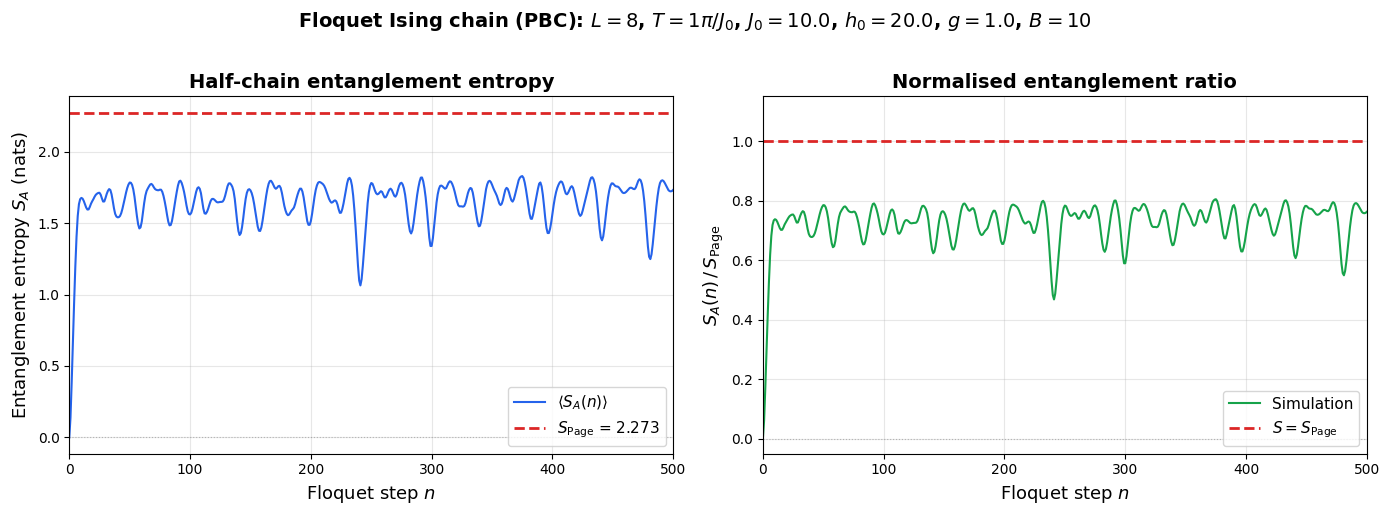


ENTANGLEMENT DYNAMICS SUMMARY
  Chain length:   L = 8
  Period:         T = 1·π/J₀ = 0.314159
  Coupling:       J₀ = 10.0
  Field:          h₀ = 20.0
  Perturbation:   g  = 1.0
  Averaged over:  B  = 10 product states

  S(0)           = -0.000000  (-0.0000 × S_Page)
  S(n=500)        = 1.732756  (0.7625 × S_Page)
  S_Page         = 2.272589
  Max S/S_Page   = 0.8046 at n = 375
  Steps to 0.9·S_Page: not reached


In [ ]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ============================================================
# PART 6B: PLOTTING — ENTANGLEMENT DYNAMICS
# ============================================================
#
# Consumes: steps, S_avg, S_Page  (from Part 6A)
# Also reads: L_sim, J_0_sim, h_0_sim, g_sim, n_period_sim,
#             n_floquet_steps, n_initial_states
#
# These variables must exist in the notebook namespace.
# ============================================================


def plot_entanglement_dynamics(steps, S_avg, S_Page, L, J_0, h_0, g,
                               n_period, n_states=None):
    """
    Plot entanglement entropy vs Floquet steps.

    Parameters
    ----------
    steps : ndarray
        Floquet step indices [0, 1, ..., n].
    S_avg : ndarray
        Averaged entanglement entropy at each step.
    S_Page : float
        Page value for this system size.
    L : int
        System size.
    J_0, h_0, g : float
        Hamiltonian parameters.
    n_period : int
        Integer n in T = n·π/J₀.
    n_states : int, optional
        Number of initial states averaged (for annotation).
    """
    S_ratio = S_avg / S_Page

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Left: Raw entropy S(n) ----
    ax1.plot(steps, S_avg, '-', lw=1.5, color='#2563eb', label=r'$\langle S_A(n) \rangle$')
    ax1.axhline(S_Page, color='#dc2626', ls='--', lw=2,
                label=f'$S_{{\\mathrm{{Page}}}}$ = {S_Page:.3f}')
    ax1.axhline(0, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax1.set_xlabel("Floquet step $n$", fontsize=13)
    ax1.set_ylabel("Entanglement entropy $S_A$ (nats)", fontsize=13)
    ax1.set_title("Half-chain entanglement entropy", fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(steps[0], steps[-1])
    ax1.set_ylim(bottom=-0.05 * S_Page)

    # ---- Right: Ratio S(n)/S_Page ----
    ax2.plot(steps, S_ratio, '-', lw=1.5, color='#16a34a', label='Simulation')
    ax2.axhline(1.0, color='#dc2626', ls='--', lw=2, label='$S = S_{\\mathrm{Page}}$')
    ax2.axhline(0, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax2.set_xlabel("Floquet step $n$", fontsize=13)
    ax2.set_ylabel(r"$S_A(n) \,/\, S_{\mathrm{Page}}$", fontsize=13)
    ax2.set_title("Normalised entanglement ratio", fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11, loc='lower right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(steps[0], steps[-1])
    ax2.set_ylim(-0.05, max(1.15, np.max(S_ratio) * 1.05))

    # ---- Suptitle with parameters ----
    title_str = (f"Floquet Ising chain (PBC): $L={L}$, "
                 f"$T={n_period}\\pi/J_0$, "
                 f"$J_0={J_0}$, $h_0={h_0}$, $g={g}$")
    if n_states is not None:
        title_str += f", $B={n_states}$"
    fig.suptitle(title_str, fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

    # ---- Text summary ----
    print("\n" + "=" * 70)
    print("ENTANGLEMENT DYNAMICS SUMMARY")
    print("=" * 70)
    print(f"  Chain length:   L = {L}")
    print(f"  Period:         T = {n_period}·π/J₀ = {n_period * np.pi / J_0:.6f}")
    print(f"  Coupling:       J₀ = {J_0}")
    print(f"  Field:          h₀ = {h_0}")
    print(f"  Perturbation:   g  = {g}")
    if n_states is not None:
        print(f"  Averaged over:  B  = {n_states} product states")
    print(f"\n  S(0)           = {S_avg[0]:.6f}  ({S_ratio[0]:.4f} × S_Page)")
    print(f"  S(n={len(steps)-1})        = {S_avg[-1]:.6f}  ({S_ratio[-1]:.4f} × S_Page)")
    print(f"  S_Page         = {S_Page:.6f}")
    print(f"  Max S/S_Page   = {np.max(S_ratio):.4f} at n = {steps[np.argmax(S_ratio)]}")

    idx_90 = np.where(S_ratio >= 0.9)[0]
    if len(idx_90) > 0:
        print(f"  Steps to 0.9·S_Page: n ≈ {steps[idx_90[0]]}")
    else:
        print(f"  Steps to 0.9·S_Page: not reached")
    print("=" * 70)


# ============================================================
# EXECUTE PLOT (uses variables from Part 6A)
# ============================================================

print("=" * 60)
print("PLOTTING RESULTS")
print("=" * 60)

plot_entanglement_dynamics(
    steps, S_avg, S_Page,
    L_sim, J_0_sim, h_0_sim, g_sim, n_period_sim,
    n_states=n_initial_states
)

# Prethermal Hilbert space fragmentation analysis

We move towards showing that the violation of ETH is due to Hilbert space fragmentation. We show this by showing that the entanglement entropy of an initial state belonging to the largest fragment saturates to the page value of the largest fragment.

References:


1.   Somsubhra Ghosh, Indranil Paul, and K. Sengupta, "Prethermal Fragmentation in a Periodically Driven Fermionic Chain," Phys. Rev. Lett. 130, 120401 (2023). doi: [10.1103/PhysRevLett.130.120401](https://doi.org/10.1103/PhysRevLett.130.120401).
2.   Pablo Sala et al., "Ergodicity Breaking Arising from Hilbert Space Fragmentation in Dipole-Conserving Hamiltonians," Phys. Rev. X 10, 011047 (2020). doi: [10.1103/PhysRevX.10.011047](https://doi.org/10.1103/PhysRevX.10.011047).

The fragmentation is prethermal because we are analysing only the first-order Floquet hamiltonian using Floquet perturbation theory.

Reference:

Arnab Sen, Diptiman Sen, and K. Sengupta, "Analytic approaches to periodically driven closed quantum systems: methods and applications," J. Phys.: Condens. Matter 33, 443003 (2021). doi: [10.1088/1361-648X/ac1b61](https://doi.org/10.1088/1361-648X/ac1b61).






## Floquet Hamiltonian and different fragments


The first-order Floquet Hamiltonian at the fragmentation driving time periods becomes:

$$
\boxed{\;
(H_F^{(1)})_{nm}
=-\langle n|g\sum_{i=1}^{L}\sigma_i^x|m\rangle\,\delta_{P_{nm},0},
\;}
$$

where, $P_{nm}$ is the difference between the operator $\mathcal{O}:=J_0\sum_{i=1}^{L}\sigma_i^z\sigma_{i+1}^z+2 J_0\sum_{i=1}^L\sigma_i^z$ eigenvalues in the nth and mth states in the Fock site basis.  

## Building the $\mathcal{O}$ operator for periodic boundary conditions:

$$\mathcal{O}:=J_0\sum_{i=1}^{L}\sigma_i^z\sigma_{i+1}^z+2 J_0\sum_{i=1}^L\sigma_i^z$$



In [ ]:
import numpy as np
from collections import deque


# ============================================================
# PART 8: FRAGMENT ANALYSIS — OPERATOR O CONSTRUCTION (PBC)
# ============================================================
#
# QuSpin-free implementation using bitwise arithmetic.
#
# O = J₀ Σ_{i=0}^{L-1} σ^z_i σ^z_{i+1}  +  2J₀ Σ_{i=0}^{L-1} σ^z_i
#
# with PBC: σ^z_{L} ≡ σ^z_0  (L ZZ bonds including wrap-around).
#
# O is purely diagonal in the computational basis.
# For state |n⟩ with bits b_0, b_1, ..., b_{L-1}:
#   σ^z_i = 1 - 2·b_i   (bit 0 → UP → +1, bit 1 → DOWN → -1)
#
# The bit position for site i uses the same convention as
# Prompt 1's sparse Hamiltonian: site i occupies bit (L-1-i).
# ============================================================


def build_O_operator(L, J0):
    """
    Build the diagonal operator O = J₀ Σ σ^z_i σ^z_{i+1} + 2J₀ Σ σ^z_i.

    Periodic boundary conditions: L ZZ bonds including wrap-around.

    Parameters
    ----------
    L : int
        Number of sites.
    J0 : float
        Coupling constant.

    Returns
    -------
    O_diag : ndarray, shape (2^L,), float64
        Diagonal elements O_n = ⟨n|O|n⟩ indexed by state integer.
    """
    Ns = 1 << L
    states = np.arange(Ns, dtype=np.int64)
    O_diag = np.zeros(Ns, dtype=np.float64)

    # --- ZZ terms: J₀ σ^z_i σ^z_{i+1} for i=0,...,L-1 (PBC) ---
    for i in range(L):
        # Bit positions (same convention as Prompt 1)
        pi  = L - 1 - i
        pi1 = L - 1 - ((i + 1) % L)

        # Extract bits at positions pi and pi1
        bi  = (states >> pi)  & 1   # 0 or 1
        bi1 = (states >> pi1) & 1

        # σ^z_i = 1 - 2·b_i,  σ^z_{i+1} = 1 - 2·b_{i+1}
        # Product: (1-2b_i)(1-2b_{i+1}) = 1 - 2b_i - 2b_{i+1} + 4b_i·b_{i+1}
        # Equivalently: +1 if bits match, -1 if they differ
        sz_i  = 1 - 2 * bi
        sz_i1 = 1 - 2 * bi1
        O_diag += J0 * sz_i * sz_i1

    # --- Z terms: 2·J₀ σ^z_i for i=0,...,L-1 ---
    for i in range(L):
        pi = L - 1 - i
        bi = (states >> pi) & 1
        sz_i = 1 - 2 * bi
        O_diag += 2.0 * J0 * sz_i

    return O_diag


# ============================================================
# SELF-TESTS
# ============================================================

print("\n" + "=" * 60)
print("PART 8: Building Operator O for Fragment Identification (PBC)")
print("=" * 60)

# Parameters
L_frag = 12
J0_frag = 10.0
Ns = 2**L_frag

print(f"\nParameters: L = {L_frag}, J0 = {J0_frag}")
print(f"Boundary conditions: PERIODIC (L = {L_frag} ZZ bonds)")

# Build O diagonal
O_diag = build_O_operator(L_frag, J0_frag)

print(f"O_diag shape: {O_diag.shape}")
print(f"Hilbert space dimension: Ns = {Ns}")

# ---- Analytical verification ----
# State 0 (all bits=0) = all UP:
#   ZZ: (+1)(+1) × L bonds = L·J₀
#   Z:  2·J₀·(+1)·L = 2L·J₀
#   Total: 3L·J₀
expected_all_up = 3 * L_frag * J0_frag

# State 2^L-1 (all bits=1) = all DOWN:
#   ZZ: (-1)(-1) × L bonds = L·J₀
#   Z:  2·J₀·(-1)·L = -2L·J₀
#   Total: -L·J₀
expected_all_down = -L_frag * J0_frag

print(f"\nVerification (PBC):")
print(f"  O_diag[0] = {O_diag[0]:.1f} (all UP, expected: {expected_all_up})")
print(f"  O_diag[{Ns-1}] = {O_diag[Ns-1]:.1f} (all DOWN, expected: {expected_all_down})")

assert np.isclose(O_diag[0], expected_all_up), \
    f"O_diag[0] failed: got {O_diag[0]}, expected {expected_all_up}"
assert np.isclose(O_diag[Ns-1], expected_all_down), \
    f"O_diag[{Ns-1}] failed: got {O_diag[Ns-1]}, expected {expected_all_down}"
print("  PASS: all-up and all-down states verified")

# ---- Additional test: single domain wall ----
# State |0...01⟩ (bit L-1 = 1, rest 0):
#   Site 0..L-2 are UP (+1), site L-1 is DOWN (-1)
#   ZZ bonds: (L-2) same-spin bonds (+1 each) +
#             1 bond between site L-2 (UP) and L-1 (DOWN) = -1
#             1 wrap-around bond between site L-1 (DOWN) and 0 (UP) = -1
#   Total ZZ: (L-2)·J₀ + (-1)·J₀ + (-1)·J₀ = (L-4)·J₀
#   Z terms: 2·J₀·((L-1)·(+1) + 1·(-1)) = 2·J₀·(L-2)
#   Total: (L-4)·J₀ + 2·J₀·(L-2)

state_one_down = 1  # binary: 0...01 → site L-1 is DOWN
expected_one = (L_frag - 4) * J0_frag + 2.0 * J0_frag * (L_frag - 2)
print(f"\n  O_diag[1] = {O_diag[1]:.1f} (one domain wall, expected: {expected_one})")
assert np.isclose(O_diag[1], expected_one), \
    f"O_diag[1] failed: got {O_diag[1]}, expected {expected_one}"
print("  PASS: single domain wall verified")

# ---- Symmetry check: O values are invariant under global spin flip ----
# If we flip all spins: state n → state ~n (bitwise complement)
# ZZ terms unchanged (both spins flip, product same)
# Z terms change sign
# So O(~n) = ZZ_part - Z_part while O(n) = ZZ_part + Z_part
# This means O(n) + O(~n) = 2·ZZ_part(n)
print(f"\n  Spin-flip symmetry check:")
n_check = 0
n_flip = (Ns - 1) ^ n_check  # bitwise complement
sum_val = O_diag[n_check] + O_diag[n_flip]
expected_2zz = 2.0 * L_frag * J0_frag  # all-up: ZZ_part = L·J₀
print(f"  O(0) + O({n_flip}) = {sum_val:.1f} (expected 2·ZZ = {expected_2zz})")
assert np.isclose(sum_val, expected_2zz)
print("  PASS")

# ---- L=2 analytical (exhaustive) ----
print(f"\n  L=2 exhaustive check:")
O2 = build_O_operator(2, 1.0)
# L=2 PBC: 2 ZZ bonds (both wrap around = same bond counted twice)
# Actually L=2 PBC: bond 0-1 and bond 1-0 → same as 2·σ^z_0·σ^z_1
# State 0 (|00⟩ = ↑↑): ZZ = 2·(+1)(+1) = 2, Z = 2·1·(+1+1) = 4 → O = 6
# State 1 (|01⟩ = ↑↓): ZZ = 2·(+1)(-1) = -2, Z = 2·1·(+1-1) = 0 → O = -2
# State 2 (|10⟩ = ↓↑): ZZ = 2·(-1)(+1) = -2, Z = 2·1·(-1+1) = 0 → O = -2
# State 3 (|11⟩ = ↓↓): ZZ = 2·(-1)(-1) = 2, Z = 2·1·(-1-1) = -4 → O = -2
O2_expected = np.array([6.0, -2.0, -2.0, -2.0])
print(f"  O_diag(L=2) = {O2}")
print(f"  Expected     = {O2_expected}")
assert np.allclose(O2, O2_expected)
print("  PASS: L=2 exhaustive match")

print("\n" + "=" * 60)
print("Part 8 complete: O operator built successfully (PBC, no QuSpin)")
print("=" * 60)


PART 8: Building Operator O for Fragment Identification (PBC)

Parameters: L = 12, J0 = 10.0
Boundary conditions: PERIODIC (L = 12 ZZ bonds)
O_diag shape: (4096,)
Hilbert space dimension: Ns = 4096

Verification (PBC):
  O_diag[0] = 360.0 (all UP, expected: 360.0)
  O_diag[4095] = -120.0 (all DOWN, expected: -120.0)
  PASS: all-up and all-down states verified

  O_diag[1] = 280.0 (one domain wall, expected: 280.0)
  PASS: single domain wall verified

  Spin-flip symmetry check:
  O(0) + O(4095) = 240.0 (expected 2·ZZ = 240.0)
  PASS

  L=2 exhaustive check:
  O_diag(L=2) = [ 6. -2. -2. -2.]
  Expected     = [ 6. -2. -2. -2.]
  PASS: L=2 exhaustive match

Part 8 complete: O operator built successfully (PBC, no QuSpin)


## Connectivity graph and largest fragment:




In [ ]:
import numpy as np
from collections import deque


# ============================================================
# PART 9: CONNECTIVITY GRAPH AND FRAGMENT IDENTIFICATION
#         WITH ↑↑ BOND ANALYSIS (No QuSpin)
# ============================================================
#
# Prerequisites: Part 8 (O operator)
#   Required from Part 8: O_diag, L_frag, J0_frag
#
# Produces: adjacency, components, stats, largest_fragment,
#           D_largest, N_defect_all, bond_patterns_all,
#           fragment_summary
# ============================================================


# ============================================================
# CONNECTIVITY GRAPH
# ============================================================

def build_connectivity_graph(L, O_diag, tol=1e-10):
    """
    Build the connectivity graph for Hilbert space fragmentation.

    Edge (n, m) exists if:
      1. States n and m differ by exactly one spin flip
      2. |O_n - O_m| < tol (resonance condition P_nm = 0)

    Parameters
    ----------
    L : int
        Number of sites.
    O_diag : ndarray
        Diagonal elements of O operator.
    tol : float
        Tolerance for resonance condition.

    Returns
    -------
    adjacency : list of lists
        adjacency[n] = list of neighbours of state n.
    num_edges : int
        Total number of edges.
    """
    Ns = 1 << L
    adjacency = [[] for _ in range(Ns)]
    num_edges = 0

    for n in range(Ns):
        O_n = O_diag[n]
        for i in range(L):
            m = n ^ (1 << i)
            if m > n:
                if abs(O_n - O_diag[m]) < tol:
                    adjacency[n].append(m)
                    adjacency[m].append(n)
                    num_edges += 1

    return adjacency, num_edges


def find_connected_components(adjacency):
    """
    Find connected components using BFS.

    Parameters
    ----------
    adjacency : list of lists
        Adjacency list representation.

    Returns
    -------
    components : list of lists
        Each element is a sorted list of state indices in that fragment.
    """
    Ns = len(adjacency)
    visited = [False] * Ns
    components = []

    for start in range(Ns):
        if not visited[start]:
            component = []
            queue = deque([start])
            visited[start] = True
            while queue:
                node = queue.popleft()
                component.append(node)
                for neighbor in adjacency[node]:
                    if not visited[neighbor]:
                        visited[neighbor] = True
                        queue.append(neighbor)
            components.append(sorted(component))

    return components


def get_fragment_statistics(components):
    """Compute statistics about the fragments."""
    sizes = [len(c) for c in components]
    size_counts = {}
    for s in sizes:
        size_counts[s] = size_counts.get(s, 0) + 1

    return {
        'num_fragments': len(components),
        'sizes': sorted(sizes),
        'max_size': max(sizes),
        'min_size': min(sizes),
        'num_singletons': sum(1 for s in sizes if s == 1),
        'size_counts': size_counts,
    }


def find_largest_fragment(components):
    """Return the largest fragment (list of state indices)."""
    return max(components, key=len)


# ============================================================
# SPIN CONFIGURATION HELPERS
# ============================================================

def get_spin_config(state_idx, L):
    """
    Get spin configuration string for a state.
    Convention: bit=0 → UP (↑), bit=1 → DOWN (↓).
    """
    spins = []
    for i in range(L):
        bit = (state_idx >> i) & 1
        spins.append('↓' if bit else '↑')
    return ''.join(spins)


def get_spin_array(state_idx, L):
    """
    Convert state index to array S[i] = ±1.
    bit=0 → +1 (up), bit=1 → -1 (down).
    """
    S = np.empty(L, dtype=int)
    for i in range(L):
        bit = (state_idx >> i) & 1
        S[i] = +1 if bit == 0 else -1
    return S


# ============================================================
# ↑↑ BOND ANALYSIS
# ============================================================

def get_upup_bond_pattern(state_idx, L):
    """
    Return length-L array: p[i]=1 if bond (i, i+1 mod L) is ↑↑, else 0.
    """
    S = get_spin_array(state_idx, L)
    p = np.zeros(L, dtype=int)
    for i in range(L):
        if S[i] == +1 and S[(i + 1) % L] == +1:
            p[i] = 1
    return p


def get_N_defect(state_idx, L):
    """Number of ↑↑ bonds in the configuration."""
    return int(get_upup_bond_pattern(state_idx, L).sum())


def bond_pattern_to_string(p):
    """Convert integer array p[i] ∈ {0,1} to string '0101...'."""
    return ''.join(str(x) for x in p)


# ============================================================
# DISPLAY FUNCTIONS
# ============================================================

def display_fragment_states(fragment_states, L, O_diag, adjacency,
                            N_defect_all=None, bond_patterns_all=None):
    """Display detailed information about states in a fragment."""
    print(f"  {'#':<4} {'Index':<8} {'Binary':<{L+2}} {'Spins':<{L+2}} "
          f"{'O value':<12} {'N_def':<6} {'Bonds(↑↑)':<{L+2}} {'Neighbors'}")
    print("  " + "-" * (55 + 3 * L))

    for i, state_idx in enumerate(fragment_states):
        binary_str = format(state_idx, f'0{L}b')
        spin_str = get_spin_config(state_idx, L)
        O_val = O_diag[state_idx]

        N_def = N_defect_all[state_idx] if N_defect_all is not None else 0
        if bond_patterns_all is not None:
            p = bond_patterns_all[state_idx]
            bond_str = bond_pattern_to_string(p) if isinstance(p, np.ndarray) else str(p)
        else:
            bond_str = ""

        neighbors_in_frag = [m for m in adjacency[state_idx] if m in fragment_states]
        neighbors_str = str(neighbors_in_frag) if neighbors_in_frag else "[]"

        print(f"  {i+1:<4} {state_idx:<8} {binary_str:<{L+2}} {spin_str:<{L+2}} "
              f"{O_val:<12.2f} {N_def:<6} {bond_str:<{L+2}} {neighbors_str}")


def display_all_fragments(components, L, O_diag, adjacency,
                          N_defect_all=None, bond_patterns_all=None,
                          sort_by_size=True, show_singletons=True,
                          max_display=None):
    """Display detailed information about ALL fragments."""
    sorted_comps = sorted(components, key=len, reverse=True) if sort_by_size else components
    if not show_singletons:
        sorted_comps = [c for c in sorted_comps if len(c) > 1]
    if max_display is not None:
        sorted_comps = sorted_comps[:max_display]

    print(f"\n{'=' * 90}")
    print(f"DETAILED FRAGMENT DATA (Showing {len(sorted_comps)} of {len(components)} fragments)")
    print(f"{'=' * 90}")

    for frag_idx, fragment in enumerate(sorted_comps):
        D = len(fragment)
        O_val = O_diag[fragment[0]]
        internal_edges = sum(len([m for m in adjacency[s] if m in fragment])
                             for s in fragment) // 2

        N_def_str = ""
        if N_defect_all is not None:
            N_vals = set(N_defect_all[s] for s in fragment)
            N_def_str = f", N_defect = {N_vals}"

        print(f"\n{'─' * 90}")
        print(f"FRAGMENT {frag_idx + 1}: D = {D} states, O = {O_val:.2f}, "
              f"Internal edges = {internal_edges}{N_def_str}")
        print(f"{'─' * 90}")
        display_fragment_states(fragment, L, O_diag, adjacency,
                                N_defect_all, bond_patterns_all)

    print(f"\n{'=' * 90}")
    print(f"End of fragment data")
    print(f"{'=' * 90}")


# ============================================================
# SUMMARY TABLE
# ============================================================

def create_fragment_summary_table(components, L, O_diag, adjacency,
                                  N_defect_all=None, bond_patterns_all=None):
    """Create a summary table of all fragments with ↑↑ bond analysis."""
    summary = []

    for frag_idx, fragment in enumerate(components):
        D = len(fragment)
        O_val = O_diag[fragment[0]]
        internal_edges = sum(len([m for m in adjacency[s] if m in fragment])
                             for s in fragment) // 2

        N_def_unique = sorted(set(N_defect_all[s] for s in fragment)) \
            if N_defect_all is not None else []
        patterns_unique = sorted(set(
            bond_pattern_to_string(bond_patterns_all[s]) for s in fragment
        )) if bond_patterns_all is not None else []

        summary.append({
            'fragment_id': frag_idx + 1,
            'size': D,
            'O_value': O_val,
            'internal_edges': internal_edges,
            'states': fragment,
            'N_defect_values': N_def_unique,
            'bond_patterns': patterns_unique,
        })

    summary.sort(key=lambda x: x['size'], reverse=True)
    return summary


def print_fragment_summary_table(summary, L):
    """Print compact summary table."""
    print(f"\n{'=' * 110}")
    print("FRAGMENT SUMMARY TABLE (with ↑↑ bond analysis)")
    print(f"{'=' * 110}")
    print(f"{'ID':<6} {'Size':<8} {'O value':<12} {'Edges':<8} "
          f"{'#N_def':<8} {'#patterns':<12} {'N_def':<8} {'Example pattern':<{L+2}}")
    print(f"{'-' * 110}")

    for frag in summary:
        N_list = frag.get('N_defect_values', [])
        pat_list = frag.get('bond_patterns', [])
        example_pat = pat_list[0] if pat_list else ''
        example_N = str(N_list[0]) if N_list else ''

        print(f"{frag['fragment_id']:<6} {frag['size']:<8} {frag['O_value']:<12.2f} "
              f"{frag['internal_edges']:<8} {len(N_list):<8} {len(pat_list):<12} "
              f"{example_N:<8} {example_pat:<{L+2}}")

    print(f"{'=' * 110}")


# ============================================================
# FIBONACCI CHECK
# ============================================================

def fib(n):
    """Compute n-th Fibonacci number (F_0=0, F_1=1, F_2=1, ...)."""
    a, b = 0, 1
    for _ in range(n):
        a, b = b, a + b
    return a


# ============================================================
# EXECUTE PART 9
# ============================================================

print("\n" + "=" * 60)
print("PART 9: Building Connectivity Graph and Finding Fragments")
print("        (with ↑↑ bond analysis)")
print("=" * 60)

Ns = 2**L_frag
tol = 1e-10
print(f"\nParameters: L = {L_frag}, J0 = {J0_frag}, tol = {tol}")

# --- Precompute N_defect and bond patterns ---
print("\nPrecomputing N_defect and ↑↑ bond patterns for all states...")
N_defect_all = np.zeros(Ns, dtype=int)
bond_patterns_all = [None] * Ns

for n in range(Ns):
    p = get_upup_bond_pattern(n, L_frag)
    bond_patterns_all[n] = p
    N_defect_all[n] = int(p.sum())

print(f"  N_defect range: {N_defect_all.min()} to {N_defect_all.max()}")
print(f"  N_defect distribution:")
for n_val in range(N_defect_all.max() + 1):
    count = np.sum(N_defect_all == n_val)
    if count > 0:
        print(f"    N_defect = {n_val}: {count} states")

# --- Build connectivity graph ---
print("\nBuilding connectivity graph...")
adjacency, num_edges = build_connectivity_graph(L_frag, O_diag, tol)

total_possible_edges = Ns * L_frag // 2
print(f"  Number of edges: {num_edges}")
print(f"  Total possible edges (all single-flips): {total_possible_edges}")
print(f"  Fraction kept: {num_edges / total_possible_edges:.4f}")

# --- Find connected components ---
print("\nFinding connected components...")
components = find_connected_components(adjacency)
stats = get_fragment_statistics(components)

print(f"\n  Number of fragments: {stats['num_fragments']}")
print(f"  Largest fragment size: {stats['max_size']}")
print(f"  Number of singletons: {stats['num_singletons']}")

print("\n  Size distribution:")
print(f"    {'Size':<8} {'Count':<8} {'Total':<8}")
print("    " + "-" * 24)
for size in sorted(stats['size_counts'].keys()):
    count = stats['size_counts'][size]
    print(f"    {size:<8} {count:<8} {size * count:<8}")

# --- Largest fragment ---
largest_fragment = find_largest_fragment(components)
D_largest = len(largest_fragment)

print(f"\n  Largest fragment has D = {D_largest} states")
print(f"  O value in largest fragment: {O_diag[largest_fragment[0]]:.1f}")

total_states = sum(len(c) for c in components)
assert total_states == Ns, f"Total states mismatch: {total_states} != {Ns}"
print(f"\n  Total states across all fragments: {total_states} = Ns ✓")

# --- Summary table ---
fragment_summary = create_fragment_summary_table(
    components, L_frag, O_diag, adjacency,
    N_defect_all, bond_patterns_all
)
print_fragment_summary_table(fragment_summary, L_frag)

# --- ↑↑ bond pattern analysis ---
print("\n" + "=" * 70)
print("↑↑ BOND PATTERN ANALYSIS")
print("=" * 70)

num_single_pattern = sum(1 for frag in fragment_summary
                         if len(frag['bond_patterns']) == 1)
print(f"\nFragments with a single frozen ↑↑-bond pattern: "
      f"{num_single_pattern}/{len(fragment_summary)}")

num_single_N = sum(1 for frag in fragment_summary
                   if len(frag['N_defect_values']) == 1)
print(f"Fragments with a single N_defect value: "
      f"{num_single_N}/{len(fragment_summary)}")

largest = fragment_summary[0]
print("\nLargest fragment details:")
print(f"  ID: {largest['fragment_id']}")
print(f"  Size: {largest['size']}")
print(f"  O value: {largest['O_value']:.2f}")
print(f"  N_defect values: {largest['N_defect_values']}")
print(f"  Bond patterns: {largest['bond_patterns']}")
print(f"  Number of distinct patterns: {len(largest['bond_patterns'])}")

if largest['N_defect_values'] == [0]:
    print("  ✓ Largest fragment has N_defect = 0 (no ↑↑ bonds)")
else:
    print(f"  ⚠ Largest fragment has N_defect = {largest['N_defect_values']}")

if largest['bond_patterns'] == ['0' * L_frag]:
    print(f"  ✓ Bond pattern is all zeros: {'0' * L_frag}")

# --- Fibonacci check ---
print("\n" + "-" * 70)
print("Fibonacci consistency check (no adjacent ↑ on ring):")
print("-" * 70)

dim_no_adj_ring = fib(L_frag - 1) + fib(L_frag + 1)
print(f"  L = {L_frag}")
print(f"  F_{L_frag-1} = {fib(L_frag - 1)}")
print(f"  F_{L_frag+1} = {fib(L_frag + 1)}")
print(f"  Predicted dimension (no adjacent ↑ on ring): "
      f"F_{L_frag-1} + F_{L_frag+1} = {dim_no_adj_ring}")
print(f"  Largest fragment size: {D_largest}")

if D_largest == dim_no_adj_ring:
    print(f"  ✓ Matches! Largest fragment = configurations with no ↑↑ bonds")
else:
    print(f"  ⚠ Mismatch: {D_largest} ≠ {dim_no_adj_ring}")

# --- Display non-singleton fragments ---
display_all_fragments(
    components, L_frag, O_diag, adjacency,
    N_defect_all, bond_patterns_all,
    sort_by_size=True, show_singletons=False, max_display=None
)

# --- Display singletons ---
singleton_count = stats['num_singletons']
if singleton_count > 0:
    print(f"\n{'=' * 80}")
    print(f"SINGLETON FRAGMENTS (Size = 1): {singleton_count} total")
    print(f"{'=' * 80}")
    print(f"  {'Index':<8} {'Binary':<{L_frag+2}} {'Spins':<{L_frag+2}} "
          f"{'O value':<12} {'N_def':<6} {'Bonds(↑↑)'}")
    print("  " + "-" * (50 + 3 * L_frag))

    singletons = sorted(c[0] for c in components if len(c) == 1)
    for state_idx in singletons:
        binary_str = format(state_idx, f'0{L_frag}b')
        spin_str = get_spin_config(state_idx, L_frag)
        O_val = O_diag[state_idx]
        N_def = N_defect_all[state_idx]
        bond_str = bond_pattern_to_string(bond_patterns_all[state_idx])
        print(f"  {state_idx:<8} {binary_str:<{L_frag+2}} {spin_str:<{L_frag+2}} "
              f"{O_val:<12.2f} {N_def:<6} {bond_str}")

print("\n" + "=" * 60)
print("Part 9 complete: Fragments identified successfully")
print("              (with ↑↑ bond conservation analysis)")
print("=" * 60)

Streaming output truncated to the last 5000 lines.
──────────────────────────────────────────────────────────────────────────────────────────
  #    Index    Binary         Spins          O value      N_def  Bonds(↑↑)      Neighbors
  -------------------------------------------------------------------------------------------
  1    2720     101010100000   ↑↑↑↑↑↓↑↓↑↓↑↓   40.00        4      111100000000   [2784, 2976, 3744]
  2    2784     101011100000   ↑↑↑↑↑↓↓↓↑↓↑↓   40.00        4      111100000000   [2720, 3040, 3808]
  3    2912     101101100000   ↑↑↑↑↑↓↓↑↓↓↑↓   40.00        4      111100000000   [3040, 3936]
  4    2976     101110100000   ↑↑↑↑↑↓↑↓↓↓↑↓   40.00        4      111100000000   [2720, 3040, 4000]
  5    3040     101111100000   ↑↑↑↑↑↓↓↓↓↓↑↓   40.00        4      111100000000   [2784, 2912, 2976, 4064]
  6    3424     110101100000   ↑↑↑↑↑↓↓↑↓↑↓↓   40.00        4      111100000000   [3552, 3936]
  7    3488     110110100000   ↑↑↑↑↑↓↑↓↓↑↓↓   40.00        4      111100000000 

## Fragment Page value by Monte Carlo sampling:
What Page actually did
Take a bipartite Hilbert space
$$
\mathcal H = \mathcal H_A \otimes \mathcal H_B, \quad
\dim \mathcal H_A = m \le \dim \mathcal H_B = n.
$$
Choose a pure state $|\psi\rangle$ uniformly at random with respect to the Haar measure on $\mathcal H$. Let $S_A(\psi)$ be the von Neumann entropy of the reduced density matrix $\rho_A = \mathrm{Tr}_B |\psi\rangle\langle\psi|$.
Page's entropy is
$$
\boxed{
\langle S_A \rangle_{Page} := \mathbb{E}_{\psi\ Haar}[S_A(\psi)]
}
$$

Generalizing to a fragment subspace, take some subspace $\mathcal D \subset \mathcal H$ of dimension $D$. We want the fragment Page value.
We fix the bipartition $A|B$.
We put the Haar measure on $\mathcal D$ (random normalized linear combinations of an orthonormal basis of $\mathcal D$).
Then the fragment Page value is
$$
S_p^{\mathcal D} := \mathbb{E}_{\psi \in \mathcal D}[,S_A(\psi)].
$$

So in the fragmentation story:
*   Full symmetry sector: Page value $S_p^{(sector)}$.
*   Fragment subspace $\mathcal D$: Page value $S_p^{(\mathcal D)}$.


Thus,
*   If dynamics explores the whole sector ergodically:
$S_{sat} \approx S_p^{(sector)}$.
*   If dynamics is confined to a fragment and is ergodic inside that fragment:
$S_{sat} \approx S_p^{(\mathcal D)}$.




The fragment Page value formula is:

$$
S_p^{(\mathcal D)} := \mathbb{E}_{\psi \in \mathcal{D}}\bigl[S_A(\psi)\bigr].
$$



In [ ]:
import numpy as np


# ============================================================
# PART 10: FRAGMENT PAGE VALUE VIA MONTE CARLO
# ============================================================
#
# Prerequisites: Parts 8-9 (O operator, fragment identification)
#   Required: largest_fragment, D_largest, L_frag
#   Required from Prompt 4: bipartite_entropy, compute_page_value
#
# Produces: S_page_full, S_page_frag, S_std_frag, S_sem_frag
# ============================================================


def sample_haar_state_in_fragment(fragment_states, Ns, rng=None):
    """
    Sample a Haar-random state in the fragment subspace.

    |ψ⟩ = Σ_α c_α |φ_α⟩  where c_α are normalised complex
    Gaussian coefficients and {|φ_α⟩} are computational basis
    states in the fragment.

    Parameters
    ----------
    fragment_states : array-like of int
        Basis state indices in the fragment.  Converted to ndarray
        once by the caller for best performance.
    Ns : int
        Full Hilbert space dimension (2^L).
    rng : np.random.Generator or None
        If None, uses global np.random for backward compatibility.

    Returns
    -------
    psi : ndarray, shape (Ns,), complex128
        Haar-random state with support only on fragment states.
    """
    D = len(fragment_states)

    if rng is None:
        z = np.random.randn(D) + 1j * np.random.randn(D)
    else:
        z = rng.standard_normal(D) + 1j * rng.standard_normal(D)

    c = z / np.linalg.norm(z)

    # Vectorised scatter into full Hilbert space
    psi = np.zeros(Ns, dtype=np.complex128)
    psi[fragment_states] = c          # fancy indexing, no Python loop

    return psi


def compute_fragment_page_value_MC(fragment_states, L, n_samples=1000,
                                    A_indices=None, seed=None,
                                    verbose=True):
    """
    Compute the fragment Page value via Monte Carlo sampling.

    S_Page^(frag) = E_{ψ ∈ fragment}[S_A(ψ)]

    Parameters
    ----------
    fragment_states : list or array of int
        List of basis state indices in the fragment.
    L : int
        Number of sites.
    n_samples : int
        Number of Haar-random states to sample.
    A_indices : list, optional
        Subsystem A indices (default: left half-chain).
    seed : int or None
        RNG seed for reproducibility. None = non-reproducible.
    verbose : bool
        Print progress.

    Returns
    -------
    S_page_frag : float
        Fragment Page value (mean entropy).
    S_std : float
        Standard deviation of entropy distribution.
    S_sem : float
        Standard error of the mean.
    """
    Ns = 1 << L
    D = len(fragment_states)

    if A_indices is None:
        A_indices = list(range(L // 2))

    # Convert to array once for vectorised scatter in sampler
    frag_arr = np.asarray(fragment_states)

    rng = np.random.default_rng(seed)

    if verbose:
        print(f"\nComputing fragment Page value via Monte Carlo...")
        print(f"  Fragment dimension: D = {D}")
        print(f"  Number of samples: {n_samples}")
        print(f"  Subsystem A: sites {A_indices}")
        if seed is not None:
            print(f"  Seed: {seed}")

    entropies = np.zeros(n_samples)

    for r in range(n_samples):
        psi = sample_haar_state_in_fragment(frag_arr, Ns, rng)
        entropies[r] = bipartite_entropy(psi, L, A_indices)

        if verbose and (r + 1) % 2000 == 0:
            print(f"    Completed {r + 1}/{n_samples} samples")

    S_page_frag = np.mean(entropies)
    S_std = np.std(entropies, ddof=1)
    S_sem = S_std / np.sqrt(n_samples)

    if verbose:
        print(f"\n  Results:")
        print(f"    S_Page^(frag) = {S_page_frag:.6f} ± {S_sem:.6f} nats")
        print(f"    Std dev = {S_std:.6f}")
        print(f"    Min entropy: {np.min(entropies):.6f}")
        print(f"    Max entropy: {np.max(entropies):.6f}")

    return S_page_frag, S_std, S_sem


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

n_MC_samples = 10000     # Number of Monte Carlo samples
seed_MC      = 42        # RNG seed (None for non-reproducible)

# ============================================================
# EXECUTE PART 10
# ============================================================

print("\n" + "=" * 60)
print("PART 10: Computing Fragment Page Value via Monte Carlo")
print("=" * 60)

# Full Hilbert space Page value (analytical)
S_page_full = compute_page_value(L_frag)
print(f"\nFull Hilbert space Page value: S_Page = {S_page_full:.6f} nats")

# Fragment Page value (Monte Carlo)
S_page_frag, S_std_frag, S_sem_frag = compute_fragment_page_value_MC(
    largest_fragment, L_frag,
    n_samples=n_MC_samples,
    seed=seed_MC,
    verbose=True
)

# Summary
print("\n" + "-" * 40)
print("COMPARISON:")
print("-" * 40)
Ns_p10 = 2**L_frag
print(f"  Full Hilbert space (Ns = {Ns_p10}):")
print(f"    S_Page = {S_page_full:.6f} nats")
print(f"\n  Largest fragment (D = {D_largest}):")
print(f"    S_Page^(frag) = {S_page_frag:.6f} ± {S_sem_frag:.6f} nats")
print(f"\n  Ratio: S_Page^(frag) / S_Page = {S_page_frag / S_page_full:.4f}")

d_A = 2**(L_frag // 2)
max_possible = np.log(min(D_largest, d_A))
print(f"\n  Theoretical upper bound: ln(min(D, d_A)) = "
      f"ln({min(D_largest, d_A)}) = {max_possible:.6f}")

print("\n" + "=" * 60)
print("Part 10 complete: Fragment Page value computed")
print("=" * 60)


PART 10: Computing Fragment Page Value via Monte Carlo

Full Hilbert space Page value: S_Page = 3.658883 nats

Computing fragment Page value via Monte Carlo...
  Fragment dimension: D = 322
  Number of samples: 10000
  Subsystem A: sites [0, 1, 2, 3, 4, 5]
  Seed: 42
    Completed 2000/10000 samples
    Completed 4000/10000 samples
    Completed 6000/10000 samples
    Completed 8000/10000 samples
    Completed 10000/10000 samples

  Results:
    S_Page^(frag) = 2.471124 ± 0.000274 nats
    Std dev = 0.027445
    Min entropy: 2.355525
    Max entropy: 2.566388

----------------------------------------
COMPARISON:
----------------------------------------
  Full Hilbert space (Ns = 4096):
    S_Page = 3.658883 nats

  Largest fragment (D = 322):
    S_Page^(frag) = 2.471124 ± 0.000274 nats

  Ratio: S_Page^(frag) / S_Page = 0.6754

  Theoretical upper bound: ln(min(D, d_A)) = ln(64) = 4.158883

Part 10 complete: Fragment Page value computed


## Entanglement entropy of the state in a particular fragment

We cannot take a Haar single qubit states and tensor product them to get a pure state in the largest fragment because  we obtain these fragments for a fixed basis. Thus, we instead just choose a random state in the largest fragment and see it evolve.

### Definitions

In [ ]:
import numpy as np
import time


# ============================================================
# FRAGMENT STATE GENERATION
# ============================================================
#
# Prerequisites:
#   Prompt 2: apply_floquet_step
#   Prompt 4: bipartite_entropy
#   (only needed by self-tests: FloquetIsingChain, build_floquet_operator)
#
# Defines:
#   build_random_basis_state_in_fragment(fragment_states, L, rng)
#   build_fragment_states_batched(fragment_states, L, num_states, rng)
#   compute_entanglement_dynamics_fragment_basis(ising_chain, ...)
# ============================================================


def build_random_basis_state_in_fragment(fragment_states, L, rng=None):
    """
    Pick a random computational basis state from a fragment.

    The returned state |n⟩ is a standard basis vector (delta function),
    which is a product state with S_A = 0 for any bipartition.

    Parameters
    ----------
    fragment_states : list or array of int
        Basis state indices belonging to the fragment.
    L : int
        Number of sites.
    rng : np.random.Generator or None
        If None, uses np.random for backward compatibility.

    Returns
    -------
    psi : ndarray, shape (2^L,), complex128
        Computational basis state.
    state_idx : int
        The chosen basis state index.
    """
    Ns = 1 << L

    if rng is None:
        idx = np.random.randint(len(fragment_states))
    else:
        idx = rng.integers(len(fragment_states))

    state_idx = fragment_states[idx]
    psi = np.zeros(Ns, dtype=np.complex128)
    psi[state_idx] = 1.0

    return psi, state_idx


def build_fragment_states_batched(fragment_states, L, num_states, rng=None):
    """
    Build B random computational basis states from a fragment as (Ns × B).

    Each column is a delta function |n_k⟩ where n_k is drawn uniformly
    from fragment_states (with replacement). All columns have S_A = 0.

    Parameters
    ----------
    fragment_states : list or array of int
        Basis state indices in the fragment.
    L : int
        Number of sites.
    num_states : int
        Number of states B.
    rng : np.random.Generator or None
        If None, creates default_rng(42).

    Returns
    -------
    Psi : ndarray, shape (2^L, num_states), complex128
        Matrix whose columns are computational basis states.
    chosen_indices : ndarray, shape (num_states,), int
        The basis state indices that were selected.
    """
    if rng is None:
        rng = np.random.default_rng(42)

    Ns = 1 << L
    fragment_arr = np.asarray(fragment_states)
    chosen = rng.choice(fragment_arr, size=num_states, replace=True)

    Psi = np.zeros((Ns, num_states), dtype=np.complex128)
    for k in range(num_states):
        Psi[chosen[k], k] = 1.0

    return Psi, chosen


# ============================================================
# FRAGMENT ENTANGLEMENT DYNAMICS — BATCHED KRYLOV
# ============================================================

def compute_entanglement_dynamics_fragment_basis(ising_chain, fragment_states,
                                                  n_periods, n_initial_states=10,
                                                  A_indices=None, seed=42,
                                                  verbose=True,
                                                  renorm_interval=100):
    """
    Compute entanglement entropy evolution starting from random
    computational basis states within a Hilbert space fragment.

    Parameters
    ----------
    ising_chain : FloquetIsingChain
        Initialised chain with build_hamiltonians() called.
    fragment_states : list or array of int
        Basis state indices belonging to the fragment.
    n_periods : int
        Number of Floquet periods to evolve.
    n_initial_states : int
        Number of random basis states to average over (B).
    A_indices : list of int, optional
        Subsystem A indices. Default: left half-chain.
    seed : int
        RNG seed for reproducibility.
    verbose : bool
        Print progress information.
    renorm_interval : int
        Renormalise every N steps (0 to disable).

    Returns
    -------
    steps : ndarray, shape (n_periods + 1,)
        Time step indices [0, 1, ..., n_periods].
    S_avg : ndarray, shape (n_periods + 1,)
        Averaged entanglement entropy at each step.
    """
    L = ising_chain.L
    Ns = ising_chain.Ns
    D_frag = len(fragment_states)

    if A_indices is None:
        A_indices = list(range(L // 2))

    # --- Build batched initial states from fragment ---
    rng = np.random.default_rng(seed)
    Psi, chosen_indices = build_fragment_states_batched(
        fragment_states, L, n_initial_states, rng
    )

    S_avg = np.zeros(n_periods + 1, dtype=np.float64)

    if verbose:
        print(f"  Evolving {n_initial_states} random basis states from fragment...")
        print(f"  Fragment size: D = {D_frag}")
        print(f"  Subsystem A: sites {A_indices}")
        print(f"  State matrix shape: {Psi.shape}")
        print(f"  First initial state: |{chosen_indices[0]}⟩ = "
              f"|{format(chosen_indices[0], f'0{L}b')}⟩")

    # --- Step 0: entropy of initial states (should all be 0) ---
    for k in range(n_initial_states):
        S_avg[0] += bipartite_entropy(Psi[:, k], L, A_indices)

    if verbose:
        S0 = S_avg[0] / n_initial_states
        print(f"  Initial entropy: S(0) = {S0:.2e} (should be 0)")

    # --- Evolution loop ---
    t_start = time.perf_counter()
    max_norm_drift = 0.0

    for n in range(1, n_periods + 1):
        # Batched Krylov: evolve all B states simultaneously
        Psi = apply_floquet_step(ising_chain, Psi)

        # Periodic renormalisation
        if renorm_interval > 0 and n % renorm_interval == 0:
            norms = np.linalg.norm(Psi, axis=0)
            drift = np.max(np.abs(norms - 1.0))
            max_norm_drift = max(max_norm_drift, drift)
            Psi /= norms[np.newaxis, :]

        # Per-state entropy
        for k in range(n_initial_states):
            S_avg[n] += bipartite_entropy(Psi[:, k], L, A_indices)

        # Progress
        if verbose and (n % max(1, n_periods // 10) == 0 or n == 1):
            elapsed = time.perf_counter() - t_start
            S_current = S_avg[n] / n_initial_states
            rate = n / elapsed
            eta = (n_periods - n) / rate if rate > 0 else 0
            print(f"    Step {n:>5d}/{n_periods}: S = {S_current:.4f}, "
                  f"{rate:.1f} steps/s, ETA {eta:.0f}s")

    # Average
    S_avg /= n_initial_states
    steps = np.arange(n_periods + 1)

    t_total = time.perf_counter() - t_start

    if verbose:
        print(f"\n  Final averaged entropy: S = {S_avg[-1]:.6f}")
        print(f"  Wall time: {t_total:.2f} s")

    return steps, S_avg


# ============================================================
# SELF-TESTS
# ============================================================

if __name__ == "__main__" or True:

    print("=" * 72)
    print("FRAGMENT DYNAMICS — Self-Tests")
    print("=" * 72)

    # ----------------------------------------------------------
    # TEST 1: build_random_basis_state_in_fragment
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 1: Single fragment basis state")
    print("-" * 72)

    L_t = 6
    Ns_t = 2**L_t
    frag = [0, 3, 5, 12, 63]

    rng_t = np.random.default_rng(42)
    psi_t, idx_t = build_random_basis_state_in_fragment(frag, L_t, rng_t)
    print(f"  Chosen index: {idx_t} (in fragment: {idx_t in frag})")
    print(f"  Shape: {psi_t.shape}, norm: {np.linalg.norm(psi_t):.15f}")
    print(f"  Non-zero entries: {np.count_nonzero(psi_t)}")
    assert idx_t in frag
    assert psi_t.shape == (Ns_t,)
    assert abs(np.linalg.norm(psi_t) - 1.0) < 1e-15
    assert np.count_nonzero(psi_t) == 1
    assert psi_t[idx_t] == 1.0
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 2: Batched fragment states
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 2: build_fragment_states_batched")
    print("-" * 72)

    B_t = 10
    rng_t2 = np.random.default_rng(42)
    Psi_t, chosen_t = build_fragment_states_batched(frag, L_t, B_t, rng_t2)

    print(f"  Shape: {Psi_t.shape} (expected ({Ns_t}, {B_t}))")
    assert Psi_t.shape == (Ns_t, B_t)

    for k in range(B_t):
        assert chosen_t[k] in frag, f"Column {k}: {chosen_t[k]} not in fragment"
    print(f"  All {B_t} indices in fragment: PASS")

    nnz_per_col = np.count_nonzero(Psi_t, axis=0)
    assert np.all(nnz_per_col == 1)
    print(f"  All columns are basis states (1 non-zero): PASS")

    norms_t = np.linalg.norm(Psi_t, axis=0)
    assert np.allclose(norms_t, 1.0)
    print(f"  All norms = 1: PASS")

    A_t = list(range(L_t // 2))
    max_S = max(abs(bipartite_entropy(Psi_t[:, k], L_t, A_t)) for k in range(B_t))
    print(f"  Max |S_A|: {max_S:.2e}")
    assert max_S < 1e-12
    print("  PASS: all fragment basis states have S_A = 0")

    # ----------------------------------------------------------
    # TEST 3: Batched column 0 matches single-state (same RNG)
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 3: Batch consistency with single-state function")
    print("-" * 72)

    rng_a = np.random.default_rng(42)
    psi_single, idx_single = build_random_basis_state_in_fragment(frag, L_t, rng_a)

    rng_b = np.random.default_rng(42)
    Psi_batch, chosen_batch = build_fragment_states_batched(frag, L_t, 5, rng_b)

    print(f"  Single: idx={idx_single}, Batch[0]: idx={chosen_batch[0]}")
    assert idx_single == chosen_batch[0], \
        f"Index mismatch: {idx_single} vs {chosen_batch[0]}"
    diff = np.max(np.abs(psi_single - Psi_batch[:, 0]))
    print(f"  Max |single - batch[:,0]|: {diff:.2e}")
    assert diff < 1e-15
    print("  PASS")

    # ----------------------------------------------------------
    # TEST 4: Fragment dynamics — basic run
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 4: compute_entanglement_dynamics_fragment_basis (L=6)")
    print("-" * 72)

    ising_ft = FloquetIsingChain(L=L_t, J_0=10.0, h_0=20.0, g=1.0,
                                  TP=np.pi/10.0, hbar=1.0)
    ising_ft.build_hamiltonians()

    all_states = list(range(Ns_t))
    steps_f, S_avg_f = compute_entanglement_dynamics_fragment_basis(
        ising_ft, all_states, n_periods=20, n_initial_states=5,
        seed=42, verbose=False
    )

    assert steps_f.shape == (21,)
    assert S_avg_f.shape == (21,)
    assert abs(S_avg_f[0]) < 1e-12
    assert S_avg_f[10] > 0
    print(f"  S(0) = {S_avg_f[0]:.2e}")
    print(f"  S(20) = {S_avg_f[-1]:.6f}")
    print("  PASS: shapes correct, entropy grows from 0")

    # ----------------------------------------------------------
    # TEST 5: Krylov vs Dense regression
    # ----------------------------------------------------------
    print("\n" + "-" * 72)
    print("TEST 5: Krylov vs Dense regression (L=6, fragment, n=30)")
    print("-" * 72)

    n_reg = 30
    B_reg = 5
    seed_reg = 42
    frag_reg = [0, 3, 12, 15, 48, 51, 60, 63]

    steps_k, S_avg_k = compute_entanglement_dynamics_fragment_basis(
        ising_ft, frag_reg, n_reg, B_reg, seed=seed_reg, verbose=False
    )

    U_F_reg = build_floquet_operator(ising_ft)
    rng_d = np.random.default_rng(seed_reg)
    Psi_d, _ = build_fragment_states_batched(frag_reg, L_t, B_reg, rng_d)

    S_avg_d = np.zeros(n_reg + 1)
    A_reg = list(range(L_t // 2))
    for k in range(B_reg):
        S_avg_d[0] += bipartite_entropy(Psi_d[:, k], L_t, A_reg)

    for n in range(1, n_reg + 1):
        Psi_d = U_F_reg @ Psi_d
        for k in range(B_reg):
            S_avg_d[n] += bipartite_entropy(Psi_d[:, k], L_t, A_reg)
    S_avg_d /= B_reg

    max_diff = np.max(np.abs(S_avg_k - S_avg_d))
    print(f"  Max |S_krylov - S_dense|: {max_diff:.2e}")
    assert max_diff < 1e-8, f"Regression failed: {max_diff}"
    print("  PASS: Krylov matches dense for fragment dynamics")

    print("\n" + "=" * 72)
    print("ALL FRAGMENT DYNAMICS TESTS PASSED")
    print("=" * 72)

FRAGMENT DYNAMICS — Self-Tests

------------------------------------------------------------------------
TEST 1: Single fragment basis state
------------------------------------------------------------------------
  Chosen index: 0 (in fragment: True)
  Shape: (64,), norm: 1.000000000000000
  Non-zero entries: 1
  PASS

------------------------------------------------------------------------
TEST 2: build_fragment_states_batched
------------------------------------------------------------------------
  Shape: (64, 10) (expected (64, 10))
  All 10 indices in fragment: PASS
  All columns are basis states (1 non-zero): PASS
  All norms = 1: PASS
  Max |S_A|: 0.00e+00
  PASS: all fragment basis states have S_A = 0

------------------------------------------------------------------------
TEST 3: Batch consistency with single-state function
------------------------------------------------------------------------
  Single: idx=0, Batch[0]: idx=0
  Max |single - batch[:,0]|: 0.00e+00
  PASS

-

### Results code

In [ ]:
import numpy as np
import time


# ============================================================
# PART 11A: FRAGMENT ENTANGLEMENT DYNAMICS — RESULTS
# ============================================================
#
# Prerequisites:
#   Prompts 1-4 : FloquetIsingChain, apply_floquet_step,
#                 bipartite_entropy, compute_page_value
#   Part 8      : build_O_operator → O_diag, L_frag, J0_frag
#   Part 9      : largest_fragment, D_largest, adjacency, components
#   Part 10     : S_page_full, S_page_frag, S_sem_frag  (MC Page value)
#   Fragment dynamics cell: build_random_basis_state_in_fragment,
#                           build_fragment_states_batched,
#                           compute_entanglement_dynamics_fragment_basis
#
# Produces: steps_frag, S_avg_frag
#   (S_page_full, S_page_frag already exist from Part 10)
# ============================================================


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

n_periods_frag  = 200      # Number of Floquet periods
n_random_states = 10       # Random basis states to average (B)
seed_frag       = 42       # RNG seed for reproducibility
renorm_frag     = 100      # Renormalise every N steps (0 = off)

# Floquet system parameters (must match Part 8/9 chain)
J0_frag_sim     = J0_frag          # from Part 8
h0_frag_sim     = 2.0 * J0_frag    # h₀ = 2·J₀
g_frag_sim      = 1.0              # transverse field
n_period_frag   = 1                # T = n·π/J₀

# ============================================================
# DERIVED QUANTITIES (do not modify)
# ============================================================

T_frag = n_period_frag * np.pi / J0_frag_sim
Ns_frag = 2**L_frag

print("=" * 60)
print("PART 11A: Entanglement Dynamics from Random Fragment Basis States")
print("=" * 60)

print(f"\n  System:")
print(f"    L  = {L_frag}  (Ns = {Ns_frag})")
print(f"    J₀ = {J0_frag_sim},  h₀ = {h0_frag_sim},  g = {g_frag_sim}")
print(f"    T  = {n_period_frag}·π/J₀ = {T_frag:.6f}")

print(f"\n  Fragment:")
print(f"    Size: D = {D_largest}")
print(f"    O value: {O_diag[largest_fragment[0]]:.1f}")

print(f"\n  Simulation:")
print(f"    n_periods = {n_periods_frag}")
print(f"    B = {n_random_states} random basis states")
print(f"    seed = {seed_frag}")
print(f"    renorm interval = {renorm_frag}")

# ============================================================
# REFERENCE PAGE VALUES (from Part 10)
# ============================================================

# S_page_full and S_page_frag are in namespace from Part 10.
print(f"\n  Reference values (from Part 10):")
print(f"    S_Page (full, Ns={Ns_frag}):  {S_page_full:.6f} nats")
print(f"    S_Page (frag, D={D_largest}): {S_page_frag:.6f} ± {S_sem_frag:.6f} nats")

# ============================================================
# BUILD FLOQUET SYSTEM
# ============================================================

print("\n" + "-" * 60)
print("Building Floquet system for fragment dynamics...")
print("-" * 60)

t0_build = time.perf_counter()

ising_frag = FloquetIsingChain(
    L=L_frag, J_0=J0_frag_sim, h_0=h0_frag_sim, g=g_frag_sim,
    TP=T_frag, hbar=1.0
)
ising_frag.build_hamiltonians()

t_build = time.perf_counter() - t0_build
print(f"  Build time: {t_build:.3f} s")

# ============================================================
# RUN EVOLUTION
# ============================================================

print("\n" + "-" * 60)
print("Running fragment basis evolution...")
print("-" * 60)

t0_run = time.perf_counter()

steps_frag, S_avg_frag = compute_entanglement_dynamics_fragment_basis(
    ising_frag,
    largest_fragment,
    n_periods_frag,
    n_initial_states=n_random_states,
    seed=seed_frag,
    verbose=True,
    renorm_interval=renorm_frag
)

t_run = time.perf_counter() - t0_run

# ============================================================
# RESULTS SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("SIMULATION COMPLETE")
print("=" * 60)
print(f"  Wall time: {t_build + t_run:.2f} s  (build: {t_build:.3f}s, "
      f"evolve: {t_run:.2f}s)")
print(f"\n  S(n=0)            = {S_avg_frag[0]:.6f} nats (should be ~0)")
print(f"  S(n={n_periods_frag})          = {S_avg_frag[-1]:.6f} nats")
print(f"  S / S_Page^full   = {S_avg_frag[-1] / S_page_full:.4f}")
print(f"  S / S_Page^frag   = {S_avg_frag[-1] / S_page_frag:.4f}")
print("=" * 60)
print("\nData available: steps_frag, S_avg_frag, S_page_full, S_page_frag")
print("Run the plotting cell (Part 11B) to visualise.")

PART 11A: Entanglement Dynamics from Random Fragment Basis States

  System:
    L  = 12  (Ns = 4096)
    J₀ = 10.0,  h₀ = 20.0,  g = 1.0
    T  = 1·π/J₀ = 0.314159

  Fragment:
    Size: D = 322
    O value: -120.0

  Simulation:
    n_periods = 200
    B = 10 random basis states
    seed = 42
    renorm interval = 100

  Reference values (from Part 10):
    S_Page (full, Ns=4096):  3.658883 nats
    S_Page (frag, D=322): 2.471124 ± 0.000274 nats

------------------------------------------------------------
Building Floquet system for fragment dynamics...
------------------------------------------------------------
System Parameters (PERIODIC BC):
  Chain length L = 12
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 4096

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (4096, 4096), nnz = 53248
  Number of ZZ bonds: 12 (including wrap-around)
  Density: 3.17e-03
  Memory per H matrix: ~0.84 MB
  A_plus dtype: complex128  (Krylov g

### Plotting code

PLOTTING FRAGMENT DYNAMICS


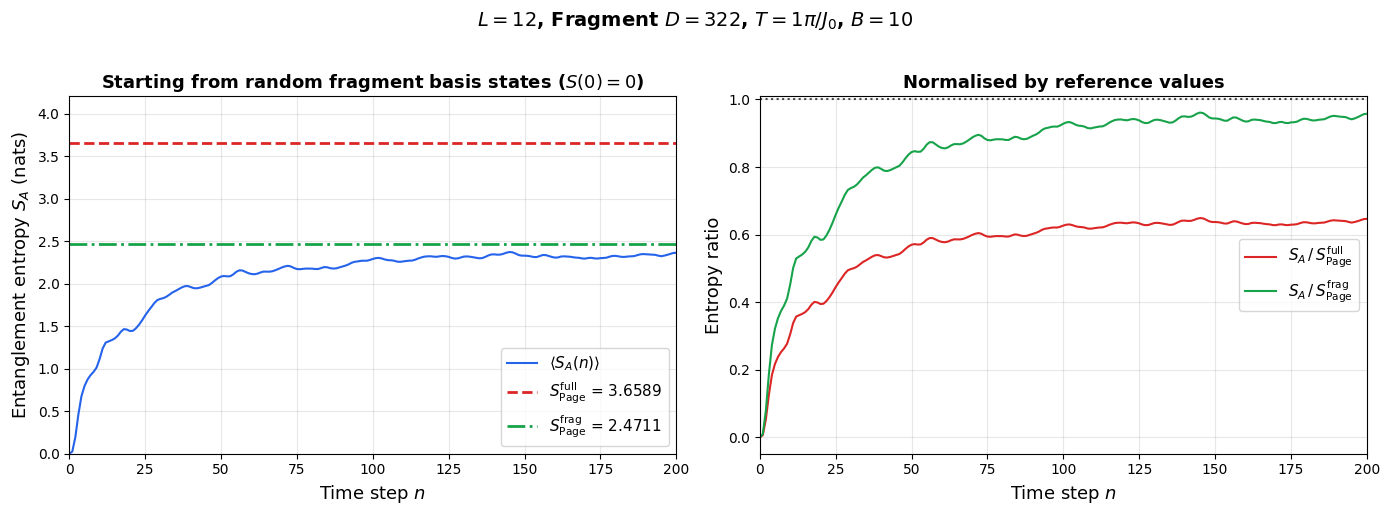


FINAL SUMMARY

  System: L = 12
  J₀ = 10.0, h₀ = 20.0, g = 1.0
  Initial states: 10 random basis states from fragment
  Fragment size: D = 322

  Reference values:
    S_Page (full, Ns=4096):  3.658883 nats
    S_Page (frag, D=322): 2.471124 nats

  Entropy evolution:
    S(n=0)   = 0.000000 nats (should be ~0)
    S(n=200)  = 2.366073 nats

  Final ratios:
    S / S_Page^full = 0.6467
    S / S_Page^frag = 0.9575


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'
matplotlib.rcParams['font.family'] = 'DejaVu Sans'


# ============================================================
# PART 11B: PLOTTING — FRAGMENT ENTANGLEMENT DYNAMICS
# ============================================================
#
# Consumes from Part 10: S_page_full, S_page_frag, S_sem_frag
# Consumes from Part 11A: steps_frag, S_avg_frag
# Also reads: D_largest, L_frag, n_random_states, n_periods_frag,
#             largest_fragment, J0_frag_sim, h0_frag_sim,
#             g_frag_sim, n_period_frag
# ============================================================


def plot_fragment_basis_evolution(steps, S_avg, S_page_full, S_page_frag,
                                  D_frag, L, n_states=None,
                                  J0=None, h0=None, g=None, n_period=None):
    """
    Plot entanglement dynamics from random fragment basis states.

    Parameters
    ----------
    steps : ndarray
        Floquet step indices.
    S_avg : ndarray
        Averaged entanglement entropy at each step.
    S_page_full : float
        Page value for full Hilbert space.
    S_page_frag : float
        Page value for fragment subspace (MC).
    D_frag : int
        Fragment dimension.
    L : int
        System size.
    n_states : int, optional
        Number of initial states averaged.
    J0, h0, g : float, optional
        Hamiltonian parameters for annotation.
    n_period : int, optional
        Integer n in T = n·π/J₀.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Left: Entropy vs time step ----
    ax1.plot(steps, S_avg, '-', lw=1.5, color='#2563eb',
             label=r'$\langle S_A(n) \rangle$')
    ax1.axhline(S_page_full, color='#dc2626', ls='--', lw=2,
                label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{full}}}}$ = {S_page_full:.4f}')
    ax1.axhline(S_page_frag, color='#16a34a', ls='-.', lw=2,
                label=f'$S_{{\\mathrm{{Page}}}}^{{\\mathrm{{frag}}}}$ = {S_page_frag:.4f}')

    ax1.set_xlabel('Time step $n$', fontsize=13)
    ax1.set_ylabel('Entanglement entropy $S_A$ (nats)', fontsize=13)
    ax1.set_title('Starting from random fragment basis states ($S(0)=0$)',
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(steps[0], steps[-1])
    ax1.set_ylim(0, S_page_full * 1.15)

    # ---- Right: Ratio to Page values ----
    ax2.plot(steps, S_avg / S_page_full, '-', lw=1.5, color='#dc2626',
             label=r'$S_A \,/\, S_{\mathrm{Page}}^{\mathrm{full}}$')
    ax2.plot(steps, S_avg / S_page_frag, '-', lw=1.5, color='#16a34a',
             label=r'$S_A \,/\, S_{\mathrm{Page}}^{\mathrm{frag}}$')
    ax2.axhline(1.0, color='black', ls=':', lw=1.5, alpha=0.7)

    ax2.set_xlabel('Time step $n$', fontsize=13)
    ax2.set_ylabel('Entropy ratio', fontsize=13)
    ax2.set_title('Normalised by reference values', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11, loc='right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(steps[0], steps[-1])

    # ---- Suptitle ----
    parts = [f'$L = {L}$', f'Fragment $D = {D_frag}$']
    if n_period is not None and J0 is not None:
        parts.append(f'$T = {n_period}\\pi/J_0$')
    if n_states is not None:
        parts.append(f'$B = {n_states}$')
    fig.suptitle(', '.join(parts), fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

    # ---- Text summary ----
    print("\n" + "=" * 60)
    print("FINAL SUMMARY")
    print("=" * 60)
    print(f"\n  System: L = {L}")
    if J0 is not None:
        print(f"  J₀ = {J0}, h₀ = {h0}, g = {g}")
    if n_states is not None:
        print(f"  Initial states: {n_states} random basis states from fragment")
    print(f"  Fragment size: D = {D_frag}")

    print(f"\n  Reference values:")
    Ns_disp = 2**L
    print(f"    S_Page (full, Ns={Ns_disp}):  {S_page_full:.6f} nats")
    print(f"    S_Page (frag, D={D_frag}): {S_page_frag:.6f} nats")

    print(f"\n  Entropy evolution:")
    print(f"    S(n=0)   = {S_avg[0]:.6f} nats (should be ~0)")
    print(f"    S(n={len(steps)-1})  = {S_avg[-1]:.6f} nats")

    print(f"\n  Final ratios:")
    print(f"    S / S_Page^full = {S_avg[-1] / S_page_full:.4f}")
    print(f"    S / S_Page^frag = {S_avg[-1] / S_page_frag:.4f}")
    print("=" * 60)


# ============================================================
# EXECUTE PLOT (uses variables from Parts 10 + 11A)
# ============================================================

print("=" * 60)
print("PLOTTING FRAGMENT DYNAMICS")
print("=" * 60)

plot_fragment_basis_evolution(
    steps_frag, S_avg_frag,
    S_page_full, S_page_frag,
    D_largest, L_frag,
    n_states=n_random_states,
    J0=J0_frag_sim, h0=h0_frag_sim, g=g_frag_sim,
    n_period=n_period_frag
)

## EE vs $J_0$

### Results code

In [ ]:
import numpy as np
import time


# ============================================================
# PART 12: COMPARISON OF ENTANGLEMENT DYNAMICS FOR DIFFERENT J₀
# ============================================================
#
# Prerequisites:
#   Prompts 1-4 : FloquetIsingChain, apply_floquet_step,
#                 bipartite_entropy, compute_page_value
#   Part 8      : build_O_operator
#   Part 9      : build_connectivity_graph, find_connected_components,
#                 find_largest_fragment
#   Part 10     : compute_fragment_page_value_MC
#   Fragment dynamics : build_fragment_states_batched,
#                       compute_entanglement_dynamics_fragment_basis
#
# Produces: results_list (list of dicts, one per J₀)
# ============================================================


def run_fragment_analysis_for_J0(L, J_0, g, n_periods, n_initial_states,
                                  n_MC_samples=500, seed=42, verbose=False):
    """
    Run complete fragment analysis for a given J₀ value.

    Builds the Floquet system, identifies fragments, computes
    fragment Page value via MC, and evolves entanglement dynamics
    from random basis states in the largest fragment.

    All evolution uses batched Krylov — no dense U_F is formed.

    Parameters
    ----------
    L : int
        Chain length.
    J_0 : float
        Ising coupling strength.
    g : float
        Transverse field (perturbation).
    n_periods : int
        Number of Floquet periods.
    n_initial_states : int
        Number of initial states to average (B).
    n_MC_samples : int
        Monte Carlo samples for fragment Page value.
    seed : int
        RNG seed for reproducibility (MC + initial states).
    verbose : bool
        Print detailed output.

    Returns
    -------
    results : dict
        Dictionary with keys: J_0, h_0, T, steps, S_avg,
        S_page_full, S_page_frag, D_largest, wall_time.
    """
    h_0 = 2.0 * J_0
    T = np.pi / J_0   # fragmentation condition

    if verbose:
        print(f"\n{'=' * 60}")
        print(f"J₀ = {J_0}, h₀ = {h_0}, T = π/{J_0}")
        print(f"{'=' * 60}")

    t0 = time.perf_counter()

    # --- Step 1: Fragment identification ---
    O_diag_local = build_O_operator(L, J_0)
    adjacency_local, num_edges = build_connectivity_graph(L, O_diag_local, tol=1e-10)
    components_local = find_connected_components(adjacency_local)
    largest_frag = find_largest_fragment(components_local)
    D = len(largest_frag)

    if verbose:
        print(f"  Fragments: {len(components_local)}, largest D = {D}")

    # --- Step 2: Build Floquet system (sparse, no dense U_F) ---
    ising_local = FloquetIsingChain(L=L, J_0=J_0, h_0=h_0, g=g, TP=T, hbar=1.0)
    ising_local.build_hamiltonians()

    # --- Step 3: Page values ---
    S_page_full = compute_page_value(L)
    S_page_frag, _, _ = compute_fragment_page_value_MC(
        largest_frag, L, n_samples=n_MC_samples,
        seed=seed, verbose=False
    )

    if verbose:
        print(f"  S_Page (full): {S_page_full:.4f}")
        print(f"  S_Page (frag): {S_page_frag:.4f}")

    # --- Step 4: Batched Krylov evolution ---
    steps, S_avg = compute_entanglement_dynamics_fragment_basis(
        ising_local, largest_frag, n_periods,
        n_initial_states=n_initial_states,
        seed=seed, verbose=False, renorm_interval=100
    )

    wall = time.perf_counter() - t0

    if verbose:
        print(f"  Final entropy: S = {S_avg[-1]:.4f}")
        print(f"  S / S_Page^full = {S_avg[-1] / S_page_full:.4f}")
        print(f"  S / S_Page^frag = {S_avg[-1] / S_page_frag:.4f}")
        print(f"  Wall time: {wall:.1f} s")

    return {
        'J_0': J_0,
        'h_0': h_0,
        'T': T,
        'steps': steps,
        'S_avg': S_avg,
        'S_page_full': S_page_full,
        'S_page_frag': S_page_frag,
        'D_largest': D,
        'wall_time': wall,
    }


# ============================================================
#  CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

L_compare              = 12
g_compare              = 1.0
n_periods_compare      = 200
n_initial_states_compare = 10
n_MC_compare           = 500       # MC samples per J₀ for fragment Page
seed_compare           = 42

J_0_values = [1, 3, 4, 10, 20]

# ============================================================
# EXECUTE COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("PART 12: Comparing Entanglement Dynamics for Different J₀ Values")
print("=" * 70)

print(f"\n  L = {L_compare}")
print(f"  g = {g_compare}")
print(f"  h₀ = 2·J₀")
print(f"  T  = π/J₀ (fragmentation condition)")
print(f"  Floquet periods: {n_periods_compare}")
print(f"  Initial states:  {n_initial_states_compare}")
print(f"  MC samples:      {n_MC_compare}")
print(f"  seed:            {seed_compare}")
print(f"  J₀ values:       {J_0_values}")

results_list = []
t0_total = time.perf_counter()

for J_0 in J_0_values:
    print(f"\n--- Processing J₀ = {J_0} ---")
    result = run_fragment_analysis_for_J0(
        L=L_compare, J_0=J_0, g=g_compare,
        n_periods=n_periods_compare,
        n_initial_states=n_initial_states_compare,
        n_MC_samples=n_MC_compare,
        seed=seed_compare,
        verbose=True
    )
    results_list.append(result)

t_total = time.perf_counter() - t0_total

# ============================================================
# SUMMARY TABLE
# ============================================================

print("\n" + "=" * 90)
print("COMPARISON SUMMARY")
print("=" * 90)
print(f"{'J₀':<8} {'h₀':<8} {'T':<12} {'D':<8} "
      f"{'S_final':<10} {'S/S_Page':<10} {'S/S_frag':<10} {'Time(s)':<8}")
print("-" * 90)

for r in results_list:
    print(f"{r['J_0']:<8.1f} {r['h_0']:<8.1f} {r['T']:<12.6f} {r['D_largest']:<8} "
          f"{r['S_avg'][-1]:<10.4f} {r['S_avg'][-1]/r['S_page_full']:<10.4f} "
          f"{r['S_avg'][-1]/r['S_page_frag']:<10.4f} {r['wall_time']:<8.1f}")

print("=" * 90)
print(f"Total wall time: {t_total:.1f} s")
print("\nData available: results_list")
print("Run the plotting cell (Part 12B) to visualise.")


PART 12: Comparing Entanglement Dynamics for Different J₀ Values

  L = 12
  g = 1.0
  h₀ = 2·J₀
  T  = π/J₀ (fragmentation condition)
  Floquet periods: 200
  Initial states:  10
  MC samples:      500
  seed:            42
  J₀ values:       [1, 3, 4, 10, 20]

--- Processing J₀ = 1 ---

J₀ = 1, h₀ = 2.0, T = π/1
  Fragments: 853, largest D = 322
System Parameters (PERIODIC BC):
  Chain length L = 12
  J_0 = 1
  h_0 = 2.0
  g = 1.0
  Period T = 3.141593
  Hilbert space dimension = 4096

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (4096, 4096), nnz = 53248
  Number of ZZ bonds: 12 (including wrap-around)
  Density: 3.17e-03
  Memory per H matrix: ~0.84 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 75.40, ||A-||_1 = 75.40
  Krylov sub-steps: K+ = 16, K- = 16
  Hermiticity check (H+): max err = 1.49e-12
  Hermiticity check (H-): max err = 1.93e-12
  S_Page (full): 3.6589
  S_Page (frag): 2.4717
  Final entropy: S = 3.6520
  S / S_Page^full = 

### Plotting code


Plotting comparison...


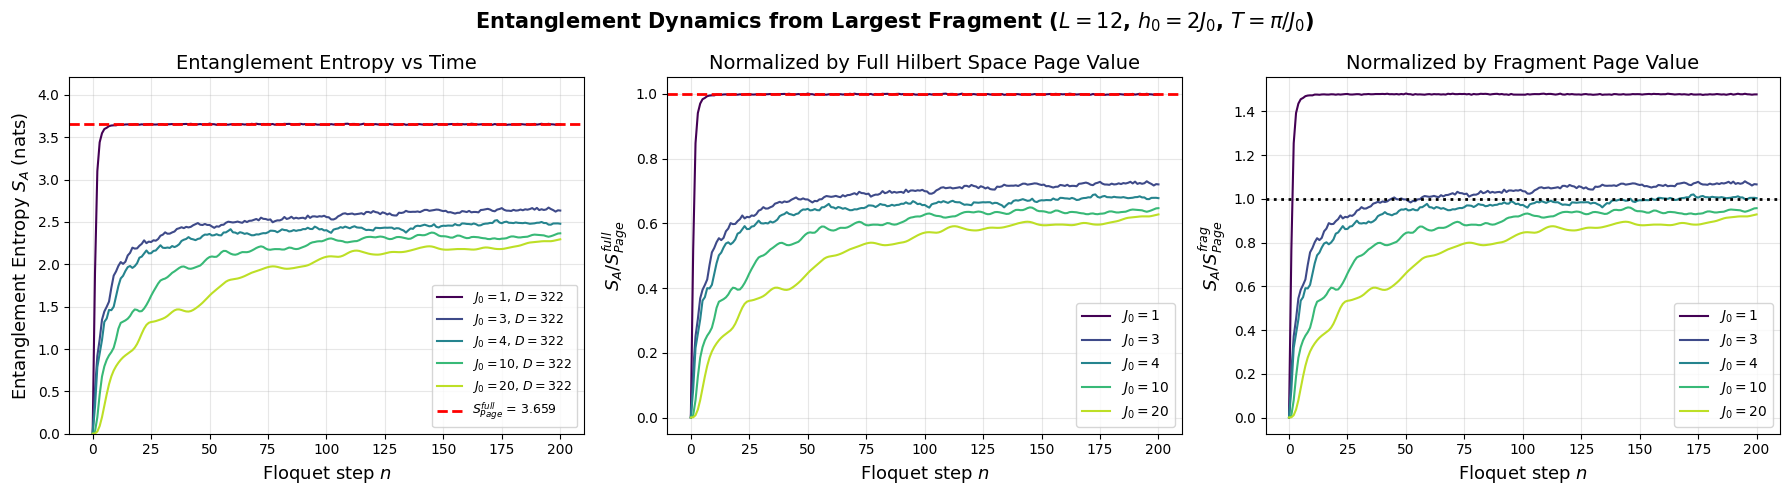


SUMMARY TABLE
J_0      h_0      T            D_frag     S_page^frag  S_final      S/S_Page^full  S/S_Page^frag 
--------------------------------------------------------------------------------
1        2.0      3.141593     322        2.4717       3.6520       0.9981         1.4775        
3        6.0      1.047198     322        2.4717       2.6348       0.7201         1.0660        
4        8.0      0.785398     322        2.4717       2.4793       0.6776         1.0031        
10       20.0     0.314159     322        2.4717       2.3661       0.6467         0.9573        
20       40.0     0.157080     322        2.4717       2.2955       0.6274         0.9287        

✓ Comparison complete!


In [ ]:
def plot_comparison_J0_values(results_list, L):
    """
    Plot entanglement dynamics for different J_0 values.

    Parameters:
    -----------
    results_list : list of dict
        Results from run_fragment_analysis_for_J0 for each J_0
    L : int
        Chain length
    """
    # Color map for different J_0 values
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(results_list)))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Get the full Page value (same for all J_0)
    S_page_full = results_list[0]['S_page_full']

    # ========== Left plot: Entropy S(n) ==========
    ax1 = axes[0]
    for i, res in enumerate(results_list):
        label = f"$J_0 = {res['J_0']}$, $D = {res['D_largest']}$"
        ax1.plot(res['steps'], res['S_avg'], color=colors[i], linewidth=1.5, label=label)

    ax1.axhline(S_page_full, color='red', linestyle='--', linewidth=2,
                label=f'$S_{{Page}}^{{full}}$ = {S_page_full:.3f}')

    ax1.set_xlabel('Floquet step $n$', fontsize=13)
    ax1.set_ylabel('Entanglement Entropy $S_A$ (nats)', fontsize=13)
    ax1.set_title('Entanglement Entropy vs Time', fontsize=14)
    ax1.legend(fontsize=9, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, S_page_full * 1.15)

    # ========== Middle plot: Ratio to full Page value ==========
    ax2 = axes[1]
    for i, res in enumerate(results_list):
        label = f"$J_0 = {res['J_0']}$"
        ax2.plot(res['steps'], res['S_avg'] / S_page_full, color=colors[i],
                 linewidth=1.5, label=label)

    ax2.axhline(1.0, color='red', linestyle='--', linewidth=2)

    ax2.set_xlabel('Floquet step $n$', fontsize=13)
    ax2.set_ylabel(r'$S_A / S_{Page}^{full}$', fontsize=13)
    ax2.set_title('Normalized by Full Hilbert Space Page Value', fontsize=14)
    ax2.legend(fontsize=10, loc='lower right')
    ax2.grid(True, alpha=0.3)

    # ========== Right plot: Ratio to fragment Page value ==========
    ax3 = axes[2]
    for i, res in enumerate(results_list):
        label = f"$J_0 = {res['J_0']}$"
        ax3.plot(res['steps'], res['S_avg'] / res['S_page_frag'], color=colors[i],
                 linewidth=1.5, label=label)

    ax3.axhline(1.0, color='black', linestyle=':', linewidth=2)

    ax3.set_xlabel('Floquet step $n$', fontsize=13)
    ax3.set_ylabel(r'$S_A / S_{Page}^{frag}$', fontsize=13)
    ax3.set_title('Normalized by Fragment Page Value', fontsize=14)
    ax3.legend(fontsize=10, loc='lower right')
    ax3.grid(True, alpha=0.3)

    fig.suptitle(f'Entanglement Dynamics from Largest Fragment ($L = {L}$, $h_0 = 2J_0$, $T = \\pi/J_0$)',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\n" + "="*80)
    print("SUMMARY TABLE")
    print("="*80)
    print(f"{'J_0':<8} {'h_0':<8} {'T':<12} {'D_frag':<10} {'S_page^frag':<12} {'S_final':<12} {'S/S_Page^full':<14} {'S/S_Page^frag':<14}")
    print("-"*80)
    for res in results_list:
        print(f"{res['J_0']:<8} {res['h_0']:<8} {res['T']:<12.6f} {res['D_largest']:<10} "
              f"{res['S_page_frag']:<12.4f} {res['S_avg'][-1]:<12.4f} "
              f"{res['S_avg'][-1]/S_page_full:<14.4f} {res['S_avg'][-1]/res['S_page_frag']:<14.4f}")
    print("="*80)



# Plot comparison
print("\n" + "="*70)
print("Plotting comparison...")
print("="*70)

plot_comparison_J0_values(results_list, L_compare)

print("\n✓ Comparison complete!")

## EE vs fragments

### Results code

In [ ]:
import numpy as np
import time


# ============================================================
# PART 12: ENTANGLEMENT DYNAMICS FOR LARGEST DISTINCT-D FRAGMENTS
# ============================================================
#
# Prerequisites:
#   Prompts 1-4 : FloquetIsingChain, apply_floquet_step,
#                 bipartite_entropy, compute_page_value
#   Part 8      : build_O_operator
#   Part 9      : build_connectivity_graph, find_connected_components
#   Fragment dynamics : build_fragment_states_batched
#
# Produces: fragment_results (list of dicts, one per fragment)
# ============================================================


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

L_p12           = 12
J_0_p12         = 10.0
h_0_p12         = 2.0 * J_0_p12    # = 20
g_p12           = 1.0
n_period_p12    = 1                 # T = n·π/J₀
n_periods_p12   = 200               # Floquet periods
n_samples_p12   = 10                # initial states per fragment
n_top_frags     = 4                 # how many distinct-D fragments
seed_p12        = 42
renorm_p12      = 100

# ============================================================
# DERIVED QUANTITIES (do not modify)
# ============================================================

T_p12  = n_period_p12 * np.pi / J_0_p12
Ns_p12 = 2**L_p12

print("=" * 70)
print(f"PART 12: Entanglement Dynamics for {n_top_frags} Largest Distinct-D Fragments")
print("=" * 70)

print(f"\n  System:")
print(f"    L  = {L_p12}  (Ns = {Ns_p12})")
print(f"    J₀ = {J_0_p12},  h₀ = {h_0_p12},  g = {g_p12}")
print(f"    T  = {n_period_p12}·π/J₀ = {T_p12:.6f}")

print(f"\n  Simulation:")
print(f"    n_periods = {n_periods_p12}")
print(f"    B = {n_samples_p12} initial states per fragment")
print(f"    seed = {seed_p12}")

# ============================================================
# BUILD FLOQUET SYSTEM (sparse, no dense U_F)
# ============================================================

print("\n" + "-" * 70)
print("Building Floquet system...")
print("-" * 70)

t0_build = time.perf_counter()

ising_p12 = FloquetIsingChain(
    L=L_p12, J_0=J_0_p12, h_0=h_0_p12, g=g_p12,
    TP=T_p12, hbar=1.0
)
ising_p12.build_hamiltonians()

t_build = time.perf_counter() - t0_build
print(f"  Build time: {t_build:.3f} s")

# ============================================================
# FRAGMENT IDENTIFICATION
# ============================================================

print("\n" + "-" * 70)
print("Identifying fragments...")
print("-" * 70)

O_diag_p12 = build_O_operator(L_p12, J_0_p12)
adjacency_p12, num_edges_p12 = build_connectivity_graph(L_p12, O_diag_p12)
components_p12 = find_connected_components(adjacency_p12)

components_sorted = sorted(components_p12, key=len, reverse=True)

# --- Select fragments with DISTINCT dimensions ---
# Walk the size-sorted list; skip any fragment whose D already appeared.
top_fragments = []
seen_D = set()
for frag in components_sorted:
    D = len(frag)
    if D not in seen_D:
        top_fragments.append(frag)
        seen_D.add(D)
    if len(top_fragments) == n_top_frags:
        break

print(f"  Total fragments: {len(components_p12)}")
print(f"  Unique fragment dimensions: "
      f"{sorted(set(len(c) for c in components_p12), reverse=True)}")
print(f"\n  Selected {len(top_fragments)} fragments with distinct D:")
for i, frag in enumerate(top_fragments):
    print(f"    Fragment {i+1}: D = {len(frag)} states")

# ============================================================
# PAGE VALUES
# ============================================================

A_indices_p12 = list(range(L_p12 // 2))
S_page_full_p12 = compute_page_value(L_p12)
print(f"\n  S_Page (full, Ns={Ns_p12}): {S_page_full_p12:.6f} nats")

# ============================================================
# EVOLUTION — BATCHED KRYLOV PER FRAGMENT
# ============================================================

print("\n" + "-" * 70)
print("Running entanglement dynamics per fragment...")
print("-" * 70)

fragment_results = []
t0_total = time.perf_counter()

for i, fragment in enumerate(top_fragments):
    D_frag = len(fragment)
    print(f"\n--- Fragment {i+1} (D = {D_frag}) ---")

    t0_frag = time.perf_counter()

    # Build batched initial states (all B at once)
    rng_frag = np.random.default_rng(seed_p12 + i)
    Psi, chosen = build_fragment_states_batched(
        fragment, L_p12, n_samples_p12, rng_frag
    )

    steps = np.arange(n_periods_p12 + 1)
    S_all = np.zeros((n_samples_p12, n_periods_p12 + 1))

    # Step 0: entropy of initial states (should be 0)
    for k in range(n_samples_p12):
        S_all[k, 0] = bipartite_entropy(Psi[:, k], L_p12, A_indices_p12)

    # Evolution loop
    for n in range(1, n_periods_p12 + 1):
        # Batched Krylov step
        Psi = apply_floquet_step(ising_p12, Psi)

        # Periodic renormalisation
        if renorm_p12 > 0 and n % renorm_p12 == 0:
            norms = np.linalg.norm(Psi, axis=0)
            Psi /= norms[np.newaxis, :]

        # Per-sample entropy
        for k in range(n_samples_p12):
            S_all[k, n] = bipartite_entropy(Psi[:, k], L_p12, A_indices_p12)

        # Progress
        if n % max(1, n_periods_p12 // 5) == 0:
            elapsed = time.perf_counter() - t0_frag
            rate = n / elapsed
            eta = (n_periods_p12 - n) / rate if rate > 0 else 0
            print(f"    Step {n:>5d}/{n_periods_p12}: "
                  f"<S> = {np.mean(S_all[:, n]):.4f}, "
                  f"{rate:.1f} steps/s, ETA {eta:.0f}s")

    S_avg = np.mean(S_all, axis=0)
    S_std = np.std(S_all, axis=0, ddof=1)
    t_frag = time.perf_counter() - t0_frag

    fragment_results.append({
        'fragment_id': i + 1,
        'D': D_frag,
        'steps': steps,
        'S_avg': S_avg,
        'S_std': S_std,
        'S_all': S_all,
        'wall_time': t_frag,
    })

    print(f"  S(0) = {S_avg[0]:.2e}, S({n_periods_p12}) = {S_avg[-1]:.4f} "
          f"± {S_std[-1]:.4f}")
    print(f"  S / S_Page^full = {S_avg[-1] / S_page_full_p12:.4f}")
    print(f"  Wall time: {t_frag:.1f} s")

t_total = time.perf_counter() - t0_total

# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"{'Frag':<6} {'D':<8} {'S_final':<10} {'± std':<10} "
      f"{'S/S_Page':<10} {'Time(s)':<8}")
print("-" * 70)

for r in fragment_results:
    print(f"{r['fragment_id']:<6} {r['D']:<8} {r['S_avg'][-1]:<10.4f} "
          f"{r['S_std'][-1]:<10.4f} "
          f"{r['S_avg'][-1] / S_page_full_p12:<10.4f} {r['wall_time']:<8.1f}")

print("=" * 70)
print(f"Total wall time: {t_total:.1f} s")
print(f"\nData available: fragment_results, S_page_full_p12")
print("Run Part 12B plotting cell to visualise.")

PART 12: Entanglement Dynamics for 4 Largest Distinct-D Fragments

  System:
    L  = 12  (Ns = 4096)
    J₀ = 10.0,  h₀ = 20.0,  g = 1.0
    T  = 1·π/J₀ = 0.314159

  Simulation:
    n_periods = 200
    B = 10 initial states per fragment
    seed = 42

----------------------------------------------------------------------
Building Floquet system...
----------------------------------------------------------------------
System Parameters (PERIODIC BC):
  Chain length L = 12
  J_0 = 10.0
  h_0 = 20.0
  g = 1.0
  Period T = 0.314159
  Hilbert space dimension = 4096

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (4096, 4096), nnz = 53248
  Number of ZZ bonds: 12 (including wrap-around)
  Density: 3.17e-03
  Memory per H matrix: ~0.84 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 58.43, ||A-||_1 = 58.43
  Krylov sub-steps: K+ = 12, K- = 12
  Hermiticity check (H+): max err = 2.28e-11
  Hermiticity check (H-): max err = 1.50e-11
  Build time: 0.019 

### Plotting code

PART 12B: Computing fragment Page values + plotting

Computing S_Page^frag via Monte Carlo (5000 samples)...
  Fragment 1 (D= 322): S_Page^frag = 2.470260 ± 0.000391 nats
  Fragment 2 (D=  55): S_Page^frag = 1.392477 ± 0.000770 nats
  Fragment 3 (D=  34): S_Page^frag = 0.971694 ± 0.000824 nats
  Fragment 4 (D=  21): S_Page^frag = 0.604761 ± 0.000906 nats



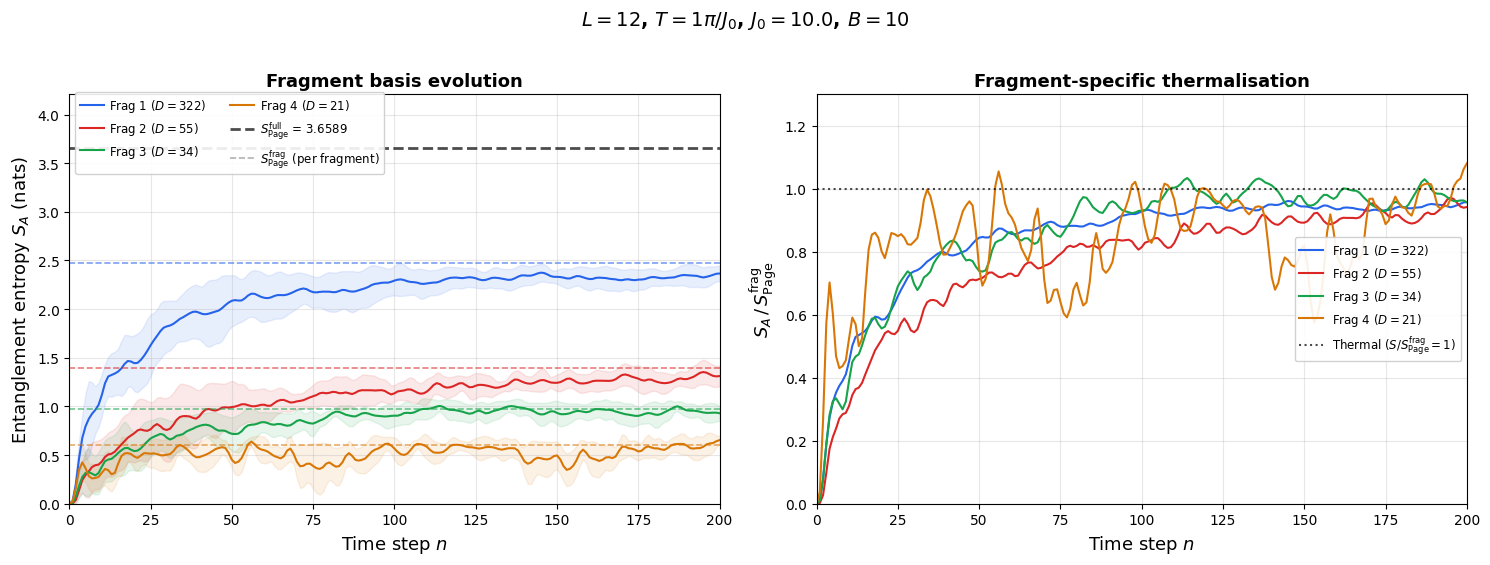

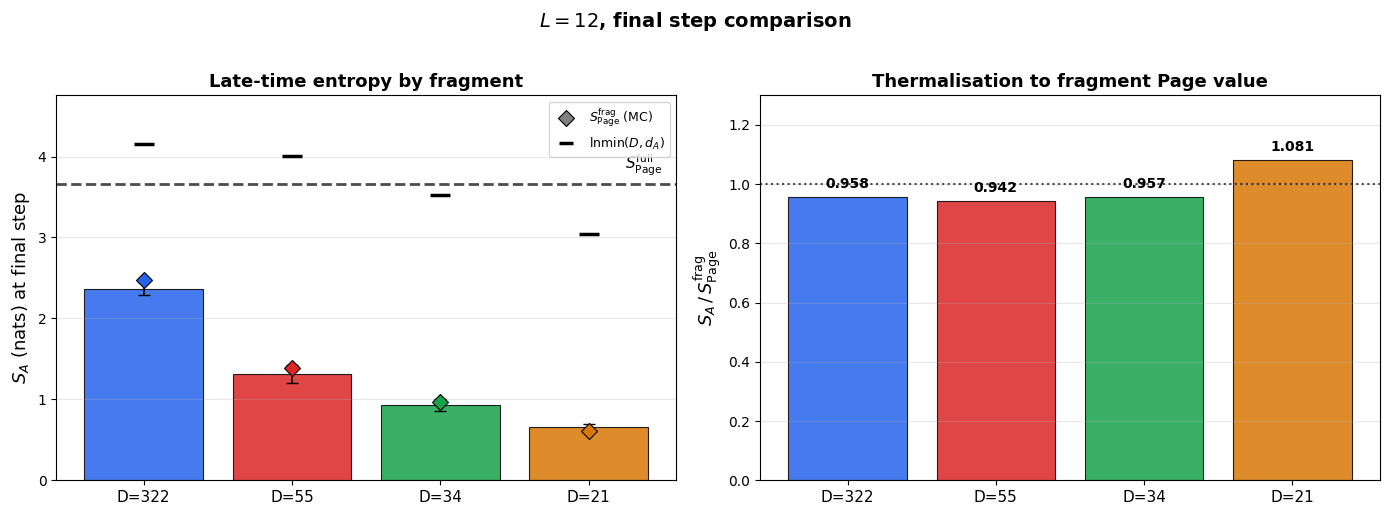


PART 12B — SUMMARY

  System: L = 12, Ns = 4096
  J₀ = 10.0, h₀ = 20.0, g = 1.0
  T = 1·π/J₀ = 0.314159
  B = 10 initial states per fragment

  S_Page^full = 3.658883 nats

  Frag   D        S_final      ± σ          S_Page^f     S/S_Pf     S/S_PF     ln min    
  --------------------------------------------------------------------------------
  1      322      2.366073     0.079612     2.470260     0.9578     0.6467     4.158883  
  2      55       1.312064     0.106902     1.392477     0.9423     0.3586     4.007333  
  3      34       0.929860     0.079568     0.971694     0.9569     0.2541     3.526361  
  4      21       0.653598     0.044030     0.604761     1.0808     0.1786     3.044522  


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'
matplotlib.rcParams['font.family'] = 'DejaVu Sans'


# ============================================================
# PART 12B: PLOTTING — MULTI-FRAGMENT ENTANGLEMENT DYNAMICS
#           (with fragment-specific Page value thermalisation)
# ============================================================
#
# Consumes from Part 12:
#   fragment_results : list of dicts (fragment_id, D, steps,
#                      S_avg, S_std, S_all, wall_time)
#   top_fragments    : list of lists (basis state indices)
#   S_page_full_p12  : float (full Hilbert space Page value)
#   L_p12, J_0_p12, h_0_p12, g_p12, n_period_p12, n_samples_p12
#
# Consumes from Part 10:
#   compute_fragment_page_value_MC  (function)
# ============================================================

# Colour palette — distinct, colourblind-friendly
FRAG_COLORS = ['#2563eb', '#dc2626', '#16a34a', '#d97706', '#7c3aed']
FRAG_MARKERS = ['o', 's', '^', 'D', 'v']


def plot_multi_fragment_dynamics(fragment_results, S_page_full, L,
                                 J0=None, h0=None, g=None, n_period=None,
                                 n_states=None):
    """
    Plot entanglement dynamics for multiple Hilbert space fragments,
    showing thermalisation against both S_Page^full and S_Page^frag.

    Figure 1 — Two panels:
      Left : S_A(n) vs n with per-fragment S_Page^frag dashed lines
      Right: S_A / S_Page^frag ratio (fragment-specific thermalisation)

    Figure 2 — Two panels:
      Left : Bar chart of late-time S_A with S_Page^frag diamonds
      Right: Bar chart of S / S_Page^frag ratio
    """
    n_frags = len(fragment_results)
    colors = FRAG_COLORS[:n_frags]
    markers = FRAG_MARKERS[:n_frags]
    d_A = 2**(L // 2)

    # ================================================================
    # FIGURE 1: Time-evolution panels
    # ================================================================
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

    # First pass: plot data without legend
    legend_elements = []
    for i, r in enumerate(fragment_results):
        S_pf = r['S_page_frag']
        label = f'Frag {r["fragment_id"]} ($D = {r["D"]}$)'

        # ---- Left: Entropy S(n) ----
        line1 = ax1.plot(r['steps'], r['S_avg'], '-', lw=1.5, color=colors[i],
                         label=label)[0]  # Get the line object
        ax1.fill_between(r['steps'],
                         r['S_avg'] - r['S_std'],
                         r['S_avg'] + r['S_std'],
                         color=colors[i], alpha=0.10)
        # Per-fragment Page value (coloured dashed)
        if S_pf > 1e-10:
            ax1.axhline(S_pf, color=colors[i], ls='--', lw=1.2, alpha=0.6)

        # ---- Right: Ratio to fragment Page ----
        if S_pf > 1e-10:
            ax2.plot(r['steps'], r['S_avg'] / S_pf, '-', lw=1.5,
                     color=colors[i], label=label)

        # Store legend element for fragment line
        legend_elements.append(line1)

    # Full-space Page reference + legend entry for fragment dashes
    full_page_line = ax1.axhline(
        S_page_full, color='black', ls='--', lw=2, alpha=0.7,
        label=rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{full}}}}$ = {S_page_full:.4f}')
    frag_dash_line = ax1.plot(
        [], [], '--', color='gray', lw=1.2, alpha=0.6,
        label=r'$S_{\mathrm{Page}}^{\mathrm{frag}}$ (per fragment)')[0]
    legend_elements.extend([full_page_line, frag_dash_line])

    ax1.set_xlabel('Time step $n$', fontsize=13)
    ax1.set_ylabel('Entanglement entropy $S_A$ (nats)', fontsize=13)
    ax1.set_title('Fragment basis evolution', fontsize=13, fontweight='bold')
    # Legend: pass (handles, labels) as TWO arguments
    leg_labels = [h.get_label() for h in legend_elements]
    ax1.legend(legend_elements, leg_labels, fontsize=8.5, loc='upper left',
               ncol=2, framealpha=0.9, bbox_to_anchor=(0, 1.02),
               handlelength=2, handletextpad=0.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, fragment_results[0]['steps'][-1])
    ax1.set_ylim(0, S_page_full * 1.15)

    # Right: ratio to fragment Page
    ax2.axhline(1.0, color='black', ls=':', lw=1.5, alpha=0.7,
                label=r'Thermal ($S/S_{\mathrm{Page}}^{\mathrm{frag}} = 1$)')
    ax2.set_xlabel('Time step $n$', fontsize=13)
    ax2.set_ylabel(
        r'$S_A \,/\, S_{\mathrm{Page}}^{\mathrm{frag}}$', fontsize=13)
    ax2.set_title('Fragment-specific thermalisation', fontsize=13,
                  fontweight='bold')
    ax2.legend(fontsize=8.5, loc='right', ncol=1, framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, fragment_results[0]['steps'][-1])
    ax2.set_ylim(0, 1.3)

    # Suptitle
    parts = [f'$L = {L}$']
    if n_period is not None and J0 is not None:
        parts.append(rf'$T = {n_period}\pi/J_0$')
    if J0 is not None:
        parts.append(f'$J_0 = {J0}$')
    if n_states is not None:
        parts.append(f'$B = {n_states}$')
    fig1.suptitle(', '.join(parts), fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()
    # ================================================================
    # FIGURE 2: Bar chart — final entropy vs fragment dimension
    # ================================================================
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

    D_vals = [r['D'] for r in fragment_results]
    S_final = [r['S_avg'][-1] for r in fragment_results]
    S_final_std = [r['S_std'][-1] for r in fragment_results]
    S_pf_vals = [r['S_page_frag'] for r in fragment_results]
    S_ratio_frag = [s / spf if spf > 1e-10 else 0.0
                    for s, spf in zip(S_final, S_pf_vals)]

    x_pos = np.arange(n_frags)
    bar_labels = [f'D={d}' for d in D_vals]

    # Left: absolute entropy bars
    bars1 = ax3.bar(x_pos, S_final, yerr=S_final_std,
                    color=colors, alpha=0.85, edgecolor='black', lw=0.8,
                    capsize=4, error_kw={'lw': 1.2})
    ax3.axhline(S_page_full, color='black', ls='--', lw=2, alpha=0.7)
    ax3.text(n_frags - 0.5, S_page_full * 1.02,
             rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{full}}}}$',
             fontsize=11, ha='right', va='bottom')

    # Per-fragment S_Page^frag (diamond markers)
    for i, spf in enumerate(S_pf_vals):
        if spf > 1e-10:
            ax3.plot(i, spf, 'D', ms=8, color=colors[i],
                     markeredgecolor='black', markeredgewidth=0.8, zorder=5)
    ax3.plot([], [], 'D', ms=8, color='gray', markeredgecolor='black',
             markeredgewidth=0.8,
             label=r'$S_{\mathrm{Page}}^{\mathrm{frag}}$ (MC)')

    # ln(min(D, d_A)) upper bounds
    Ns = 2**L
    for i, d in enumerate(D_vals):
        S_max_frag = np.log(min(d, d_A))
        ax3.plot(i, S_max_frag, 'k_', ms=14, mew=2.5)

    ax3.plot([], [], 'k_', ms=10, mew=2.5, label=r'$\ln\!\min(D, d_A)$')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(bar_labels, fontsize=11)
    ax3.set_ylabel('$S_A$ (nats) at final step', fontsize=13)
    ax3.set_title('Late-time entropy by fragment', fontsize=13,
                  fontweight='bold')
    ax3.legend(fontsize=9, loc='upper right')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_ylim(0, S_page_full * 1.3)

    # Right: thermalisation ratio to fragment Page
    bars2 = ax4.bar(x_pos, S_ratio_frag, color=colors, alpha=0.85,
                    edgecolor='black', lw=0.8)
    ax4.axhline(1.0, color='black', ls=':', lw=1.5, alpha=0.7)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(bar_labels, fontsize=11)
    ax4.set_ylabel(
        r'$S_A \,/\, S_{\mathrm{Page}}^{\mathrm{frag}}$', fontsize=13)
    ax4.set_title('Thermalisation to fragment Page value', fontsize=13,
                  fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_ylim(0, 1.3)

    # Annotate ratios on bars
    for j, (bar, ratio) in enumerate(zip(bars2, S_ratio_frag)):
        ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{ratio:.3f}', ha='center', va='bottom', fontsize=10,
                 fontweight='bold')

    fig2.suptitle(f'$L = {L}$, final step comparison', fontsize=14,
                  fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

    # ================================================================
    # TEXT SUMMARY
    # ================================================================
    print("\n" + "=" * 70)
    print("PART 12B — SUMMARY")
    print("=" * 70)
    print(f"\n  System: L = {L}, Ns = {2**L}")
    if J0 is not None:
        print(f"  J₀ = {J0}, h₀ = {h0}, g = {g}")
    if n_period is not None and J0 is not None:
        T_val = n_period * np.pi / J0
        print(f"  T = {n_period}·π/J₀ = {T_val:.6f}")
    if n_states is not None:
        print(f"  B = {n_states} initial states per fragment")

    print(f"\n  S_Page^full = {S_page_full:.6f} nats")

    print(f"\n  {'Frag':<6} {'D':<8} {'S_final':<12} {'± σ':<12} "
          f"{'S_Page^f':<12} {'S/S_Pf':<10} {'S/S_PF':<10} "
          f"{'ln min':<10}")
    print("  " + "-" * 80)
    for r in fragment_results:
        S_bound = np.log(min(r['D'], d_A))
        S_f = r['S_avg'][-1]
        S_pf = r['S_page_frag']
        r_frag = S_f / S_pf if S_pf > 1e-10 else float('nan')
        r_full = S_f / S_page_full
        print(f"  {r['fragment_id']:<6} {r['D']:<8} "
              f"{S_f:<12.6f} {r['S_std'][-1]:<12.6f} "
              f"{S_pf:<12.6f} {r_frag:<10.4f} {r_full:<10.4f} "
              f"{S_bound:<10.6f}")
    print("=" * 70)


# ============================================================
#   CONFIGURABLE PARAMETERS — MODIFY HERE
# ============================================================

n_MC_page_12b   = 5000     # MC samples for fragment Page value
seed_MC_12b     = 1042     # RNG seed for MC Page values

# ============================================================
# COMPUTE S_PAGE^FRAG PER FRAGMENT, THEN PLOT
# ============================================================

print("=" * 70)
print("PART 12B: Computing fragment Page values + plotting")
print("=" * 70)

print(f"\nComputing S_Page^frag via Monte Carlo ({n_MC_page_12b} samples)...")

for i, r in enumerate(fragment_results):
    S_pf, _, S_pf_sem = compute_fragment_page_value_MC(
        top_fragments[i], L_p12,
        n_samples=n_MC_page_12b,
        A_indices=list(range(L_p12 // 2)),
        seed=seed_MC_12b + i,
        verbose=False
    )
    r['S_page_frag'] = S_pf
    r['S_page_frag_sem'] = S_pf_sem
    print(f"  Fragment {r['fragment_id']} (D={r['D']:>4}): "
          f"S_Page^frag = {S_pf:.6f} ± {S_pf_sem:.6f} nats")

print()
plot_multi_fragment_dynamics(
    fragment_results, S_page_full_p12, L_p12,
    J0=J_0_p12, h0=h_0_p12, g=g_p12, n_period=n_period_p12,
    n_states=n_samples_p12
)

# Entanglement entropy with Quasi-energy

ETH DIAGNOSTIC: S_A vs quasienergy in largest fragment
L=12, J0=10.0, h0=20.0, g=1, T=0.314159
Ns = 4096

Fragment identification:
  Total fragments: 853
  Largest fragment dimension: D = 322
  Fibonacci check: F_11+F_13 = 322, MATCH
System Parameters (PERIODIC BC):
  Chain length L = 12
  J_0 = 10.0
  h_0 = 20.0
  g = 1
  Period T = 0.314159
  Hilbert space dimension = 4096

Hamiltonians constructed successfully (PERIODIC BC)!
  H+ shape: (4096, 4096), nnz = 53248
  Number of ZZ bonds: 12 (including wrap-around)
  Density: 3.17e-03
  Memory per H matrix: ~0.84 MB
  A_plus dtype: complex128  (Krylov generator cached)
  ||A+||_1 = 58.43, ||A-||_1 = 58.43
  Krylov sub-steps: K+ = 12, K- = 12
  Hermiticity check (H+): max err = 2.28e-11
  Hermiticity check (H-): max err = 1.50e-11

Building fragment operator via batched Krylov...
  Embedding matrix: 4096 × 322 = 21.1 MB
  Built 322×322 fragment operator in 56.31s
  Unitarity: ||U†U - I|| = 5.18e-04
  Avg leakage per basis state: 2.20e-05


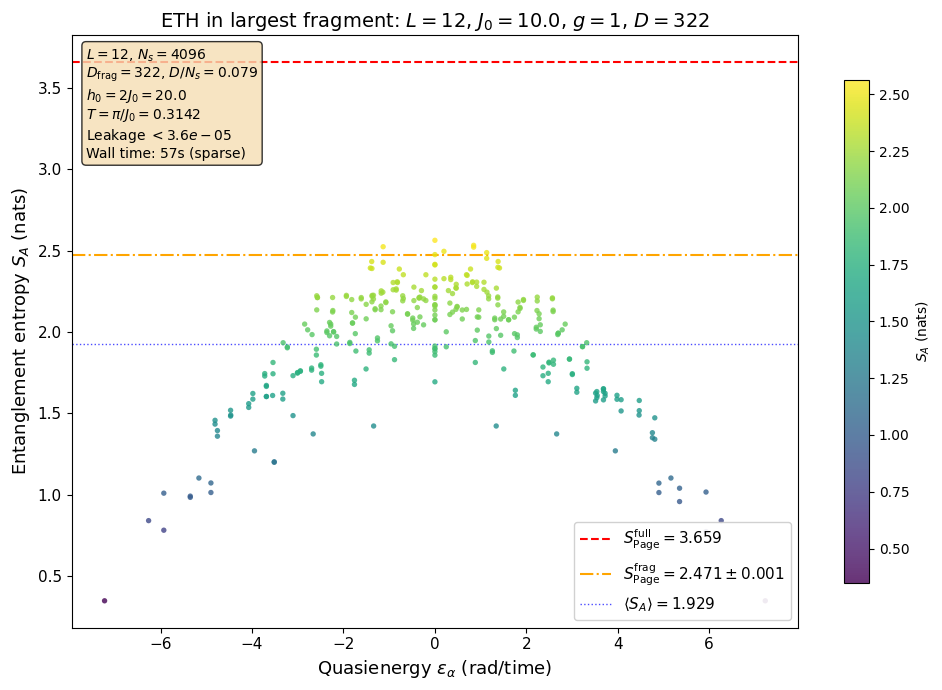

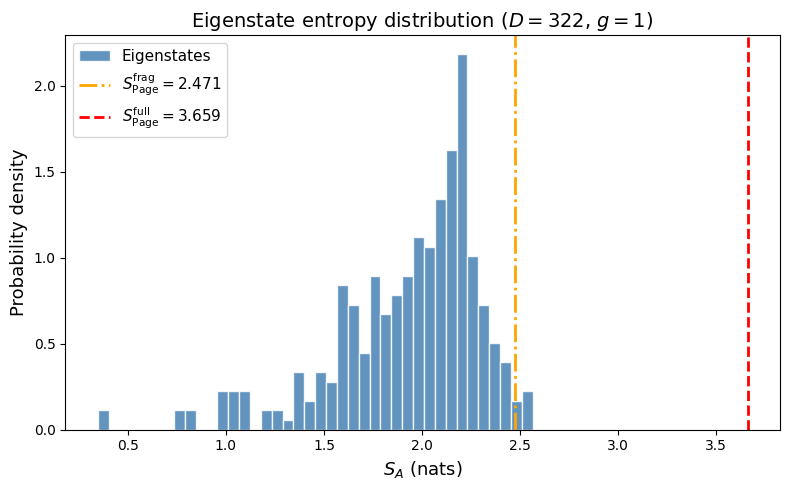

In [ ]:
"""
Entanglement entropy S_A vs. quasienergy epsilon for Floquet eigenstates
in the largest Hilbert space fragment.

ETH diagnostic: in a thermalising fragment, S_A(epsilon) should cluster
near the fragment Page value S_Page^(frag) for mid-spectrum states.

*** SPARSE ONLY — no dense U_F ever formed. ***
Strategy: embed fragment identity into full space, apply one batched
Krylov Floquet step, project back → D×D fragment operator.
Cost: O(K · nnz · D) instead of O(Ns³).

Tunable parameters are collected at the top.
Reuses: snippets/ modules (hamiltonian, evolution, fragment_ops, entropy).
"""

import numpy as np
import time
import matplotlib.pyplot as plt

# ============================================================
# TUNABLE PARAMETERS
# ============================================================
L        = 12       # System size (chain length). L <= 16 feasible.
J0       = 10.0      # Ising coupling strength
h0       = 2.0 * J0 # Longitudinal field (fragmentation: h0 = 2*J0)
g        = 1      # Transverse field (perturbation). g=0 => exact fragments.
n_period = 1        # T = n_period * pi / J0 (fragmentation condition)
seed     = 42       # RNG seed for MC Page value estimation
n_MC     = 1000     # MC samples for fragment Page value

# ============================================================
# STEP 1: IDENTIFY FRAGMENTS
# ============================================================
T  = n_period * np.pi / J0
Ns = 1 << L

print(f"{'='*60}")
print(f"ETH DIAGNOSTIC: S_A vs quasienergy in largest fragment")
print(f"L={L}, J0={J0}, h0={h0}, g={g}, T={T:.6f}")
print(f"Ns = {Ns}")
print(f"{'='*60}")

t_wall_start = time.perf_counter()

O_diag = build_O_operator(L, J0)
adj, num_edges = build_connectivity_graph(L, O_diag)
comps = find_connected_components(adj)
largest = np.array(find_largest_fragment(comps))
D = len(largest)
D_fib = fib(L - 1) + fib(L + 1)

print(f"\nFragment identification:")
print(f"  Total fragments: {len(comps)}")
print(f"  Largest fragment dimension: D = {D}")
print(f"  Fibonacci check: F_{L-1}+F_{L+1} = {D_fib}, "
      f"{'MATCH' if D == D_fib else 'MISMATCH'}")

# ============================================================
# STEP 2: BUILD SPARSE FLOQUET SYSTEM
# ============================================================
ising = FloquetIsingChain(L=L, J_0=J0, h_0=h0, g=g, TP=T, hbar=1.0)
ising.build_hamiltonians()

# ============================================================
# STEP 3: BUILD D×D FRAGMENT OPERATOR VIA BATCHED KRYLOV
# ============================================================
# Strategy:
#   1. Build I_frag: Ns × D matrix with (I_frag)_{frag[j], j} = 1
#   2. Apply one Floquet step (batched Krylov): U_F · I_frag → Ns × D
#   3. Project back: extract rows at fragment indices → D × D
#
# This gives U_frag[a,b] = ⟨frag[a]| U_F |frag[b]⟩
# without ever forming the Ns × Ns dense unitary.
#
# Cost: O(K_sub · nnz · D) where K_sub = K+ + K- Krylov sub-steps.
# Memory: O(Ns · D) for the embedding matrix.

print(f"\nBuilding fragment operator via batched Krylov...")
print(f"  Embedding matrix: {Ns} × {D} = {Ns*D*16/1e6:.1f} MB")

t0 = time.perf_counter()

# Embed: D fragment basis vectors into full Hilbert space
I_frag = np.zeros((Ns, D), dtype=np.complex128)
I_frag[largest, np.arange(D)] = 1.0

# Batched Floquet step: expm_multiply handles (Ns, D) natively
# Krylov basis is reused across all D columns → much faster than D serial calls
U_frag_full = apply_floquet_step(ising, I_frag)

# Project back to fragment subspace
U_frag_dense = U_frag_full[largest, :]

t_build = time.perf_counter() - t0
print(f"  Built {D}×{D} fragment operator in {t_build:.2f}s")

# --- Validate ---
unitarity_err = np.linalg.norm(U_frag_dense.conj().T @ U_frag_dense - np.eye(D))
print(f"  Unitarity: ||U†U - I|| = {unitarity_err:.2e}")

# Leakage: total weight escaping fragment across all D basis vectors
total_weight_in_frag = np.sum(np.abs(U_frag_full[largest, :])**2)
total_weight_all     = np.sum(np.abs(U_frag_full)**2)
avg_leakage = 1.0 - total_weight_in_frag / total_weight_all
max_leakage_per_col  = 1.0 - np.sum(np.abs(U_frag_full[largest, :])**2, axis=0).min()
print(f"  Avg leakage per basis state: {avg_leakage:.2e}")
print(f"  Max leakage (worst basis state): {max_leakage_per_col:.2e}")

# Free the large Ns × D matrices
del I_frag, U_frag_full

if unitarity_err > 1e-3:
    print("  WARNING: significant leakage — fragment not well-closed at this g.")

# ============================================================
# STEP 4: DIAGONALISE D×D FRAGMENT OPERATOR
# ============================================================
# D = 322 for L=12 → diagonalising 322×322 is trivial (~0.1s).
# np.linalg.eig is correct here: U_frag is unitary, not Hermitian.

print(f"\nDiagonalising {D}×{D} fragment operator...")
t0 = time.perf_counter()
evals, evecs = np.linalg.eig(U_frag_dense)
t_eig = time.perf_counter() - t0
print(f"  Time: {t_eig:.4f}s")

# Verify eigenvalues on unit circle
radii = np.abs(evals)
print(f"  |eigenvalue| range: [{radii.min():.8f}, {radii.max():.8f}]")

# Quasienergies: U|φ⟩ = e^{-iεT}|φ⟩  ⟹  ε = -arg(λ)/T
quasienergies = -np.angle(evals) / T

# Sort by quasienergy
sort_idx = np.argsort(quasienergies)
quasienergies = quasienergies[sort_idx]
evecs = evecs[:, sort_idx]

print(f"  Quasienergy range: [{quasienergies.min():.4f}, {quasienergies.max():.4f}]")
print(f"  Brillouin zone: [-π/T, π/T] = [{-np.pi/T:.4f}, {np.pi/T:.4f}]")

# ============================================================
# STEP 5: COMPUTE S_A FOR EACH EIGENSTATE
# ============================================================
A_indices = list(range(L // 2))   # left half-chain
L_A = len(A_indices)

print(f"\nComputing S_A for {D} eigenstates...")
print(f"  Subsystem A: sites {A_indices} (L_A = {L_A})")
t0 = time.perf_counter()

entropies = np.zeros(D)
for alpha in range(D):
    # Lift eigenvector from fragment basis to full Hilbert space
    psi_full = np.zeros(Ns, dtype=np.complex128)
    psi_full[largest] = evecs[:, alpha]
    entropies[alpha] = bipartite_entropy(psi_full, L, A_indices)

t_ent = time.perf_counter() - t0
print(f"  Time: {t_ent:.2f}s")
print(f"  S_A range: [{entropies.min():.4f}, {entropies.max():.4f}]")
print(f"  Mean S_A: {entropies.mean():.4f}")

# ============================================================
# STEP 6: REFERENCE VALUES — Page values
# ============================================================
S_page_full = compute_page_value(L)

S_page_frag, S_std_frag, S_sem_frag = compute_fragment_page_value_MC(
    largest, L, n_samples=n_MC, seed=seed, verbose=False
)

print(f"\nReference Page values:")
print(f"  S_Page (full Hilbert space): {S_page_full:.6f}")
print(f"  S_Page (fragment, MC): {S_page_frag:.6f} ± {S_sem_frag:.6f}")

t_wall_total = time.perf_counter() - t_wall_start
print(f"\nTotal wall time: {t_wall_total:.1f}s")
print(f"  (Fragment operator: {t_build:.1f}s, Eigensolver: {t_eig:.2f}s, "
      f"Entropies: {t_ent:.1f}s)")

# ============================================================
# STEP 7: PLOT — S_A vs quasienergy
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Scatter: S_A vs quasienergy
scatter = ax.scatter(
    quasienergies, entropies,
    c=entropies, cmap='viridis', s=15, alpha=0.8,
    edgecolors='none', zorder=2
)
cbar = fig.colorbar(scatter, ax=ax, label=r'$S_A$ (nats)', shrink=0.85)

# Page value lines
ax.axhline(S_page_full, color='red', ls='--', lw=1.5,
           label=rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{full}}}} = {S_page_full:.3f}$',
           zorder=1)
ax.axhline(S_page_frag, color='orange', ls='-.', lw=1.5,
           label=(rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{frag}}}} = {S_page_frag:.3f}'
                  rf'\pm {S_sem_frag:.3f}$'),
           zorder=1)

# Mean entropy line
S_mean = entropies.mean()
ax.axhline(S_mean, color='blue', ls=':', lw=1.0, alpha=0.7,
           label=rf'$\langle S_A \rangle = {S_mean:.3f}$', zorder=1)

# Labels and formatting
ax.set_xlabel(r'Quasienergy $\varepsilon_\alpha$ (rad/time)', fontsize=13)
ax.set_ylabel(r'Entanglement entropy $S_A$ (nats)', fontsize=13)
ax.set_title(
    rf'ETH in largest fragment: $L={L}$, $J_0={J0}$, $g={g}$, $D={D}$',
    fontsize=14
)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.tick_params(labelsize=11)

# Annotation box
textstr = (
    rf'$L = {L}$, $N_s = {Ns}$' '\n'
    rf'$D_{{\mathrm{{frag}}}} = {D}$, '
    rf'$D/N_s = {D/Ns:.3f}$' '\n'
    rf'$h_0 = 2J_0 = {h0}$' '\n'
    rf'$T = \pi/J_0 = {T:.4f}$' '\n'
    rf'Leakage $< {max_leakage_per_col:.1e}$' '\n'
    rf'Wall time: {t_wall_total:.0f}s (sparse)'
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

fig.tight_layout()
plt.show()

# ============================================================
# BONUS: HISTOGRAM OF S_A
# ============================================================
fig2, ax2 = plt.subplots(1, 1, figsize=(8, 5))
ax2.hist(entropies, bins=40, density=True, color='steelblue',
         edgecolor='white', alpha=0.85, label='Eigenstates')
ax2.axvline(S_page_frag, color='orange', ls='-.', lw=2,
            label=rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{frag}}}} = {S_page_frag:.3f}$')
ax2.axvline(S_page_full, color='red', ls='--', lw=2,
            label=rf'$S_{{\mathrm{{Page}}}}^{{\mathrm{{full}}}} = {S_page_full:.3f}$')
ax2.set_xlabel(r'$S_A$ (nats)', fontsize=13)
ax2.set_ylabel('Probability density', fontsize=13)
ax2.set_title(rf'Eigenstate entropy distribution ($D={D}$, $g={g}$)', fontsize=14)
ax2.legend(fontsize=11)
fig2.tight_layout()
plt.show()